In [1]:
import numpy as np
import pandas as pd
from datetime import datetime

from netCDF4 import Dataset       
from netCDF4 import num2date

import matplotlib as mpl     
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xml.etree.ElementTree as ET
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as plticker


import cartopy.crs as ccrs        
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature
import matplotlib.path as mpath
import matplotlib.patches as mpatches

from cmcrameri import cm          # scientific colormaps
# https://www.fabiocrameri.ch/ws/media-library/ce2eb6eee7c345f999e61c02e2733962/readme_scientificcolourmaps.pdf 


from osgeo import gdal,osr,ogr

import os
import re



In [2]:
# Define useful functions

def extract_timeline(dataset,datres, timevar='time_counter', time_orig=datetime(1992, 1, 1)):

    # for annual data:
    if (datres=='annual'):
        timearr = np.zeros(len(dataset[timevar]))
        i = 0
        for ts in dataset[timevar][:]:
            dt = datetime.fromtimestamp(ts)
            dt = dt - (datetime(1970, 1, 1) - time_orig)   
            timearr[i] = dt.year
            i += 1

    #for monthly data
    elif (datres=='monthly'):
        timearr = np.empty(len(dataset[timevar]), dtype='datetime64[m]')
        i = 0
        for ts in dataset[timevar][:]:
            dt = datetime.fromtimestamp(ts)
            dt = dt - (datetime(1970, 1, 1) - time_orig)
            month = f'0{dt.month}' if (dt.month<10) else dt.month
            timearr[i] = np.datetime64(f'{dt.year}-{month}')
            i += 1

    #for daily data
    elif (datres=='daily'):
        time_orig = datetime(1992, 1, 1)   # units: seconds since 1992-01-01 00:00:00
        timearr = np.empty(len(dataset[timevar]), dtype='datetime64[m]')
        i = 0
        for ts in dataset[timevar][:]:
            dt = datetime.fromtimestamp(ts)
            dt = dt - (datetime(1970, 1, 1) - time_orig)
            month = f'0{dt.month}' if (dt.month<10) else dt.month
            day = f'0{dt.day}' if (dt.day<10) else dt.day
            timearr[i] = np.datetime64(f'{dt.year}-{month}-{day}')
            i += 1

    return timearr

# ---------------------------------------------------------------
#timearr = extract_timeline(dataset,datres='monthly')


def indices_for_year(dates, year):
    start = np.datetime64(f"{year}-01-01")
    end = np.datetime64(f"{year + 1}-01-01")
    return np.where((dates >= start) & (dates < end))

def indices_for_years(dates, year1, year2):
    start = np.datetime64(f"{year1}-01-01")
    end = np.datetime64(f"{year2 + 1}-01-01")
    return np.where((dates >= start) & (dates < end))


PFTs = {
    1: 'Bare Soil',
    2: 'Broad Leaved Evergreen Tropical',
    3: 'Broad Leaved Raingreen Tropical',
    4: 'Needleleaf Evergreen Tropical',
    5: 'Broad Leaved Evergreen Temperate',
    6: 'Broad Leaved Summergreen Temperate',
    7: 'Needleleaf Evergreen Boreal',
    8: 'Broad Leaved Summergreen Boreal',
    9: 'Larix Sp Boreal',
    10: 'C3 Grass Temperate',
    11: 'C4 Grass Temperate',
    12: 'C3 Agriculture Temperate',
    13: 'C4 Agriculture Temperate',
    14: 'C3 Grass Tropical',
    15: 'C3 Grass Boreal',
    16: 'Tall deciduous shrubs',
    17: 'Low deciduous shrubs',
    18: 'Evergreen dwarf shrubs'
}

PFTs_bl = {
    1: 'Bare Soil',
    2: 'Broad Leaved Evergreen Tropical',
    3: 'Broad Leaved Raingreen Tropical',
    4: 'Needleleaf Evergreen Tropical',
    5: 'Broad Leaved Evergreen Temperate',
    6: 'Broad Leaved Summergreen Temperate',
    7: 'Needleleaf Evergreen Boreal',
    8: 'Broad Leaved Summergreen Boreal',
    9: 'Larix Sp Boreal',
    10: 'C3 Grass Temperate',
    11: 'C4 Grass Temperate',
    12: 'C3 Agriculture Temperate',
    13: 'C4 Agriculture Temperate',
    14: 'C3 Grass Tropical',
    15: 'C3 Grass Boreal',
}

npft = 18
highlat_pfts = [1,7,8,9,15,16,17,18]   # also some PFT 12 present 


def sellatlon(sellat,sellon,lats,lons):
    ilat = np.argmin(np.abs(lats - sellat))
    ilon = np.argmin(np.abs(lons - sellon))
    return ilat, ilon


months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
months_long = ['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define file structure

In [ ]:
path = 'ORCHIDEE_data/'
savepath = 'figures/'

# Load data

ORCHIDEE data

In [3]:
# select data

#*******************************************
### hist with shrubs:
file = f'{path}ORCHIDEE_18PFT_19920101_20201231_1M_stomate_history.nc'
JobName = re.search(r'data/(.*?)_', file).group(1)
print(JobName)
dataset = Dataset(file)
timearr = extract_timeline(dataset,datres='monthly')
#print(timearr)
latitude = dataset.variables['lat'][:]
longitude = dataset.variables['lon'][:]

#*******************************************
### baseline file (without shrubs):
file_bl = f'{path}ORCHIDEE_15PFT_19920101_20201231_1M_stomate_history.nc'
JobName_bl = re.search(r'data/(.*?)_', file_bl).group(1)
print(JobName_bl)
dataset_bl = Dataset(file_bl)

#*******************************************
### Daily Cfluxdata:
file_daily = f'{path}ORCHIDEE_18PFT_19920101_20201231_1D_Cfluxes.nc'
JobName_daily = re.search(r'data/(.*?)_', file_daily).group(1)
print(JobName_daily)
dataset_daily = Dataset(file_daily)
timearr_daily = extract_timeline(dataset_daily,datres='daily')
#print(len(timearr_daily))

#*******************************************
### Daily Cfluxdata (baseline)
file_d_bl = f'{path}ORCHIDEE_15PFT_19920101_20201231_1D_Cfluxes.nc'
JobName_d_bl = re.search(r'data/(.*?)_', file_d_bl).group(1)
print(JobName_d_bl)
dataset_d_bl = Dataset(file_d_bl)


#***************************
# Grid cell area
gridareafile = f'{path}gridarea.50N.2deg_bl.nc'  
griddataset = Dataset(gridareafile)
cellarea = griddataset.variables['cell_area']


MS1/panarctic.9269.hist2.t
MS1/baseline.panarctic.9269.hist2.t.v2
MS1/panarctic.9269.hist.t.daily
MS1/baseline.panarctic.9269.hist.daily.v2


BAWLD region mask

In [4]:
def make_BAWLD_mask(longitude,latitude):

    shpfile = 'masks/BAWLD_V1.shp'

    driver = ogr.GetDriverByName('ESRI Shapefile')
    dataSource = driver.Open(shpfile, 0)  # 0 = read-only
    layer = dataSource.GetLayer()

    uselat, uselon = latitude, longitude

    # Create an in-memory raster matching the NetCDF grid
    nlat, nlon = uselat.shape[0], uselon.shape[0]

    # Define geotransform: (xmin, pixel width, 0, ymax, 0, pixel height)
    # Note: Y pixel size should be negative
    res_lon = (uselon[-1] - uselon[0]) / (nlon - 1)
    res_lat = (uselat[-1] - uselat[0]) / (nlat - 1)
    geotransform = (uselon[0], res_lon, 0, uselat[0], 0, res_lat) 

    # Assume NetCDF is in WGS84
    wgs84 = osr.SpatialReference()
    wgs84.ImportFromEPSG(4326)

    # Create raster in memory
    raster_driver = gdal.GetDriverByName('MEM')
    raster = raster_driver.Create('', nlon, nlat, 1, gdal.GDT_Byte)
    raster.SetGeoTransform(geotransform)
    raster.SetProjection(wgs84.ExportToWkt())
    band = raster.GetRasterBand(1)
    band.Fill(0)  # Initialize with zeros

    # Rasterize the shapefile
    gdal.RasterizeLayer(raster, [1], layer, burn_values=[1])
    bawld_mask = band.ReadAsArray()
    #print(np.shape(bawld_mask))

    return bawld_mask

In [ ]:

bawld_mask = make_BAWLD_mask(longitude,latitude)

# Create masks for different shape datasets:
panarctic_18PFT_monthly = dataset.variables['TOTAL_AB_M_c'][:]
print(np.shape(panarctic_18PFT_monthly))
data = panarctic_18PFT_monthly
bawld_mask2=np.broadcast_to(bawld_mask, data.shape)
masked_data2 = np.ma.masked_where(bawld_mask2==0,data)

# baseline (15 PFT)
panarctic_15PFT_monthly = dataset_bl.variables['TOTAL_AB_M_c'][:]
print(np.shape(panarctic_15PFT_monthly))
data = panarctic_15PFT_monthly
bawld_mask_bl=np.broadcast_to(bawld_mask, data.shape)
#masked_data2 = np.ma.masked_where(bawld_mask_bl==0,data)

# daily (15 PFT):
panarctic_15PFT_daily = dataset_daily.variables['GPP'][:]
print(np.shape(panarctic_15PFT_daily))
data = panarctic_15PFT_daily
bawld_mask_d_bl=np.broadcast_to(bawld_mask, data.shape)


# daily (18 PFT):
panarctic_18PFT_daily = dataset_daily.variables['GPP'][:]
print(np.shape(panarctic_18PFT_daily))
data = panarctic_18PFT_daily
bawld_mask_d=np.broadcast_to(bawld_mask, data.shape)

bawld_mask_area=np.broadcast_to(bawld_mask, cellarea.shape)             # not neccessary since the data is already masked
cellarea_masked = np.ma.masked_where(bawld_mask_area==0,cellarea)


Ecoregions

In [6]:
def rasterise_biome(layer, biome_name, uselat, uselon):
    """
    Rasterise a single biome into a binary mask.
    """
    # Assume NetCDF grid is in WGS84
    wgs84 = osr.SpatialReference()
    wgs84.ImportFromEPSG(4326)
    spatial_ref = wgs84

    # Create an in-memory raster matching the NetCDF grid
    nlat, nlon = uselat.shape[0], uselon.shape[0]
    # Define geotransform: (xmin, pixel width, 0, ymax, 0, pixel height)
    # Note: Y pixel size should be negative
    res_lon = (uselon[-1] - uselon[0]) / (nlon - 1)
    res_lat = (uselat[-1] - uselat[0]) / (nlat - 1)
    geotransform = (uselon[0], res_lon, 0, uselat[0], 0, res_lat) 

    # Apply attribute filter
    layer.SetAttributeFilter(
        f"BIOME_NAME = '{biome_name}'"
    )

    # Create in-memory raster
    raster_driver = gdal.GetDriverByName("MEM")
    raster = raster_driver.Create("", nlon, nlat, 1, gdal.GDT_Byte)
    raster.SetGeoTransform(geotransform)
    raster.SetProjection(spatial_ref.ExportToWkt())

    band = raster.GetRasterBand(1)
    band.Fill(0)

    # Rasterise
    gdal.RasterizeLayer(
        raster,
        [1],
        layer,
        burn_values=[1]
    )

    mask = band.ReadAsArray()

    # Clear filter for next use
    layer.SetAttributeFilter(None)

    return mask

In [7]:
shpfile = 'masks/Ecoregions2017.shp'
driver = ogr.GetDriverByName('ESRI Shapefile')
dataSource = driver.Open(shpfile, 0)  # 0 = read-only
layer = dataSource.GetLayer()

# Select only Boreal Forests/Taiga and Tundra
layer.SetAttributeFilter( "BIOME_NAME IN ('Boreal Forests/Taiga', 'Tundra')")
print("Number of selected ecoregions:", layer.GetFeatureCount())

ecoregions_layer = layer

# use ORCHIDEE latitude / lnogitude:
uselat, uselon = latitude, longitude

tundra_mask = rasterise_biome(layer,  biome_name="Tundra", uselat=uselat, uselon=uselon)
boreal_mask = rasterise_biome(layer,  biome_name="Boreal Forests/Taiga", uselat=uselat, uselon=uselon)


Number of selected ecoregions: 77


Mask:


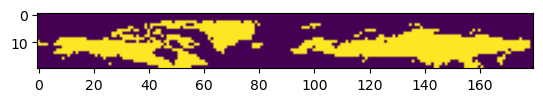

Data:


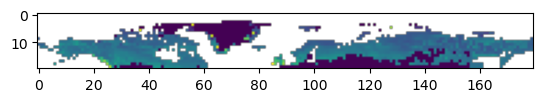

Masked data:


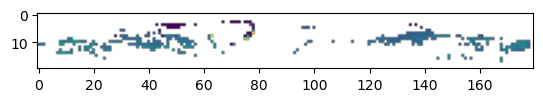

Masked data:


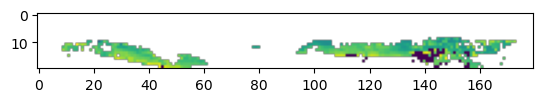

In [8]:
# TEST:
# show the mask
print('Mask:')
plt.imshow(bawld_mask)
plt.show()

# apply the mask to data (for one timestep & PFT):
AGB_orc = dataset.variables['TOTAL_AB_M_c'][:]
plotdata = AGB_orc[0,16,:]

print('Data:')
plt.imshow(plotdata)
plt.show()

# mask the  data
masked_data = np.ma.masked_where(tundra_mask==0,plotdata)
 
print('Masked data:')
plt.imshow(masked_data)
plt.show()

# mask the  data
masked_data = np.ma.masked_where(boreal_mask==0,plotdata)
 
print('Masked data:')
plt.imshow(masked_data)
plt.show()


Colormaps

In [12]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

def scivis_xml_to_cmap(xml_file, name="scivis_cmap", nlevels=256):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    x = []
    rgb = []

    for p in root.findall(".//Point"):
        x.append(float(p.attrib["x"]))
        rgb.append([
            float(p.attrib["r"]),
            float(p.attrib["g"]),
            float(p.attrib["b"]),
        ])

    x = np.asarray(x)
    rgb = np.asarray(rgb)

    # Ensure increasing order
    order = np.argsort(x)
    x = x[order]
    rgb = rgb[order]

    # Interpolate to a regular grid in [0, 1]
    xi = np.linspace(0.0, 1.0, nlevels)
    rgb_i = np.empty((nlevels, 3))
    for i in range(3):
        rgb_i[:, i] = np.interp(xi, x, rgb[:, i])

    cmap = LinearSegmentedColormap.from_list(
        name,
        rgb_i,
        N=nlevels
    )
    return cmap

mymap = scivis_xml_to_cmap(f'div3-green-brown-div.xml')


def truncate_cmap(cmap, vmin=0.0, vmax=1.0, nlevels=256, name=None):
    """
    Return a truncated version of a Matplotlib colormap.

    Parameters
    ----------
    cmap : matplotlib.colors.Colormap
        Input colormap.
    vmin, vmax : float
        Bounds in [0, 1] defining the retained portion.
    nlevels : int
        Number of colour levels in the truncated map.
    name : str, optional
        Name of the new colormap.
    """
    if not (0.0 <= vmin < vmax <= 1.0):
        raise ValueError("vmin and vmax must satisfy 0 ≤ vmin < vmax ≤ 1")

    x = np.linspace(vmin, vmax, nlevels)
    colors = cmap(x)

    return LinearSegmentedColormap.from_list(
        name or f"{cmap.name}_trunc_{vmin:.2f}_{vmax:.2f}",
        colors,
        N=nlevels
    )

truncate_cmap(mymap, vmin=0.5, vmax=1.0)


#import cm_xml_to_matplotlib as cmvis
mymap = scivis_xml_to_cmap(f'div3-green-brown-div.xml') 
mymap_brown = truncate_cmap(mymap, vmin=0.5, vmax=1.0).reversed()

# Figure 1: locations map

In [11]:
stationlats = [67.0547, 63.8757, 70.8291, 68.6337]
stationlons = [62.9405, -149.2133, 147.4943, -149.5769]
stationlats = {'RU-Vrk':67.0547, 'US-xHE':63.8757, 'RU-Cok':70.8291, 'US-EML':63.8784, 'US-ICh':68.6167, 'US-TKs':68.6337}
stationlons = {'RU-Vrk':62.9405, 'US-xHE':-149.2133, 'RU-Cok':147.4943, 'US-EML':-149.2536, 'US-ICh':-149.3, 'US-TKs':-149.5769}
stationlats = [68.6337, 63.8757, 70.8291, 67.0547, 68.6167, 63.8784]
stationlons = [-149.5769, -149.2133, 147.4943, 62.9405, -149.3, -149.2536]

stationnames_short = ['RU-Vrk', 'US-xHE', 'RU-Cok', 'US-TKs']
stationnames_m = ['FLUXNET RU-Vrk', 'FLUXNET US-xHE', 'FLUXNET RU-Cok'] #'US_ICh (Ameriflux)',
stationnames_short = ['US-TKs & US-ICh', 'US-xHE & US-EML', 'RU-Cok', 'RU-Vrk', 'US-ICh', 'US-EML']

obspath_Berner = 'obs_data/BIOMASS/Berner_2024/'
Berner_shrub_dom_data = pd.read_csv(f'{obspath_Berner}Berner_shrub_dom_data.csv', sep=',', encoding = "ISO-8859-1") 
latitudes_Berner = Berner_shrub_dom_data['latitude'].to_numpy()
longitudes_Berner = Berner_shrub_dom_data['longitude'].to_numpy()

longitude_TL, latitude_TL =  -149.5912, 68.6272  # Toolik

# Liu et al. 2015
obspath = 'obs_data/BIOMASS/Liu_2015'
file = f'{obspath}/Global_annual_mean_ABC_lc2001_1993_2012_20150331_50N.nc'
obsdataset = Dataset(file)
longitude_Liu = obsdataset.variables['longitude'][:]
latitude_Liu = obsdataset.variables['latitude'][:]

bawld_mask_Liu_highres2 = make_BAWLD_mask(longitude_Liu,latitude_Liu)
tundra_mask_Liu_highres = rasterise_biome(ecoregions_layer, biome_name="Tundra", uselat=latitude_Liu, uselon=longitude_Liu)
boreal_mask_Liu_highres = rasterise_biome(ecoregions_layer, biome_name="Boreal Forests/Taiga", uselat=latitude_Liu, uselon=longitude_Liu)

In [ ]:
# PLOT MAP:
#-----------------------------
# Settings:
plot_round = True
# choose map projection:
myprojection = ccrs.NorthPolarStereo() 
# define color map and color levels
mycmap = cm.navia_r 
N = 21
colorlevels = np.linspace(0,10000,N) 
norm = mpl.colors.BoundaryNorm(colorlevels, ncolors=mycmap.N, clip=True)
# check maximum values of data to determine best colorscale: 
#print(np.max(modeldata))

#-----------------------------
# Plot:
# create figure object:
fig, ax = plt.subplots(1,1,figsize=(8,8),subplot_kw={'projection': myprojection})
plt.subplots_adjust(wspace=0.01, hspace=0.2)    
# define map extent (W, E, S, N)
ax.set_extent([0, 360, 50, 90], ccrs.PlateCarree()) 


cont1 = ax.contourf(longitude_Liu, latitude_Liu, bawld_mask_Liu_highres2.astype(int), levels=[0.5,1.5], colors=cm.navia_r(40),   
            alpha=0.5, linewidths=1.2, transform=ccrs.PlateCarree(), label='BAWLD region') 

cont2 = ax.contourf(longitude_Liu, latitude_Liu, boreal_mask_Liu_highres.astype(int), levels=[0.5,1.5], colors=cm.navia_r(90),
           alpha=0.5, linewidths=1.2, transform=ccrs.PlateCarree(), label='Boreal region')


markcolor = '#ff7f00'   # = bright orange
markers = ['v', '^', '<', '>', 'v', '^']
for istation, station in enumerate(stationnames_short):
    if istation in [0,1,2,3]:
        ax.scatter(stationlons[istation],stationlats[istation], s=200, marker=markers[istation], 
                color=markcolor , edgecolor='k', transform=ccrs.PlateCarree(), zorder=5, label=station)
    else:
        ax.scatter(stationlons[istation],stationlats[istation], s=200, marker=markers[istation], 
                color=markcolor , edgecolor='k', transform=ccrs.PlateCarree(), zorder=5) #, label=station)


scattercolor = '#4B0092' # = purple     
ax.scatter(longitudes_Berner, latitudes_Berner, s=120, marker='o', color=scattercolor, alpha=0.5, transform=ccrs.PlateCarree(), zorder=4, 
               label='Berner et al. 2024 shrub AGB sites', edgecolor='k') #grey')

# define your coordinate range
lon_min, lon_max = -150.6, -148.6
lat_min, lat_max = 67.6, 69.6

# width & height in degrees
width  = lon_max - lon_min
height = lat_max - lat_min

rect = mpatches.Rectangle(
    (lon_min, lat_min),
    width,
    height,
    fill=False,              # outline only; set fill to True 
    edgecolor='red',
    linewidth=2,
    transform=ccrs.PlateCarree(),
    zorder=7,
    label='Model optimisation cell'
)

ax.add_patch(rect) #, )

handles_filled, labels = cont1.legend_elements()
ax.legend(handles_filled, 'BAWLD region')
ax.legend(loc='lower left',  bbox_to_anchor=(0, -0.1) , fontsize=12)       # x=1 (right edge), y=0.5 (vertical center)


# add lon-lat gridlines:
specific_latitudes = [50, 60, 70, 80, 90]
gl = ax.gridlines(crs=ccrs.PlateCarree(), ylocs=specific_latitudes, draw_labels=True, linewidth=1, color='grey', alpha=0.5, linestyle='--')
gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl.xlabel_style = {'size': 5, 'color': 'black'}
gl.ylabel_style = {'size': 5, 'color': 'black'}

# add coastlines
ax.coastlines()   
ax.add_feature(cartopy.feature.LAND, facecolor='lightgray')

# make plot edges round:
if plot_round:
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

#fig.tight_layout()
# save figure
#fig.savefig(f'{savepath}fig1.pdf', format="pdf", dpi=300, bbox_inches="tight")




# Figure 2: PFT maps

a.) Harper et al. shrub cover

In [21]:
obspath = 'PFTmaps/Harper_2023'
map = f'{obspath}/ESACCI-LC-L4-PFT-Map-0.25deg-P1Y-2010-v2.0.8.nc'
dataset_ESA = Dataset(map)
dataset_ESA.variables

maplat = shrubs_bd = dataset_ESA.variables['lat'][:]
maplon = shrubs_bd = dataset_ESA.variables['lon'][:]

shrubs_bd = dataset_ESA.variables['SHRUBS-BD'][:]
shrubs_be = dataset_ESA.variables['SHRUBS-BE'][:]
shrubs_nd = dataset_ESA.variables['SHRUBS-ND'][:]
shrubs_ne = dataset_ESA.variables['SHRUBS-NE'][:]
allshrubs_hl = shrubs_bd + shrubs_be + shrubs_nd + shrubs_ne
allshrubs_hl = allshrubs_hl / 100
np.shape(allshrubs_hl)

bawld_mask_pftmap2 = make_BAWLD_mask(maplon,maplat)
bawld_mask_area=np.broadcast_to(bawld_mask_pftmap2, allshrubs_hl.shape)   
allshrubs_hl_masked = np.ma.masked_where(bawld_mask_area==0,allshrubs_hl)

np.shape(allshrubs_hl_masked)


(720, 1440)

/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_93588/2369439530.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


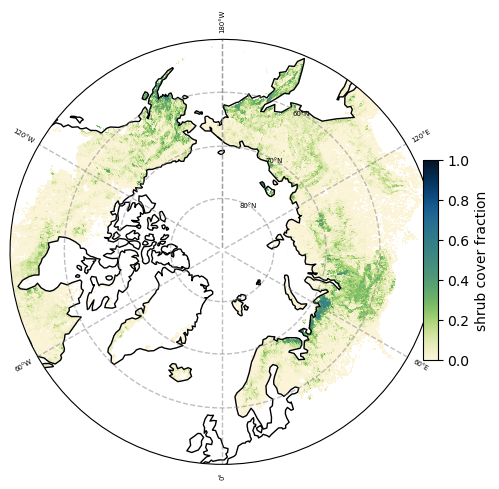

In [22]:
#-----------------------------
# Settings:
timestep = 0

plotdata = allshrubs_hl_masked
plotdata = np.ma.where(plotdata==0, np.nan, plotdata) 

plotlat = maplat
plotlon = maplon

# choose map projection:
myprojection = ccrs.NorthPolarStereo() 

mycmap = cm.navia_r 
N = 101 #21
vmin, vmax = 0,1 
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)                          # for a continuous colormap
# check maximum values of data to determine best colorscale: 
#print(f'min value: {np.nanmin(plotdata)}, max value: {np.nanmax(plotdata)}')

plot_pfts=[1,7,8,9,15,16,17,18]

rows, cols = 1,1

#-----------------------------
# Plot:
# create figure object:
fig, ax = plt.subplots(rows,cols,figsize=(5,5),subplot_kw={'projection': myprojection})
plt.subplots_adjust(wspace=0.1, hspace=0.3)   # optional adjustments to the figure
#plt.subplots_adjust(left=0.01,bottom=0.05, right=0.89, top=0.85, wspace=0, hspace=0.3)

# define map extent (W, E, S, N)
ax.set_extent([0, 360, 50, 90], ccrs.PlateCarree()) 

im = ax.pcolormesh(plotlon, plotlat, plotdata, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm) 

# colorbar
cb_ax = fig.add_axes([0.9, 0.268, 0.03, 0.4])     # (left, bottom, width, height)
cbar = fig.colorbar(im, cax=cb_ax) 
cbar.set_label(f'shrub cover fraction') 

# add lon-lat gridlines:
specific_latitudes = [50, 60, 70, 80, 90]
gl = ax.gridlines(crs=ccrs.PlateCarree(), ylocs=specific_latitudes, draw_labels=True, linewidth=1, color='grey', alpha=0.5, linestyle='--')
gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl.xlabel_style = {'size': 5, 'color': 'black'}
gl.ylabel_style = {'size': 5, 'color': 'black'}

# add coastlines
ax.coastlines()   

# make plot edges round:
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

fig.tight_layout()

# save figure
#fig.savefig(f'{savepath}shrubcover_Harper.pdf', format="pdf", bbox_inches="tight", transparent=True)
       

b.) Harper et al. + CAVM shrub cover

In [15]:
path_maps = 'ORCHIDEE_data/PFTmaps/'
map = f'{path_maps}/ORCHIDEE_18PFT_PFTmap_2010.nc'
mapdata = Dataset(map)
mapvegetfrac = mapdata.variables['maxvegetfrac'][:]
maplat = mapdata.variables['lat'][:]
maplon = mapdata.variables['lon'][:]

bawld_mask_pftmap = make_BAWLD_mask(maplon,maplat)
bawld_mask_area=np.broadcast_to(bawld_mask_pftmap, mapvegetfrac.shape)   
mapvegetfrac_masked = np.ma.masked_where(bawld_mask_area==0,mapvegetfrac)

np.shape(mapvegetfrac_masked)

(1, 18, 720, 1440)

min value: 0.0010017119348049164, max value: 1.0


/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_93588/1711299413.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


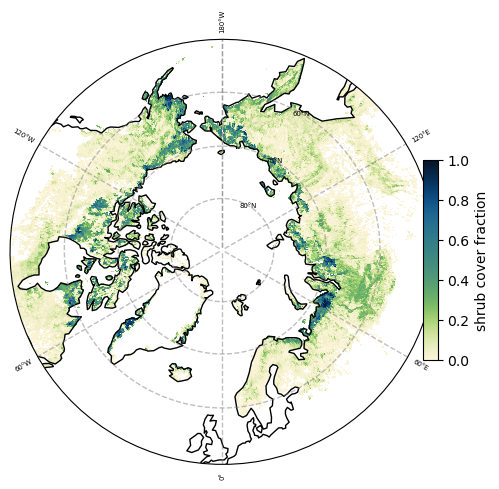

In [18]:

#-----------------------------
# Settings:
timestep = 0

plotdata = np.sum(mapvegetfrac_masked[timestep,15:18,:],axis=0)
plotdata = np.ma.where(plotdata==0, np.nan, plotdata) 

plotlat = maplat
plotlon = maplon

# choose map projection:
myprojection = ccrs.NorthPolarStereo() 

mycmap = cm.navia_r 
N = 101 
vmin, vmax = 0,1 
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)                          # for a continuous colormap
# check maximum values of data to determine best colorscale: 
print(f'min value: {np.nanmin(plotdata)}, max value: {np.nanmax(plotdata)}')

plot_pfts=[1,7,8,9,15,16,17,18]

rows, cols = 1,1

#-----------------------------
# Plot:
# create figure object:
fig, ax = plt.subplots(rows,cols,figsize=(5,5),subplot_kw={'projection': myprojection})
plt.subplots_adjust(wspace=0.1, hspace=0.3)   # optional adjustments to the figure
# define map extent (W, E, S, N)
ax.set_extent([0, 360, 50, 90], ccrs.PlateCarree()) 

im = ax.pcolormesh(plotlon, plotlat, plotdata, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm) 

# colorbar
cb_ax = fig.add_axes([0.9, 0.268, 0.03, 0.4])     # (left, bottom, width, height)
cbar = fig.colorbar(im, cax=cb_ax) #, extend="max") #, ticks = cbarticks)
cbar.set_label(f'shrub cover fraction') #, size=15) 


# add lon-lat gridlines:
specific_latitudes = [50, 60, 70, 80, 90]
gl = ax.gridlines(crs=ccrs.PlateCarree(), ylocs=specific_latitudes, draw_labels=True, linewidth=1, color='grey', alpha=0.5, linestyle='--')
gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl.xlabel_style = {'size': 5, 'color': 'black'}
gl.ylabel_style = {'size': 5, 'color': 'black'}

# add coastlines
ax.coastlines()   

# make plot edges round:
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

fig.tight_layout()

# save figure
#fig.savefig(f'{savepath}shrubcover_Harper+CAVM.pdf', format="pdf", bbox_inches="tight", transparent=True)

       

# Table 5: calculate shrub traits

In [24]:
myvars = ['HEIGHT', 'DIAMETER', 'TOTAL_AB_M_c', 'BG BM frac']
plot_pfts = [16,17,18]
ok_clean = True #False
print(f'ok clean = {ok_clean}')
startyear = 1992 

for myvar in myvars:

    if myvar != 'BG BM frac':

        units = getattr(dataset[myvar], 'units')
        varname = getattr(dataset[myvar], 'long_name')
        vardata = dataset.variables[myvar][:] #timestep,:] 

        if myvar in ['DIAMETER']:      # convert m to cm
            vardata = vardata * 100 
            units = 'cm'


    elif myvar == 'BG BM frac':
        agb_var = 'TOTAL_AB_M_c'
        bgb_var = 'TOTAL_BE_M_c'
        bm_var = 'TOTAL_M_c'
        units = '%'
        varname = 'Fraction of belowground biomass'
        #vardata = dataset.variables[bgb_var][:] / (dataset.variables[agb_var][:] + dataset.variables[bgb_var][:])
        vardata = dataset.variables[bgb_var][:] / dataset.variables[bm_var][:]
        vardata *= 100

    #vardata = vardata[istartyear:,:]    # select data after starting year

    vardata = np.ma.masked_where(bawld_mask2==0,vardata)     # mask BAWLD region

    vegcover = dataset.variables['VEGET_MAX'][:] 

    #if #ok_clean:
    vardata = np.ma.where(vegcover==0, np.nan, vardata)     # replace 0 with NaN values - where PFT is not present / - only if it makes sense!
    #vardata = np.ma.where(vardata==0, np.nan, vardata) 
    vardata = np.asarray(vardata.filled(np.nan))           # deal with masked array - replace masked with NaN

    print(f'----------{myvar} --------')
    print(varname, units)
    print(np.shape(vardata))

    for mypft in plot_pfts:
        print(f'Mean {myvar} PFT {mypft}: {np.nanmean(vardata,axis=(0,2,3))[mypft-1]:.2f} ± {np.nanstd(vardata,axis=(0,2,3))[mypft-1]:.2f} {units}. Median = {np.nanmedian(vardata,axis=(0,2,3))[mypft-1]:.2f} ({np.nanquantile(vardata,0.25,axis=(0,2,3))[mypft-1]:.2f}-{np.nanquantile(vardata,0.75,axis=(0,2,3))[mypft-1]:.2f})')


ok clean = True
----------HEIGHT --------
Quadratic mean height of all diameter classes m
(348, 18, 20, 180)


/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_93588/4184958812.py:47: RuntimeWarning: Mean of empty slice
  print(f'Mean {myvar} PFT {mypft}: {np.nanmean(vardata,axis=(0,2,3))[mypft-1]:.2f} ± {np.nanstd(vardata,axis=(0,2,3))[mypft-1]:.2f} {units}. Median = {np.nanmedian(vardata,axis=(0,2,3))[mypft-1]:.2f} ({np.nanquantile(vardata,0.25,axis=(0,2,3))[mypft-1]:.2f}-{np.nanquantile(vardata,0.75,axis=(0,2,3))[mypft-1]:.2f})')


Mean HEIGHT PFT 16: 1.33 ± 0.11 m. Median = 1.37 (1.33-1.40)
Mean HEIGHT PFT 17: 0.47 ± 0.01 m. Median = 0.47 (0.46-0.48)
Mean HEIGHT PFT 18: 0.23 ± 0.02 m. Median = 0.23 (0.23-0.24)
----------DIAMETER --------
Quadratic mean diameter  all classes cm
(348, 18, 20, 180)
Mean DIAMETER PFT 16: 4.65 ± 0.69 cm. Median = 4.84 (4.61-5.05)
Mean DIAMETER PFT 17: 2.22 ± 0.12 cm. Median = 2.23 (2.17-2.29)
Mean DIAMETER PFT 18: 0.46 ± 0.08 cm. Median = 0.47 (0.44-0.51)
----------TOTAL_AB_M_c --------
Total aboveground living biomass gC/m^2/pft
(348, 18, 20, 180)
Mean TOTAL_AB_M_c PFT 16: 449.99 ± 163.19 gC/m^2/pft. Median = 420.48 (335.80-535.56)
Mean TOTAL_AB_M_c PFT 17: 196.39 ± 61.35 gC/m^2/pft. Median = 183.74 (154.97-224.14)
Mean TOTAL_AB_M_c PFT 18: 122.52 ± 41.23 gC/m^2/pft. Median = 126.77 (105.03-147.30)
----------BG BM frac --------
Fraction of belowground biomass %
(348, 18, 20, 180)
Mean BG BM frac PFT 16: 63.42 ± 7.11 %. Median = 65.44 (59.60-68.63)
Mean BG BM frac PFT 17: 63.65 ± 6.5

# Figure 3: Biomass boxplots

Used data available at: 
* Berner, L. T. et al. The Arctic Plant Aboveground Biomass Synthesis Dataset, Pan-Arctic, 1998-2022. Arctic Data Center https://doi.org/10.18739/A2RR1PP3N (2024)


In [25]:
os.chdir('obs_data/BIOMASS')

file = 'Berner_2024/the_arctic_plant_aboveground_biomass_synthesis_dataset-2.csv'
data = pd.read_csv(file, sep=',', encoding = "ISO-8859-1") #, header=1) #sheet_name='Forest tundra', 

data['DATE'] = pd.to_datetime(data[['year', 'month', 'day']])
Berner_data = data


# Filter shrub-dominated plots:
# a. calculate shrub fraction:
myvar =  'biomass_density_gm2' 
Berner_data['pft_fraction'] = Berner_data[myvar] / Berner_data.groupby('plot_code')[myvar].transform('sum')

# b. select shrub biomass:
Berner_shrub_data = Berner_data[Berner_data['pft']=='shrub']
print(np.sum(Berner_shrub_data['pft_fraction']>=0.8) )   # = 678 plots
print(len(Berner_shrub_data['pft_fraction']))  # 2261
#678 / 2261   # = 30% of plots have >=80% shrubs

# c. select plots with at least 80% shrubs:
Berner_shrub_dom_data = Berner_shrub_data[Berner_shrub_data['pft_fraction']>=0.8]
len(Berner_shrub_dom_data['plot_code'].unique())  # 678 plots
Berner_shrub_dom_data['site_code'].unique()   # = 331 sites
Berner_shrub_dom_data['locale'].unique()  # = 24 locations
# 678 plots
# 331 sites  (of which: Oroarctic=237; Low Arctic=50; Subarctic=28; High Arctic=16)
# at 24 locations

# remove 1 strong outlier plot: Berner_shrub_dom_data[Berner_shrub_dom_data['biomass_density_gm2']>14000]
Berner_shrub_dom_data = Berner_shrub_dom_data[Berner_shrub_dom_data['biomass_density_gm2']<15000]

print(f'At least 80% of biomass is shrub bm at {Berner_shrub_dom_data['plot_code'].nunique()} plots at {Berner_shrub_dom_data['site_code'].nunique()} sites at {Berner_shrub_dom_data['locale'].nunique()} locations')

# save as excel file:
Berner_shrub_dom_data.to_csv('Berner_2024/Berner_shrub_dom_data.csv')

os.chdir('../../')

678
2261
At least 80% of biomass is shrub bm at 677 plots at 331 sites at 24 locations


In [26]:
# Filter by vegetation description to match the 3 ORCHIDEE shrub PFTs:

def filtershrubtypes(inputdata, filtercrit, negative=False, printvegdesc=False, printallinfo=False, filtercrit_sitedesc=None, filtercrit_sitecode=None, returnfulldata=False):

    if negative:
        print(f'NOT {filtercrit}')
    else:
        print(filtercrit)

    if negative:
        bp_shrub_data = inputdata[~inputdata['vegetation_description'].str.contains(filtercrit)]
    else:
        bp_shrub_data = inputdata[inputdata['vegetation_description'].str.contains(filtercrit)]

    if printvegdesc:
        print(bp_shrub_data['vegetation_description'].unique())
        
    nplots = bp_shrub_data['plot_code'].nunique()
    nsites = bp_shrub_data['site_code'].nunique()
    nlocs = bp_shrub_data['locale'].nunique()
    print(f'{nplots} plots at {nsites} sites at {nlocs} locations') 
    print(f'locations: {bp_shrub_data['locale'].unique()}') 
    print(f'countries: {bp_shrub_data['country'].unique()}') 

    if printallinfo:
        print(bp_shrub_data['locale'].unique())
        print(bp_shrub_data['site_code'].unique())
        print(bp_shrub_data['site_description'].unique())
        display(bp_shrub_data[['locale', 'site_code', 'site_description', 'vegetation_description', 'biomass_density_gm2', 'notes']])


    bp_shrub_data_bysite = bp_shrub_data.groupby('site_code', as_index=False)['biomass_density_gm2'].median() #mean()

    med = bp_shrub_data_bysite['biomass_density_gm2'].median()/2
    q1 = bp_shrub_data_bysite['biomass_density_gm2'].quantile(q=0.25)/2
    q2 = bp_shrub_data_bysite['biomass_density_gm2'].quantile(q=0.75)/2
    print(f'Biomass ({filtercrit}) = {med} ({q1} - {q2}) gC/m2')

    if returnfulldata:
        return bp_shrub_data_bysite, bp_shrub_data
    else:
        return bp_shrub_data_bysite
    



def doublefiltershrubtypes(inputdata, filtercrit_pos, filtercrit_neg, printvegdesc=False, printallinfo=False, filtercrit_sitedesc=None, returnfulldata=False):

    
    bp_shrub_data = inputdata[inputdata['vegetation_description'].str.contains(filtercrit_pos)]
    
    bp_shrub_data = bp_shrub_data[~bp_shrub_data['vegetation_description'].str.contains(filtercrit_neg)]

    if filtercrit_sitedesc != None:
        bp_shrub_data = bp_shrub_data[~bp_shrub_data['site_description'].str.contains(filtercrit_sitedesc)]

    if printvegdesc:
        print(bp_shrub_data['vegetation_description'].unique())

    nplots = bp_shrub_data['plot_code'].nunique()
    nsites = bp_shrub_data['site_code'].nunique()
    nlocs = bp_shrub_data['locale'].nunique()
    print(f'{nplots} plots at {nsites} sites at {nlocs} locations')  

    if printallinfo:
        print(bp_shrub_data['locale'].unique())
        print(bp_shrub_data['site_code'].unique())
        print(bp_shrub_data['site_description'].unique())
        display(bp_shrub_data[['locale', 'site_code', 'site_description', 'vegetation_description', 'biomass_density_gm2', 'notes']])


    bp_shrub_data_bysite = bp_shrub_data.groupby('site_code', as_index=False)['biomass_density_gm2'].median() 

    med = bp_shrub_data_bysite['biomass_density_gm2'].median()/2
    q1 = bp_shrub_data_bysite['biomass_density_gm2'].quantile(q=0.25)/2
    q2 = bp_shrub_data_bysite['biomass_density_gm2'].quantile(q=0.75)/2
    print(f'Biomass ({filtercrit_pos} & NOT {filtercrit_neg}) = {med} ({q1} - {q2}) gC/m2')

    if returnfulldata:
        return bp_shrub_data_bysite, bp_shrub_data
    else:
        return bp_shrub_data_bysite



def printinfo(fulldata, bpdata):
    print('Final:')
    nplots = fulldata['plot_code'].nunique()
    nsites = fulldata['site_code'].nunique()
    nlocs = fulldata['locale'].nunique()
    print(f'{nplots} plots at {nsites} sites at {nlocs} locations')  

    med = bpdata['biomass_density_gm2'].median()/2            # divided by 2 to convert from g/m2 to gC/m2, assuming 50% of dry biomass is C
    q1 = bpdata['biomass_density_gm2'].quantile(q=0.25)/2
    q2 = bpdata['biomass_density_gm2'].quantile(q=0.75)/2
    print(f'Biomass = {med} ({q1} - {q2}) $gCm^{-2}$')


In [27]:
# decid_tall_shrub_data_bysite_bp, low_shrub_data_comb_bysite_bp, egdwarf_shrub_data_comb_bysite_bp,

berner_path = 'obs_data/BIOMASS/'

# PFT 16: TALL DECID. SHRUBS
# ------------------------
# Tall & willow/alder 
print('----- Tall deciduous shrubs ------')
filtercrit1 = 'Salix|salix|willow|Willow|ALNFRU|Tall|tall'
filtercrit2 = ' low |Low|dwarf|Dwarf' 
decid_tall_shrub_data_bysite_bp, decid_tall_shrub_data_bysite_data = doublefiltershrubtypes(inputdata=Berner_shrub_dom_data, filtercrit_pos=filtercrit1, filtercrit_neg=filtercrit2, 
                                    filtercrit_sitedesc='dwarf|Dwarf| low |Low|18% Betula', returnfulldata=True)
decid_tall_shrub_data_bysite_bp = decid_tall_shrub_data_bysite_bp[~decid_tall_shrub_data_bysite_bp['site_code'].str.contains('Canada.DaringLake.Tower2-SedgeFen')]
decid_tall_shrub_data_bysite_data = decid_tall_shrub_data_bysite_data[~decid_tall_shrub_data_bysite_data['site_code'].str.contains('Canada.DaringLake.Tower2-SedgeFen')]
printinfo(decid_tall_shrub_data_bysite_data, decid_tall_shrub_data_bysite_bp)
decid_tall_shrub_data_bysite_data.to_csv(f'{berner_path}Berner_2024/Berner_decid_tall_shrub_data.csv')


# PFT 17: LOW DECID. SHRUBS
# ------------------------
print('----- Low deciduous shrubs ------')
low_shrub_data_bysite_bp, low_shrub_data_bysite_data = filtershrubtypes(inputdata=Berner_shrub_dom_data, filtercrit=' low |Low', negative=False, returnfulldata=True)

# betula
myfiltercrit = 'Betula|betula|BETNAN|Birch|birch|~large'   # why not BETGLA?!
betula_shrub_data_bysite_bp, betula_shrub_data_bysite_data = filtershrubtypes(inputdata=Berner_shrub_dom_data, filtercrit=myfiltercrit, negative=False, returnfulldata=True) #, printvegdesc=True)

# combined: low & betula
low_shrub_data_comb_bysite_bp = pd.concat([low_shrub_data_bysite_bp,betula_shrub_data_bysite_bp])
low_shrub_data_comb_bysite_bp.drop_duplicates(inplace=True)

low_shrub_data_comb_bysite_data = pd.concat([low_shrub_data_bysite_data,betula_shrub_data_bysite_data])
low_shrub_data_comb_bysite_data.drop_duplicates(inplace=True)
printinfo(low_shrub_data_comb_bysite_data, low_shrub_data_comb_bysite_bp)

low_shrub_data_comb_bysite_data.to_csv(f'{berner_path}Berner_2024/Berner_low_shrub_data_comb.csv')


# PFT 18: DWARF EVERGREEN SHRUBS
# ------------------------
print('----- Evergreen dwarf shrubs ------')
#' dwarf'
dwarf_shrub_data_bysite2_bp, dwarf_shrub_data_bysite2_data = filtershrubtypes(inputdata=Berner_shrub_dom_data, filtercrit='dwarf|Dwarf', negative=False, returnfulldata=True) #, printvegdesc=True)

# evergreen species
myfiltercrit = 'Betula|betula|BETNAN|BETGLA|Birch|birch|Salix|salix|willow|Willow|ALNFRU|Tall|tall|Woodland|Floodplain|Riparian|Juniper|2 m|meadow|heath|Heath|Snowbed|Wetland|Sparsely|Boreal|Herbaceous|Bare|Lichen|Southwest|North'
egdwarf_shrub_data_bysite_bp, egdwarf_shrub_data_bysite_data = filtershrubtypes(inputdata=Berner_shrub_dom_data, filtercrit=myfiltercrit, negative=True, returnfulldata=True)

# Combined: evergreen species & dwarf
egdwarf_shrub_data_comb_bysite_bp = pd.concat([egdwarf_shrub_data_bysite_bp,dwarf_shrub_data_bysite2_bp])
egdwarf_shrub_data_comb_bysite_bp.drop_duplicates(inplace=True)
#egdwarf_shrub_data_comb_bysite_bp
egdwarf_shrub_data_comb_bysite_data = pd.concat([egdwarf_shrub_data_bysite_data,dwarf_shrub_data_bysite2_data])
egdwarf_shrub_data_comb_bysite_data.drop_duplicates(inplace=True)

printinfo(egdwarf_shrub_data_comb_bysite_data, egdwarf_shrub_data_comb_bysite_bp)

egdwarf_shrub_data_comb_bysite_data.to_csv(f'{berner_path}Berner_2024/Berner_egdwarf_shrub_data_comb.csv')


# ALL SHRUBS
# ------------------------
print('----- All shrubs ------')
allshrubs_bysite = Berner_shrub_dom_data.groupby('site_code', as_index=False)['biomass_density_gm2'].median() 
allshrubs_byloc = Berner_shrub_dom_data.groupby('locale', as_index=False)['biomass_density_gm2'].median() 



----- Tall deciduous shrubs ------
33 plots at 15 sites at 7 locations
Biomass (Salix|salix|willow|Willow|ALNFRU|Tall|tall & NOT  low |Low|dwarf|Dwarf) = 576.0 (206.0 - 666.375) gC/m2
Final:
32 plots at 14 sites at 7 locations
Biomass = 583.5 (325.25 - 671.3125) $gCm^-2$
----- Low deciduous shrubs ------
 low |Low
98 plots at 24 sites at 8 locations
locations: ['Yukon' 'Interior Alaska' 'Toolik' 'Kevo' 'Kilpisjarvi' 'Kluane Lake'
 'Boniface River' 'Clearwater Lake']
countries: ['Canada' 'USA' 'Finland']
Biomass ( low |Low) = 230.75 (130.8125 - 500.5) gC/m2
Betula|betula|BETNAN|Birch|birch|~large
172 plots at 48 sites at 11 locations
locations: ['Yukon Kuskokwim Delta' 'Kougaork' 'Kilpisjarvi' 'Abisko'
 'Seward Peninsula' 'Javrresduottar' 'Toolik' 'Kevo' 'Kluane Lake'
 'Daring Lake' 'Anaktuvuk River']
countries: ['USA' 'Finland' 'Sweden' 'Canada']
Biomass (Betula|betula|BETNAN|Birch|birch|~large) = 208.625 (131.125 - 338.75) gC/m2
Final:
204 plots at 65 sites at 15 locations
Biomass = 2

<>:31: SyntaxWarning: invalid escape sequence '\,'
<>:31: SyntaxWarning: invalid escape sequence '\,'
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_93588/2582404886.py:31: SyntaxWarning: invalid escape sequence '\,'
  ax.set_ylabel(f'Aboveground biomass [$g\,C\,m^{{-2}}$]',  fontsize = 13)


Tall biomass  = 583.50 (325.2 - 671.3) gC/m2
Low/Birch biomass  = 219.50 (130.4 - 478.6) gC/m2
Evergreen/Dwarf biomass  = 131.25 (73.8 - 217.5) gC/m2
(348, 20, 180)
PFT 16 biomass  = 420.48 (335.8 - 535.6) $gC/m2
(348, 20, 180)
PFT 17 biomass  = 183.74 (155.0 - 224.1) $gC/m2
(348, 20, 180)
PFT 18 biomass  = 126.77 (105.0 - 147.3) $gC/m2


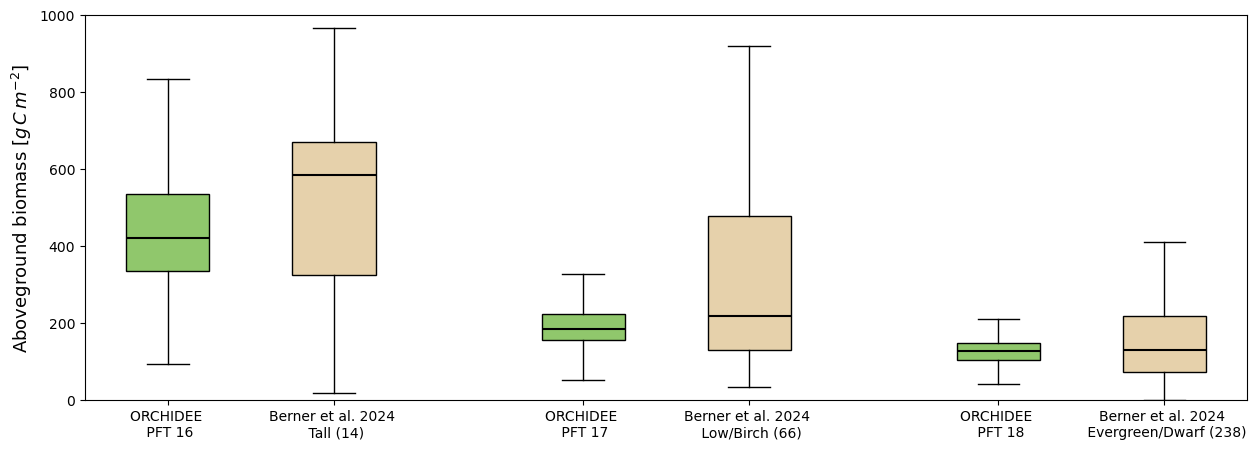

In [40]:
myvar = 'TOTAL_AB_M_c'
#cutbegin = (1998 - 1992)*12   # start in 1998 to match Berner
cutbegin = (1992 - 1992)*12    # use full period for consistency
ORC_AGB = dataset.variables[myvar][:] 
ORC_AGB  = np.ma.masked_where(bawld_mask2==0,ORC_AGB)    # mask BAWLD region


# -------------- plot Berner obs ----------
bplist = [decid_tall_shrub_data_bysite_bp, low_shrub_data_comb_bysite_bp, egdwarf_shrub_data_comb_bysite_bp] #, allshrubs_bysite] #, allshrubs_byloc]
titles = ['Tall', 'Low/Birch', 'Evergreen/Dwarf', 'Shrubs']
bppositions = [1,3.5,6,7.5]   
i = 0
fig, ax = plt.subplots(figsize=(15,5))

for i,bpdata in enumerate(bplist):
    med = bpdata['biomass_density_gm2'].median()/2
    q1 = bpdata['biomass_density_gm2'].quantile(q=0.25)/2
    q2 = bpdata['biomass_density_gm2'].quantile(q=0.75)/2
    print(f'{titles[i]} biomass  = {med:.2f} ({q1:.1f} - {q2:.1f}) gC/m2')


    boxplot_style = {
        'medianprops': {'linewidth': 1.5, 'color': 'black'},
        'boxprops': {'facecolor': mymap_brown.reversed()(30) , 'edgecolor': 'black', 'alpha': 1}, 
        'capprops': {'color': 'black', 'linewidth': 1} }

    ax.boxplot(bpdata['biomass_density_gm2']/2, positions=[bppositions[i]], tick_labels=[f'Berner et al. 2024 \n {titles[i]} ({len(bpdata)})'], showfliers=False, widths=0.5,
    patch_artist=True, **boxplot_style)

ax.set(ylabel=f'Aboveground biomass [$gCm^{{-2}}$]', ylim=(0,1000))
ax.set_ylabel(f'Aboveground biomass [$g\,C\,m^{{-2}}$]',  fontsize = 13)

# -------------- plot ORCHIDEE ----------
ipos = [0,2.5,5,7.5] #[0,2,4,6]
for i, mypft in enumerate([16,17,18]):

    print(np.shape(ORC_AGB[cutbegin:,mypft-1,:]))
     # area-weight data
    plotdata = ORC_AGB[cutbegin:,mypft-1,:].flatten()
    # clean out 0 values to stop the distortion:
    plotdata_clean = np.ma.where(plotdata==0, np.nan, plotdata) 
    plotdata_clean = plotdata_clean[~np.isnan(plotdata_clean)]

    boxplot_style = {
        'medianprops': {'linewidth': 1.5, 'color': 'black'},
        'boxprops': {'facecolor': cm.navia_r(60), 'edgecolor': 'black'}, #, 'linewidth': 8},
        'capprops': {'color': 'black', 'linewidth': 1} }

    ax.boxplot(plotdata_clean, positions=[ipos[i]], tick_labels=[f'ORCHIDEE \n PFT {mypft}'], showfliers=False, widths=0.5,
               patch_artist=True, **boxplot_style)
    

    plotdata_clean = np.asarray(plotdata_clean.filled(np.nan))
    med = np.nanmedian(plotdata_clean) 
    q1 = np.nanquantile(plotdata_clean, 0.25)
    q2 = np.nanquantile(plotdata_clean, 0.75)
    print(f'PFT {mypft} biomass  = {med:.2f} ({q1:.1f} - {q2:.1f}) $gC/m2')


#fig.savefig(f'{savepath}fig3.pdf', format="pdf", bbox_inches="tight")


Supplementary Fig. B1: including outliers

<>:28: SyntaxWarning: invalid escape sequence '\,'
<>:65: SyntaxWarning: invalid escape sequence '\,'
<>:28: SyntaxWarning: invalid escape sequence '\,'
<>:65: SyntaxWarning: invalid escape sequence '\,'
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_93588/4198945737.py:28: SyntaxWarning: invalid escape sequence '\,'
  ax.set(ylabel=f'Aboveground biomass [$gC\,m^{{-2}}$]')
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_93588/4198945737.py:65: SyntaxWarning: invalid escape sequence '\,'
  print(f'PFT 16,17,18 biomass  = {med:.2f} ({q1:.1f} - {q2:.1f}) $gC\,m^{{-2}}$')


Tall biomass  = 583.50 (325.2 - 671.3) gC/m2
Low/Birch biomass  = 219.50 (130.4 - 478.6) gC/m2
Evergreen/Dwarf biomass  = 131.25 (73.8 - 217.5) gC/m2
Shrubs biomass  = 142.50 (83.2 - 265.0) gC/m2
(348, 20, 180)
PFT 16 biomass  = 420.48 (335.8 - 535.6) gC/m2
(348, 20, 180)
PFT 17 biomass  = 183.74 (155.0 - 224.1) gC/m2
(348, 20, 180)
PFT 18 biomass  = 126.77 (105.0 - 147.3) gC/m2
(348, 2, 20, 180)
PFT 16,17,18 biomass  = 272.04 (177.4 - 407.2) $gC\,m^{-2}$


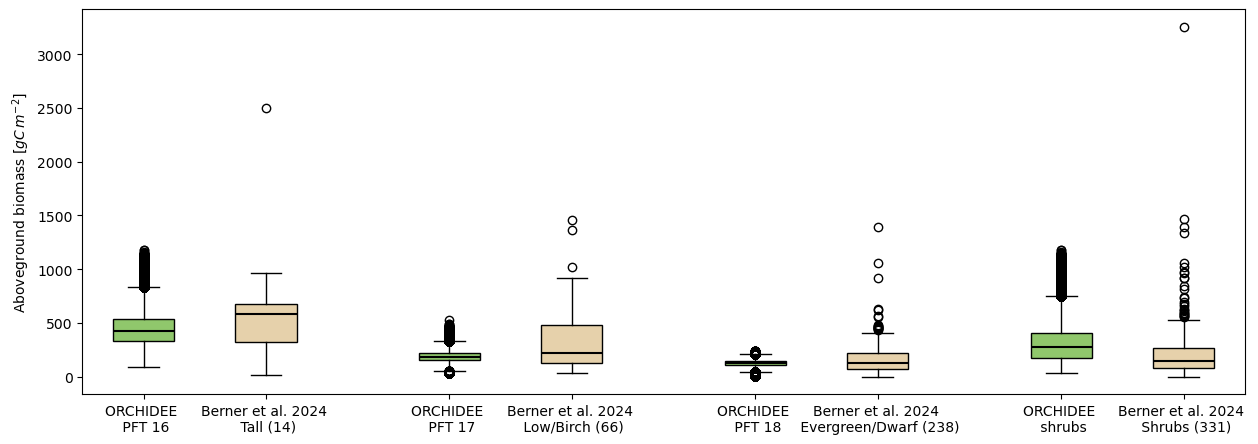

In [42]:
myvar = 'TOTAL_AB_M_c'
cutbegin = (1992 - 1992)*12   
ORC_AGB = dataset.variables[myvar][:] 
ORC_AGB  = np.ma.masked_where(bawld_mask2==0,ORC_AGB)    # mask BAWLD region


bplist = [decid_tall_shrub_data_bysite_bp, low_shrub_data_comb_bysite_bp, egdwarf_shrub_data_comb_bysite_bp, allshrubs_bysite]
titles = ['Tall', 'Low/Birch', 'Evergreen/Dwarf', 'Shrubs']
bppositions = [1,3.5,6,8.5] #[1,3,5,7]  
i = 0
fig, ax = plt.subplots(figsize=(15,5))

for i,bpdata in enumerate(bplist):
    med = bpdata['biomass_density_gm2'].median()/2
    q1 = bpdata['biomass_density_gm2'].quantile(q=0.25)/2
    q2 = bpdata['biomass_density_gm2'].quantile(q=0.75)/2
    print(f'{titles[i]} biomass  = {med:.2f} ({q1:.1f} - {q2:.1f}) gC/m2')


    boxplot_style = {
        'medianprops': {'linewidth': 1.5, 'color': 'black'},
        'boxprops': {'facecolor': mymap_brown.reversed()(30), 'edgecolor': 'black'}, 
        'capprops': {'color': 'black', 'linewidth': 1} }

    ax.boxplot(bpdata['biomass_density_gm2']/2, positions=[bppositions[i]], tick_labels=[f'Berner et al. 2024 \n {titles[i]} ({len(bpdata)})'], showfliers=True, widths=0.5,
    patch_artist=True, **boxplot_style)

ax.set(ylabel=f'Aboveground biomass [$gC\,m^{{-2}}$]') 


ipos = [0,2.5,5,7.5] #[0,2,4,6]
for i, mypft in enumerate([16,17,18]):

    print(np.shape(ORC_AGB[cutbegin:,mypft-1,:]))
    plotdata = ORC_AGB[cutbegin:,mypft-1,:].flatten()
    # clean out 0 values to stop the distortion:
    plotdata_clean = np.ma.where(plotdata==0, np.nan, plotdata) 
    plotdata_clean = plotdata_clean[~np.isnan(plotdata_clean)]

    boxplot_style = {
        'medianprops': {'linewidth': 1.5, 'color': 'black'},
        'boxprops': {'facecolor': cm.navia_r(60), 'edgecolor': 'black'},
        'capprops': {'color': 'black', 'linewidth': 1} }

    ax.boxplot(plotdata_clean, positions=[ipos[i]], tick_labels=[f'ORCHIDEE \n PFT {mypft}'], showfliers=True, widths=0.5,
               patch_artist=True, **boxplot_style)
    

    plotdata_clean = np.asarray(plotdata_clean.filled(np.nan))
    med = np.nanmedian(plotdata_clean) 
    q1 = np.nanquantile(plotdata_clean, 0.25)
    q2 = np.nanquantile(plotdata_clean, 0.75)
    print(f'PFT {mypft} biomass  = {med:.2f} ({q1:.1f} - {q2:.1f}) gC/m2')

print(np.shape(ORC_AGB[cutbegin:,16-1:18-1,:]))
plotdata = ORC_AGB[cutbegin:,16-1:18-1,:].flatten()
plotdata_clean = np.ma.where(plotdata==0, np.nan, plotdata) 
plotdata_clean = plotdata_clean[~np.isnan(plotdata_clean)]
ax.boxplot(plotdata_clean, positions=[ipos[i+1]], tick_labels=[f'ORCHIDEE \n shrubs'], showfliers=True, widths=0.5,
           patch_artist=True, **boxplot_style)
plotdata_clean = np.asarray(plotdata_clean.filled(np.nan))
med = np.nanmedian(plotdata_clean) 
q1 = np.nanquantile(plotdata_clean, 0.25)
q2 = np.nanquantile(plotdata_clean, 0.75)
print(f'PFT 16,17,18 biomass  = {med:.2f} ({q1:.1f} - {q2:.1f}) $gC\,m^{{-2}}$')


#fig.savefig(f'{savepath}figB1.pdf', format="pdf", bbox_inches="tight")

# Figure 4: CO2 fluxes

Data available from:
* Pastorello et al.: The FLUXNET2015 dataset and the ONEFlux processing pipeline for eddy covariance data, Sci. Data, 7, 225, 110 https://doi.org/10.1038/s41597-020-0534-3, 2020.
* https://ameriflux.lbl.gov

In [27]:
daytime = False 
nighttime = True 

In [28]:
def format_fluxnetdata(df):
    df['date'] = pd.to_datetime(df['TIMESTAMP'])
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day

    # TODO: drop Feb 29th here too!!
    df = df.set_index("TIMESTAMP")
    df = df[~((df.index.month == 2) & (df.index.day == 29))]          # Drop every February 29
    doy = df.index.dayofyear.to_numpy()                               # correct DoY:
    doy[(df.index.is_leap_year) & (doy > 59)] -= 1                    # Shift all days after Feb 28 in leap years back by 1
    df['DoY'] = doy
    # Group by month and day, calculate the mean for each group
    average_annual_cycle = df.groupby('DoY').mean()      
    std_annual_cycle =  df.groupby('DoY').std()       

    return df, average_annual_cycle, std_annual_cycle

# average_annual_cycle, std_annual_cycle = format_fluxnetdata(df)

In [29]:
# load flux obs data:
os.chdir('obs_data/CFLUXES')

res = 'DD'

US_TKs = f'AMF_US-TKs_FLUXNET_2018-2025_v1.3_r1/AMF_US-TKs_FLUXNET_FLUXMET_{res}_2018-2025_v1.3_r1.csv'
US_ICh = f'AMF_US-ICh_FLUXNET_FULLSET_2007-2024_5-7/AMF_US-ICh_FLUXNET_FULLSET_{res}_2007-2024_5-7.csv'
US_xHE = f'AMF_US-xHE_FLUXNET_FULLSET_2017-2021_3-5/AMF_US-xHE_FLUXNET_FULLSET_{res}_2017-2021_3-5.csv'
US_EML = f'AMF_US-EML_FLUXNET_FULLSET_2008-2020_4-6/AMF_US-EML_FLUXNET_FULLSET_{res}_2008-2020_4-6.csv'
RU_Cok = f'FLX_RU-Cok_FLUXNET2015_FULLSET_2003-2014_2-4/FLX_RU-Cok_FLUXNET2015_FULLSET_{res}_2003-2014_2-4.csv'
RU_Vrk = f'FLX_RU-Vrk_FLUXNET2015_FULLSET_2008-2008_1-4/FLX_RU-Vrk_FLUXNET2015_FULLSET_{res}_2008-2008_1-4.csv'
#RU_SkP = f'FLX_RU-SkP_FLUXNET2015_FULLSET_2012-2014_1-4/FLX_RU-SkP_FLUXNET2015_FULLSET_{res}_2012-2014_1-4.csv'

data1 = pd.read_csv(US_TKs, parse_dates=[0])
data2 = pd.read_csv(US_ICh, parse_dates=[0])
data3 = pd.read_csv(US_xHE, parse_dates=[0])
data4 = pd.read_csv(US_EML, parse_dates=[0])
data5 = pd.read_csv(RU_Cok, parse_dates=[0])
data6 = pd.read_csv(RU_Vrk, parse_dates=[0])

# replace -9999 with NAN
data1 = data1.replace(-9999.0, np.nan)
data2 = data2.replace(-9999.0, np.nan)
data3 = data3.replace(-9999.0, np.nan)
data4 = data4.replace(-9999.0, np.nan)
data5 = data5.replace(-9999.0, np.nan)
data6 = data6.replace(-9999.0, np.nan)


if daytime:
    # Exclude the years where annual cum GPP (with daytime partitioning) = 0:
    # US-xHE: 2017, 2020. US-EML: 2008, 2009, 2010, 2020. RU-Cok: 2014.

    # US-EML does not have data for GPP daytime partitioning 2008, 2009, 2010, and 2020 => exclude those years
    exclude_years = {2008, 2009, 2010, 2020}
    data4_filtered = data4[~data4["TIMESTAMP"].dt.year.isin(exclude_years)]
    data4 = data4_filtered

    # US-xHE: 2017 & 2020:
    exclude_years = {2017, 2020}
    data3 = data3[~data3["TIMESTAMP"].dt.year.isin(exclude_years)]

    # RU-Cok: 2014:
    exclude_years = {2014}
    data5 = data5[~data5["TIMESTAMP"].dt.year.isin(exclude_years)]

if nighttime:
    # exclude years for nighttime partitioning:
    # US-ICh: 2007, US-xHE: 2017, US-EML: 2020, RU-Cok: 2014

    # US-ICh: 2007
    exclude_years = {2007}
    data2 = data2[~data2["TIMESTAMP"].dt.year.isin(exclude_years)]

    # US-xHE: 2017
    exclude_years = {2017}
    data3 = data3[~data3["TIMESTAMP"].dt.year.isin(exclude_years)]

    # US-EML: 2020
    exclude_years = {2008, 2009, 2010, 2020}
    data4_filtered = data4[~data4["TIMESTAMP"].dt.year.isin(exclude_years)]
    data4 = data4_filtered

    # RU-Cok: 2014
    exclude_years = {2014}
    data5 = data5[~data5["TIMESTAMP"].dt.year.isin(exclude_years)]


os.chdir('../../')


In [30]:
# ************ 
# OBS DATA:
stations = [US_TKs, US_ICh, US_xHE, US_EML, RU_Cok, RU_Vrk]
stationnames = ['US-TKs', 'US-ICh', 'US-xHE',  'US-EML', 'RU-Cok', 'RU-Vrk' ] 
stationnames_short = stationnames

stationdatalist = [data1, data2, data3, data4, data5, data6]

# RU.-Vrk: 67.0547, 62.9405
# RU-Cok: 70.8291, 147.4943
# US-xHe: 63.8757, -149.2133  
# US-EML: 63.8784, -149.2536 (2008-2020)
# US-ICh: 
# US-TKs: 68.6337, -149.5769
stationlats = {'RU-Vrk':67.0547, 'US-xHE':63.8757, 'RU-Cok':70.8291, 'US-EML':63.8784, 'US-ICh':68.6167, 'US-TKs':68.6337}
stationlons = {'RU-Vrk':62.9405, 'US-xHE':-149.2133, 'RU-Cok':147.4943, 'US-EML':-149.2536, 'US-ICh':-149.3, 'US-TKs':-149.5769}


# full time range:
# -----------------------------
#Before updating years: 'US-xHE (2017-2021)', 'US-EML (2008-2020)', 'RU-Cok (2003-2014)'
stationyears_start = {'RU-Vrk':2008, 'US-xHE':2017, 'RU-Cok':2003, 'US-EML':2008, 'US-ICh':2007, 'US-TKs':2018}
stationyears_end = {'RU-Vrk':2008, 'US-xHE':2021, 'RU-Cok':2014, 'US-EML':2020, 'US-ICh':2024, 'US-TKs':2025}
stationnames_long = ['US-TKs (2018-2025)', 'US-ICh (2007-2024)', 'US-xHE (2017-2021)',  'US-EML (2008-2020)', 'RU-Cok (2003-2014)', 'RU-Vrk (2008)' ] 


if daytime:
    ### for daytime partitioning:
    # -------------------------------
    # Exclude: US-xHE: 2017 & 2020. US-EML: 2008, 2009, 2010, 2020. RU-Cok: 2014.
    
    # After updating years:
    stationyears_start = {'RU-Vrk':2008, 'US-xHE':2018, 'RU-Cok':2003, 'US-EML':2011, 'US-ICh':2007, 'US-TKs':2018}
    stationyears_end = {'RU-Vrk':2008, 'US-xHE':2021, 'RU-Cok':2013, 'US-EML':2019, 'US-ICh':2024, 'US-TKs':2025}
    stationnames_long = ['US-TKs (2018-2025)', 'US-ICh (2007-2024)', 'US-xHE (2018-2021)',  'US-EML (2011-2019)', 'RU-Cok (2003-2013)', 'RU-Vrk (2008)' ] 

if nighttime:
    # for nighttime partitioning:
    # -------------------------------
    # exclude: US-ICh: 2007, US-xHE: 2017, US-EML: 2020, RU-Cok: 2014
    stationyears_start = {'RU-Vrk':2008, 'US-xHE':2018, 'RU-Cok':2003, 'US-EML':2008, 'US-ICh':2008, 'US-TKs':2018}
    stationyears_end = {'RU-Vrk':2008, 'US-xHE':2021, 'RU-Cok':2013, 'US-EML':2019, 'US-ICh':2024, 'US-TKs':2025}
    stationnames_long = ['US-TKs (2018-2025)', 'US-ICh (2008-2024)', 'US-xHE (2018-2021)',  'US-EML (2008-2019)', 'RU-Cok (2003-2013)', 'RU-Vrk (2008)' ] 



### For the combined plot:  ----------------
plot_stationdatalist = [data1, data3, data5, data6]
plot_stationnames = ['US-TKs', 'US-xHE',  'RU-Cok', 'RU-Vrk' ]

extra_plot_stationdatalist = [data2, data4]
extra_plot_stationnames = ['US-ICh', 'US-EML' ]

# full years:
# -------------------------------
plot_stationnames_long = ['US-TKs (2018-2025)', 'US-xHE (2017-2021)', 'RU-Cok (2003-2014)', 'RU-Vrk (2008)' ] 
extra_plot_stationnames_long = ['US-ICh (2007-2024)',  'US-EML (2008-2020)' ] 
ORC_startyear = [2007, 2008, 2003, 2008]
ORC_endyear = [2025, 2021, 2014, 2008]

if daytime:
    # daytime years:
    # -------------------------------
    plot_stationnames_long = ['US-TKs (2018-2025)', 'US-xHE (2018-2021)', 'RU-Cok (2003-2013)', 'RU-Vrk (2008)' ] 
    extra_plot_stationnames_long = ['US-ICh (2007-2024)',  'US-EML (2011-2019)' ] 
    ORC_startyear = [2007, 2011, 2003, 2008]
    ORC_endyear = [2025, 2021, 2013, 2008]

if nighttime:
    # nighttime years:
    # -------------------------------
    plot_stationnames_long = ['US-TKs (2018-2025)', 'US-xHE (2018-2021)', 'RU-Cok (2003-2013)', 'RU-Vrk (2008)' ] 
    extra_plot_stationnames_long = ['US-ICh (2008-2024)',  'US-EML (2008-2019)' ] 
    ORC_startyear = [2008, 2008, 2003, 2008]
    ORC_endyear = [2025, 2021, 2013, 2008]


plot_months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D', 'J']

In [31]:
# load model data for comparison:

def loadORCdata_av_ann_cycle_selyears_corr(myfile, mypft, mylat, mylon, startyear, endyear, mytimearr, datres='monthly', resampletodaily=False):
    ORCdata = Dataset(myfile)

    timeinds = indices_for_years(timearr_daily,startyear, endyear)
    timearr_sel = mytimearr[timeinds]      
    nyears = int(str(timearr_sel[-1])[0:4]) - int(str(timearr_sel[0])[0:4]) + 1  

    #print(np.shape(ORCdata.variables['GPP'][timeinds[0],mypft-1,mylat, mylon]))
    var1 = ORCdata.variables['GPP'][timeinds[0],mypft-1,mylat, mylon]
    var2 = ORCdata.variables['NPP'][timeinds[0],mypft-1,mylat, mylon]
    var3 = ORCdata.variables['HET_RESP'][timeinds[0],mypft-1,mylat, mylon]
    var4 = ORCdata.variables['MAINT_RESP'][timeinds[0],mypft-1,mylat, mylon]
    var5 = ORCdata.variables['GROWTH_RESP'][timeinds[0],mypft-1,mylat, mylon]
    #var6 = ORCdata.variables['ESTIMATED_NEE'][timeinds[0],mylat, mylon]
    var7 = var3 + var4 + var5    # R_ECO
    var8 = var7 - var1           # NEE

    df = pd.DataFrame({'GPP':var1, 'NPP':var2, 'HET_RESP':var3, 'MAINT_RESP':var4,'GROWTH_RESP':var5, 'R_ECO':var7, 'R_ECO-GPP':var8}, index=pd.to_datetime(timearr_sel))
    #print(df)

    df = df[~((df.index.month == 2) & (df.index.day == 29))]                 # Drop every February 29

    # correct DoY:
    doy = df.index.dayofyear.to_numpy()  # mutable array
    is_leap = df.index.is_leap_year
    # Shift all days after Feb 28 in leap years back by 1
    doy[(is_leap) & (doy > 59)] -= 1
    # Create a separate DoY column
    df['DoY'] = doy
    

    average_annual_cycle = df.groupby('DoY').mean()             # Compute mean annual cycle
    std_annual_cycle = df.groupby('DoY').std()                  # Calculate standard deviations

    if resampletodaily:  # resample to daily format (just repeat monthly value)
        average_annual_cycle = average_annual_cycle.resample('d').interpolate(method='polynomial', order=2) 
    return average_annual_cycle, std_annual_cycle
    


# load model data for comparison:

def loadORCdata_cum_ann_cycle_selyears(myfile, mypft, mylat, mylon, startyear, endyear, mytimearr, datres='monthly', resampletodaily=False):
    ORCdata = Dataset(myfile)

    timeinds = indices_for_years(timearr_daily,startyear, endyear)
    timearr_sel = mytimearr[timeinds]      
    nyears = int(str(timearr_sel[-1])[0:4]) - int(str(timearr_sel[0])[0:4]) + 1  
    #tstepsyear = 12 if datres == 'monthly' else 365    # time steps in a year

    #print(np.shape(ORCdata.variables['GPP'][timeinds[0],mypft-1,mylat, mylon]))
    var1 = ORCdata.variables['GPP'][timeinds[0],mypft-1,mylat, mylon]
    var2 = ORCdata.variables['NPP'][timeinds[0],mypft-1,mylat, mylon]
    var3 = ORCdata.variables['HET_RESP'][timeinds[0],mypft-1,mylat, mylon]
    var4 = ORCdata.variables['MAINT_RESP'][timeinds[0],mypft-1,mylat, mylon]
    var5 = ORCdata.variables['GROWTH_RESP'][timeinds[0],mypft-1,mylat, mylon]
    #var6 = ORCdata.variables['ESTIMATED_NEE'][timeinds[0],mylat, mylon]
    var7 = var3 + var4 + var5    # R_ECO
    var8 = var7 - var1           # NEE

    df = pd.DataFrame({'GPP':var1, 'NPP':var2, 'HET_RESP':var3, 'MAINT_RESP':var4,'GROWTH_RESP':var5, 'R_ECO':var7, 'R_ECO-GPP':var8}, index=pd.to_datetime(timearr_sel))
    #print(df)

    df = df[~((df.index.month == 2) & (df.index.day == 29))]                 # Drop every February 29
    annual_sum = df.groupby(df.index.year).sum()                             # Compute mean annual cycle
    #std_annual_cycle = df.groupby(df.index.dayofyear).std()                 # Calculate standard deviations

    if resampletodaily:        # resample to daily format (just repeat monthly value)
        average_annual_cycle = average_annual_cycle.resample('d').interpolate(method='polynomial', order=2) 
    return annual_sum
    




-------------------- STATION 0: US-TKs: ----------------------
Station: US-TKs (2018-2025) (68.6337°N, -149.5769°E):
ORC: 2008-01-01T00:00 - 2020-12-23T00:00 (13 years) at 69.0°N, -149.0°E
nighttime
 --------- Gross Primary Productivity ---------
plot 2nd station:
Station: US-ICh (2008-2024) (68.6167°N, -149.3°E):
PFT 16: ---------
min/max:  -5.8386125 0.48516494285714284
PFT 16 nRMSE = 0.34. $R^2§ = -0.62. r = 0.87
min/max:  -3.1346082352941176 0.1789095176470588
PFT 16 nRMSE = 0.65. $R^2§ = -8.28. r = 0.86
PFT 17: ---------
min/max:  -5.8386125 0.48516494285714284
PFT 17 nRMSE = 0.22. $R^2§ = 0.32. r = 0.89
min/max:  -3.1346082352941176 0.1789095176470588
PFT 17 nRMSE = 0.42. $R^2§ = -3.68. r = 0.90
PFT 18: ---------
min/max:  -5.8386125 0.48516494285714284
PFT 18 nRMSE = 0.19. $R^2§ = 0.50. r = 0.76
min/max:  -3.1346082352941176 0.1789095176470588
PFT 18 nRMSE = 0.36. $R^2§ = -0.93. r = 0.78
mean GPP_NT_VUT_REF: -318.24 (49.78)
PFT 7 mean GPP: -104.08 (98.81)
PFT 8 mean GPP: 0.00 (0

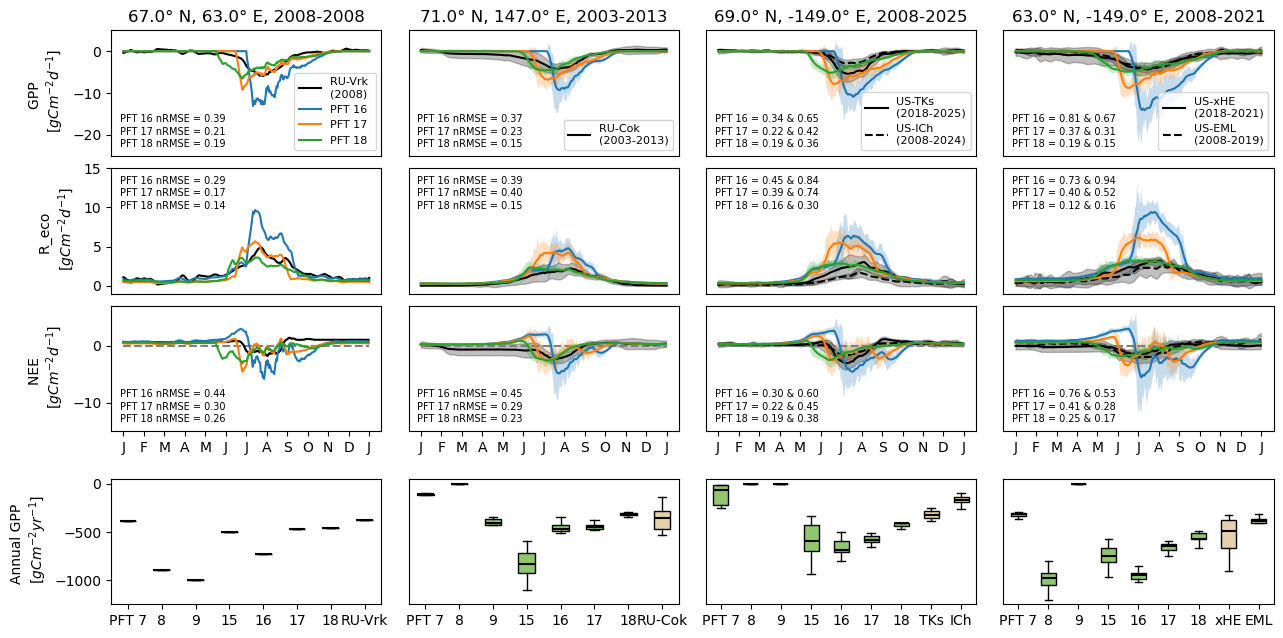

In [35]:

datres='daily'
pftlist = [16,17,18]
long_pftlist = [7,8,9,15,16,17,18]
npft = 18

columnlist = [2,3,1,0] 

running_mean = 10 # days

JobName = re.search(r'data/(.*?)_', file_daily).group(1)

plot_ORC = True 
calc_gof = True             # calculate and plot Goodness of fit
plot_gof = True

ORCdata = dataset_daily

units = getattr(ORCdata['GPP'], 'units') 
latsn = ORCdata.variables['lat']
lonsn = ORCdata.variables['lon']

lats = ORCdata.variables['lat'][:]
lons = ORCdata.variables['lon'][:]


ylabels = ['GPP', 'R_eco', 'NEE']
myvars = ['GPP_DT_VUT_REF', 'RECO_DT_VUT_REF' , 'NEE_VUT_REF']
myvars_nt = ['GPP_NT_VUT_REF', 'RECO_NT_VUT_REF' ,'NEE_VUT_REF']
myORCvars= ['GPP', 'R_ECO', 'R_ECO-GPP']# 'EST_NEE']
varnames = ['Gross Primary Productivity', 'Ecosystem Respiration', 'Net Ecosystem Exchange']


fig, axs = plt.subplots(4, 4, figsize=(15, 7)) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

for istation,station in enumerate(plot_stationnames): 

    print(f'-------------------- STATION {istation}: {station}: ----------------------') 

    stationdata = plot_stationdatalist[istation]
    findlat, findlon = stationlats[station], stationlons[station]
    mylat, mylon = sellatlon(findlat, findlon, lats,lons)
    #print(f'{lats[mylat]}°N, {lons[mylon]}°E')
    
    startyear_station, endyear_station = stationyears_start[station], stationyears_end[station]
    startyear, endyear = ORC_startyear[istation], ORC_endyear[istation]
    timeinds = indices_for_years(timearr_daily,startyear, endyear)
    starttime, endtime = timeinds[0][0], timeinds[0][-1]
    timearr_sel = timearr_daily[timeinds]
    nyears = int(str(timearr_sel[-1])[0:4]) - int(str(timearr_sel[0])[0:4]) + 1 

    icolumn = columnlist[istation]

    # print checks:
    # ************ 
    print(f'Station: {plot_stationnames_long[istation]} ({stationlats[station]}°N, {stationlons[station]}°E):')
    print(f'ORC: {timearr_sel[0]} - {timearr_sel[-1]} ({nyears} years) at {lats[mylat]}°N, {lons[mylon]}°E')

    for ivar in range(3):
        if daytime:
            myvar = myvars[ivar] 
        if nighttime:
            myvar = myvars_nt[ivar] 
            print('nighttime')
        else:
            print('Need to select partitioning method!!')
        myORCvar= myORCvars[ivar]
        varname = varnames[ivar] 

        print(f' --------- {varname} ---------')

        ax = axs[ivar, icolumn]  

        if 'NEE' in myvar:
            ax.hlines(0,0,365,colors='grey', linestyles='--')

        # ************ 
        # plot FLUXNET obs
        for df in [stationdata]: 
            #print('plot FLUXNET')
            df, average_annual_cycle, std_annual_cycle = format_fluxnetdata(df)

                
            if 'GPP' in myvar:
                average_annual_cycle[myvar] = average_annual_cycle[myvar] * -1
            smoothed = average_annual_cycle[myvar].rolling(window=running_mean, center=True, min_periods=1).mean().to_numpy()
            smoothed_std = std_annual_cycle[myvar].rolling(window=running_mean, center=True, min_periods=1).mean().to_numpy()
            if station == 'RU-Vrk':
                ax.plot(np.arange(len(average_annual_cycle[myvar])), smoothed, label=f'{station} \n({startyear_station})', color='black')
            else:
                ax.plot(np.arange(len(average_annual_cycle[myvar])), smoothed, label=f'{station} \n({startyear_station}-{endyear_station})', color='black')
            ax.fill_between(np.arange(len(average_annual_cycle[myvar])),
                            smoothed-smoothed_std, 
                            smoothed+smoothed_std, 
                            color='black', alpha=0.25)
            
            obs = average_annual_cycle[myvar]  # or smoothed, depending on what you want to use for the fit

            # ************ 
            # plot second station
            plot_2ndstat = True #False
            if istation in [0,1] and plot_2ndstat:   # plot a second station
                print('plot 2nd station:')

                for df_extra in [extra_plot_stationdatalist[istation]]: 
                    station_extra = extra_plot_stationnames[istation]
                    startyear_station_extra, endyear_station_extra = stationyears_start[station_extra], stationyears_end[station_extra]
                    print(f'Station: {extra_plot_stationnames_long[istation]} ({stationlats[station_extra]}°N, {stationlons[station_extra]}°E):')
                    df_extra, average_annual_cycle_extra, std_annual_cycle_extra = format_fluxnetdata(df_extra)


                    if 'GPP' in myvar:
                        average_annual_cycle_extra[myvar] = average_annual_cycle_extra[myvar] * -1
                    smoothed_extra = average_annual_cycle_extra[myvar].rolling(window=running_mean, center=True, min_periods=1).mean().to_numpy()
                    smoothed_std_extra = std_annual_cycle_extra[myvar].rolling(window=running_mean, center=True, min_periods=1).mean().to_numpy()
                    ax.plot(np.arange(len(average_annual_cycle_extra[myvar])), smoothed_extra, 
                            label=f'{station_extra} \n({startyear_station_extra}-{endyear_station_extra})', 
                            color='black', linestyle='--')
                    ax.fill_between(np.arange(len(average_annual_cycle_extra[myvar])),
                                    smoothed_extra-smoothed_std_extra, 
                                    smoothed_extra+smoothed_std_extra, 
                                    color='black', alpha=0.25)
                    
                    obs_extra = average_annual_cycle_extra[myvar]  # or smoothed, depending on what I want to use for the fit


        if ivar==0 and icolumn in [1,2,3]: 
            ax.legend(loc='lower right', fontsize=8)   

        # ************ 
        # plot ORC
        if plot_ORC: # and istation not in [1,3]:
            adj = 0
            for mypft in pftlist:
                print(f'PFT {mypft}: ---------')
                startyear, endyear = ORC_startyear[istation], ORC_endyear[istation]
                ORCdf, ORCdf_std = loadORCdata_av_ann_cycle_selyears_corr(file_daily, mypft, mylat, mylon, startyear, endyear, timearr_daily, datres=datres, resampletodaily=False)
                if 'GPP' in myvar:
                    ORCdf[myORCvar] = ORCdf[myORCvar] * -1
                smoothed = ORCdf[myORCvar].rolling(window=running_mean, center=True, min_periods=1).mean().to_numpy()
                smoothed_std = ORCdf_std[myORCvar].rolling(window=running_mean, center=True, min_periods=1).mean().to_numpy()
                
                ax.plot(np.arange(len(ORCdf[myORCvar])), smoothed, '-', label=f'PFT {mypft}')
                ax.fill_between(np.arange(len(ORCdf[myORCvar])), 
                                    ORCdf[myORCvar]-smoothed_std, #ORCdf_std[f'{myORCvar}'],
                                    ORCdf[myORCvar]+smoothed_std, #ORCdf_std[f'{myORCvar}'],
                                    alpha=0.25)
                
                # potentially calculate this for the matching years instead:
                model = ORCdf[myORCvar]     # or smoothed, depending on what I want to use for the fit
                if calc_gof:

                    rmse = np.sqrt(np.mean((model - obs)**2))
                    #norm_mean = np.mean(obs_valid)       # normalise by mean (instable when mean close to 0 or changes sign)
                    #nrmse_mean = rmse / norm_mean
                    norm_amp  = np.abs(np.max(obs) - np.min(obs))   # normalise by amplitude (recommended)
                    print('min/max: ', np.min(obs), np.max(obs))
                    nrmse  = rmse / norm_amp
                    r2 = 1 - np.sum((obs - model)**2)/np.sum((obs - np.mean(obs))**2)
                    r = np.corrcoef(model, obs)[0, 1]
                    print(f'PFT {mypft} nRMSE = {nrmse:.2f}. $R^2§ = {r2:.2f}. r = {r:.2f}')

                    plotstats = f'PFT {mypft} nRMSE = {nrmse:.2f}'

                    if istation in [0,1] and plot_2ndstat:
                        rmse_extra = np.sqrt(np.mean((model - obs_extra)**2))
                        norm_amp  = np.abs(np.max(obs_extra) - np.min(obs_extra))   # normalise by amplitude (recommended)
                        print('min/max: ', np.min(obs_extra), np.max(obs_extra))
                        nrmse_extra  = rmse / norm_amp
                        r2 = 1 - np.sum((obs_extra - model)**2)/np.sum((obs_extra - np.mean(obs_extra))**2)
                        r = np.corrcoef(model, obs_extra)[0, 1]
                        print(f'PFT {mypft} nRMSE = {nrmse_extra:.2f}. $R^2§ = {r2:.2f}. r = {r:.2f}')
                        plotstats = f'PFT {mypft} = {nrmse:.2f} & {nrmse_extra:.2f}'

                    if plot_gof:
                        if ivar == 0:
                            ax.text(s=plotstats, x=-5,y=-17-adj, fontsize=7, linespacing=2)   
                            adj += 3
                        elif ivar == 1:
                            ax.text(s=plotstats, x=-5,y=13-adj, fontsize=7)   
                            adj += 1.6
                        elif ivar == 2:
                            ax.text(s=plotstats, x=-5,y=-9-adj, fontsize=7, linespacing=2)
                            adj += 2.2
                        

        # ************ 
        # plot settings
        if ivar==0 and icolumn==0: 
            ax.legend(loc='lower right', fontsize=8)   

        if ivar == 2:
            ax.set(xticks=np.linspace(0, 365, 13), xticklabels=plot_months);

        if plot_ORC:
            if ivar == 0:
                ax.set(ylim=(-25,5)) 
            elif ivar == 1:
                ax.set(ylim=(-1,15)) 
            elif ivar == 2:
                ax.set(ylim=(-15,7)) 
                

        if ivar == 0:
            ax.set(title=f'{lats[mylat]}° N, {lons[mylon]}° E, {startyear}-{endyear}') 
        if ivar in [0,1]:
            ax.set(xticks=[]) 
        if icolumn==0: 
            ax.set(ylabel=f'{ylabels[ivar]} \n [$g C m^{{-2}} d^{{-1}}$]') 
        else:
            ax.set(yticks=[]) 
        # units of fluxnext data = gC/m2/day (if daily); BUT µmolCO2 m-2 s-1 (if half-hourly); 
        # units of ORC data = gC/m2/day (daily values)
            

        # ************
        # plot cum GPP boxplots
        if ivar == 0:
            ax = axs[3, icolumn]
            # move the subplot further down
            pos = ax.get_position()  # get original position
            new_pos = [pos.x0, pos.y0 - 0.05, pos.width, pos.height]  # shift down by 0.05
            ax.set_position(new_pos)

            # obs data:
            df_numeric = df.select_dtypes(exclude=["datetime64[ns]"])
            annual_sum = df_numeric.groupby(df_numeric.index.year).sum()   
            boxplot_style = {
                'medianprops': {'linewidth': 1.5, 'color': 'black'},
                'boxprops': {'facecolor': mymap_brown.reversed()(30), 'edgecolor': 'black'}, #, 'linewidth': 8}, 'facecolor': 'lightgrey',
                'capprops': {'color': 'black', 'linewidth': 1} }
            if 'GPP' in myvar:
                annual_sum[myvar] = annual_sum[myvar] * -1

            
            if istation in [0,1] and plot_2ndstat: # plot additional sites
                ax.boxplot(annual_sum[myvar], positions=[8], tick_labels=[f'{station[3:]}'], showfliers=False, widths=0.5,
                    patch_artist=True, **boxplot_style)

                df_numeric_extra = df_extra.select_dtypes(exclude=["datetime64[ns]"])
                annual_sum_extra = df_numeric_extra.groupby(df_numeric_extra.index.year).sum() 
                if 'GPP' in myvar:
                    annual_sum_extra[myvar] = annual_sum_extra[myvar] * -1 
                ax.boxplot(annual_sum_extra[myvar], positions=[9], tick_labels=[f'{station_extra[3:]}'], showfliers=False, widths=0.5,
                    patch_artist=True, **boxplot_style)
                
            else:
                ax.boxplot(annual_sum[myvar], positions=[8], tick_labels=[f'{station}'], showfliers=False, widths=0.5,
                    patch_artist=True, **boxplot_style)

            print(f'mean {myvar}: {annual_sum[myvar].mean():.2f} ({annual_sum[myvar].std():.2f})')

            # ************ 
            # plot ORC
            if plot_ORC: # and istation not in [1,3]:
                for iPFT, mypft in enumerate(long_pftlist):
                    ORCdf = loadORCdata_cum_ann_cycle_selyears(file_daily, mypft, mylat, mylon, startyear, endyear, timearr_daily, datres=datres, resampletodaily=False)
                    ipos = [1,2,3,4,5,6,7]
                    boxplot_style = {
                        'medianprops': {'linewidth': 1.5, 'color': 'black'},
                        'boxprops': {'facecolor': cm.navia_r(60), 'edgecolor': 'black'}, 
                        'capprops': {'color': 'black', 'linewidth': 1} }
                    if 'GPP' in myvar:
                        ORCdf[myORCvar] = ORCdf[myORCvar] * -1
                    if mypft == 7:
                        ax.boxplot(ORCdf[myORCvar], positions=[ipos[iPFT]], tick_labels=[f'PFT {mypft}'], showfliers=False, widths=0.5,patch_artist=True, **boxplot_style)
                    else:
                        ax.boxplot(ORCdf[myORCvar], positions=[ipos[iPFT]], tick_labels=[f'{mypft}'], showfliers=False, widths=0.5,patch_artist=True, **boxplot_style)
                    print(f'PFT {mypft} mean {myORCvar}: {ORCdf[myORCvar].mean():.2f} ({ORCdf[myORCvar].std():.2f})')


            ax.set(ylim=(-1250,50))
            if icolumn == 0: #iistation == 0:
                ax.set(ylabel=f'Annual {ylabels[ivar]} \n [$gC m^{{-2}} yr^{{-1}}$]')
            else:
                ax.set(yticks=[]) 



#fig.savefig(f'{savepath}fig4.pdf', format="pdf", bbox_inches="tight")




### Supplementary Fig. B2: ORCHIDEE respiration fluxes

-------------------- STATION 0: US-TKs: ----------------------
Station: US-TKs (2018-2025) (68.6337°N, -149.5769°E):
ORC: 2008-01-01T00:00 - 2020-12-23T00:00 (13 years) at 69.0°N, -149.0°E
 --------- Heterotrophic resp. ---------
PFT 16: ---------
PFT 17: ---------
PFT 18: ---------
 --------- Maintenance resp. ---------
PFT 16: ---------
PFT 17: ---------
PFT 18: ---------
 --------- Growth resp. ---------
PFT 16: ---------
PFT 17: ---------
PFT 18: ---------
-------------------- STATION 1: US-xHE: ----------------------
Station: US-xHE (2018-2021) (63.8757°N, -149.2133°E):
ORC: 2008-01-01T00:00 - 2020-12-23T00:00 (13 years) at 63.0°N, -149.0°E
 --------- Heterotrophic resp. ---------
PFT 16: ---------
PFT 17: ---------
PFT 18: ---------
 --------- Maintenance resp. ---------
PFT 16: ---------
PFT 17: ---------
PFT 18: ---------
 --------- Growth resp. ---------
PFT 16: ---------
PFT 17: ---------
PFT 18: ---------
-------------------- STATION 2: RU-Cok: ----------------------
Station

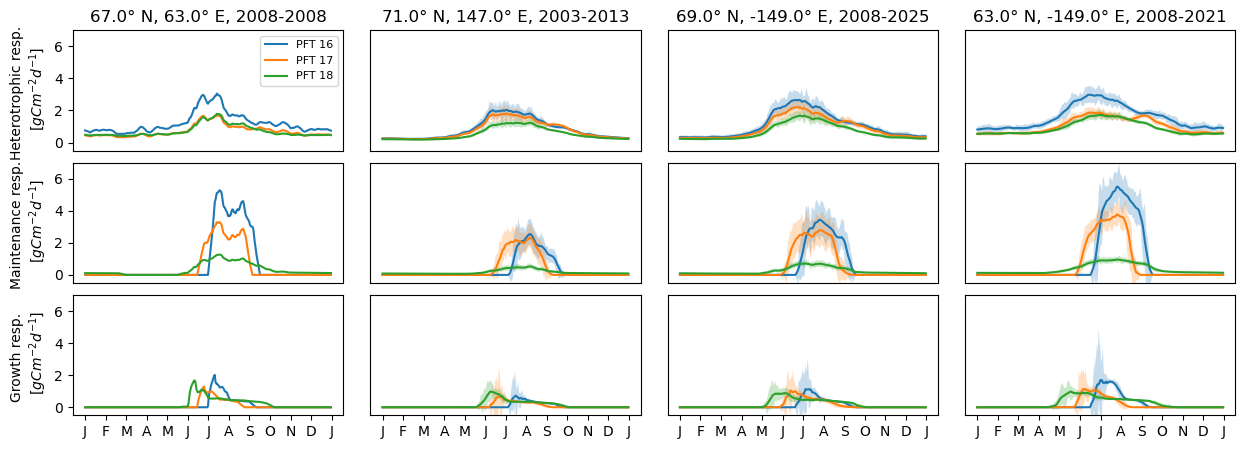

In [32]:

datres='daily'
pftlist = [16,17,18]
long_pftlist = [7,8,9,15,16,17,18]
npft = 18
columnlist = [2,3,1,0] 
running_mean = 10 # days
JobName = re.search(r'data/(.*?)_', file_daily).group(1)
plot_ORC = True 
calc_gof = True    # calculate and plot Goodness of fit

ORCdata = dataset_daily

units = getattr(ORCdata['GPP'], 'units') 
latsn = ORCdata.variables['lat']
lonsn = ORCdata.variables['lon']

lats = ORCdata.variables['lat'][:]
lons = ORCdata.variables['lon'][:]


ylabels = ['Heterotrophic resp.', 'Maintenance resp.', 'Growth resp.']
myvars = ['HET_RESP', 'MAINT_RESP', 'GROWTH_RESP']
myvars_nt = ['HET_RESP', 'MAINT_RESP', 'GROWTH_RESP']
myORCvars= ['HET_RESP', 'MAINT_RESP', 'GROWTH_RESP']
varnames = ['Heterotrophic resp.', 'Maintenance resp.', 'Growth resp.']

fig, axs = plt.subplots(3, 4, figsize=(15, 5))   
plt.subplots_adjust(wspace=0.1, hspace=0.1)

for istation,station in enumerate(plot_stationnames):

    print(f'-------------------- STATION {istation}: {station}: ----------------------') 

    stationdata = plot_stationdatalist[istation]
    findlat, findlon = stationlats[station], stationlons[station]
    mylat, mylon = sellatlon(findlat, findlon, lats,lons)
    
    startyear_station, endyear_station = stationyears_start[station], stationyears_end[station]
    startyear, endyear = ORC_startyear[istation], ORC_endyear[istation]
    timeinds = indices_for_years(timearr_daily,startyear, endyear)
    starttime, endtime = timeinds[0][0], timeinds[0][-1]
    timearr_sel = timearr_daily[timeinds]
    nyears = int(str(timearr_sel[-1])[0:4]) - int(str(timearr_sel[0])[0:4]) + 1 

    icolumn = columnlist[istation]

    # print checks:
    # ************ 
    print(f'Station: {plot_stationnames_long[istation]} ({stationlats[station]}°N, {stationlons[station]}°E):')
    print(f'ORC: {timearr_sel[0]} - {timearr_sel[-1]} ({nyears} years) at {lats[mylat]}°N, {lons[mylon]}°E')

    for ivar in range(3):
        myvar = myvars_nt[ivar]    # use NIGHTTIME partitioning!
        myORCvar= myORCvars[ivar]
        varname = varnames[ivar] 
        print(f' --------- {varname} ---------')
        ax = axs[ivar, icolumn] 

        # ************ 
        # plot ORC
        if plot_ORC: 
            adj = 0
            for mypft in pftlist:
                print(f'PFT {mypft}: ---------')
                startyear, endyear = ORC_startyear[istation], ORC_endyear[istation]
                ORCdf, ORCdf_std = loadORCdata_av_ann_cycle_selyears_corr(file_daily, mypft, mylat, mylon, startyear, endyear, timearr_daily, datres=datres, resampletodaily=False)
                if 'GPP' in myvar:
                    ORCdf[myORCvar] = ORCdf[myORCvar] * -1
                smoothed = ORCdf[myORCvar].rolling(window=running_mean, center=True, min_periods=1).mean().to_numpy()
                smoothed_std = ORCdf_std[myORCvar].rolling(window=running_mean, center=True, min_periods=1).mean().to_numpy()
                
                ax.plot(np.arange(len(ORCdf[myORCvar])), smoothed, '-', label=f'PFT {mypft}')
                ax.fill_between(np.arange(len(ORCdf[myORCvar])), 
                                    ORCdf[myORCvar]-smoothed_std, 
                                    ORCdf[myORCvar]+smoothed_std, 
                                    alpha=0.25)
                
                # potentially calculate this for the matching years instead:
                model = ORCdf[myORCvar]     # or smoothed, depending on what I want to use for the fit


        # ************ 
        # plot settings
        if ivar==0 and icolumn==0: #iistation==0:
            ax.legend(loc='upper right', fontsize=8)   
        if ivar == 2:
            ax.set(xticks=np.linspace(0, 365, 13), xticklabels=plot_months);
        if plot_ORC:
            ax.set(ylim=(-0.5,7))
                
        if ivar == 0:
            ax.set(title=f'{lats[mylat]}° N, {lons[mylon]}° E, {startyear}-{endyear}') 
        if ivar in [0,1]:
            ax.set(xticks=[]) 
        if icolumn==0: 
            ax.set(ylabel=f'{ylabels[ivar]} \n [$g C m^{{-2}} d^{{-1}}$]') 
        else:
            ax.set(yticks=[]) 
        # units of fluxnext data = gC/m2/day (if daily); BUT µmolCO2 m-2 s-1 (if half-hourly); 
        # units of ORC data = gC/m2/day (daily values)
            


#fig.savefig(f'{savepath}figB2.pdf', format="pdf", bbox_inches="tight")



### Supplementary Fig. B3: Annual sum of CO2 fluxes for all high-latitude PFTs 

-------------------- STATION 0: US-TKs: ----------------------
Station: US-TKs (2018-2025) (68.6337° N, -149.5769° E):
ORC: 2008-01-01T00:00 - 2020-12-23T00:00 (13 years) at 69.0° N, -149.0° E
 --------- Gross Primary Productivity ---------
mean GPP_NT_VUT_REF: -318.24 (49.78)
PFT 7 mean GPP: -104.08 (98.81)
PFT 8 mean GPP: 0.00 (0.00)
PFT 9 mean GPP: 0.00 (0.00)
PFT 15 mean GPP: -600.04 (186.79)
PFT 16 mean GPP: -658.66 (82.98)
PFT 17 mean GPP: -564.50 (84.00)
PFT 18 mean GPP: -413.84 (39.79)
 --------- Ecosystem Respiration ---------
mean RECO_NT_VUT_REF: 332.06 (46.82)
PFT 7 mean R_ECO: 191.00 (34.40)
PFT 8 mean R_ECO: 0.00 (0.00)
PFT 9 mean R_ECO: 0.00 (0.00)
PFT 15 mean R_ECO: 552.89 (88.22)
PFT 16 mean R_ECO: 629.24 (61.71)
PFT 17 mean R_ECO: 559.05 (68.70)
PFT 18 mean R_ECO: 402.35 (36.37)
 --------- Net Ecosystem Exchange ---------
mean NEE_VUT_REF: 14.79 (27.48)
PFT 7 mean R_ECO-GPP: 86.92 (65.45)
PFT 8 mean R_ECO-GPP: 0.00 (0.00)
PFT 9 mean R_ECO-GPP: 0.00 (0.00)
PFT 15 mean 

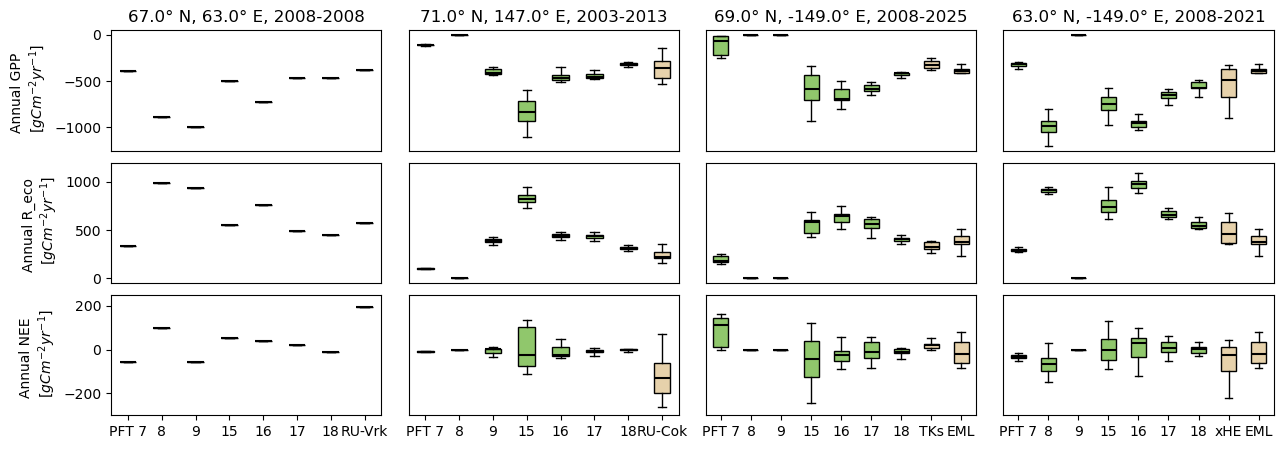

In [36]:
datres='daily'
pftlist = [16,17,18]
long_pftlist = [7,8,9,15,16,17,18]
npft = 18
columnlist = [2,3,1,0] 
running_mean = 10 # days
JobName = re.search(r'data/(.*?)_', file_daily).group(1)
plot_ORC = True 
calc_gof = True      # calculate and plot Goodness of fit

ORCdata = dataset_daily
units = getattr(ORCdata['GPP'], 'units') 
latsn = ORCdata.variables['lat']
lonsn = ORCdata.variables['lon']
lats = ORCdata.variables['lat'][:]
lons = ORCdata.variables['lon'][:]


ylabels = ['GPP', 'R_eco', 'NEE']
myvars = ['GPP_DT_VUT_REF', 'RECO_DT_VUT_REF' , 'NEE_VUT_REF']
myvars_nt = ['GPP_NT_VUT_REF', 'RECO_NT_VUT_REF' ,'NEE_VUT_REF']
myORCvars= ['GPP', 'R_ECO', 'R_ECO-GPP']
varnames = ['Gross Primary Productivity', 'Ecosystem Respiration', 'Net Ecosystem Exchange']


fig, axs = plt.subplots(3, 4, figsize=(15, 5))  
plt.subplots_adjust(wspace=0.1, hspace=0.1)

for istation,station in enumerate(plot_stationnames): #[1,2,3,4,5,6]): 

    print(f'-------------------- STATION {istation}: {station}: ----------------------') 

    stationdata = plot_stationdatalist[istation]
    findlat, findlon = stationlats[station], stationlons[station]
    mylat, mylon = sellatlon(findlat, findlon, lats,lons)
    
    startyear_station, endyear_station = stationyears_start[station], stationyears_end[station]
    startyear, endyear = ORC_startyear[istation], ORC_endyear[istation]
    timeinds = indices_for_years(timearr_daily,startyear, endyear)
    starttime, endtime = timeinds[0][0], timeinds[0][-1]
    timearr_sel = timearr_daily[timeinds]
    nyears = int(str(timearr_sel[-1])[0:4]) - int(str(timearr_sel[0])[0:4]) + 1 
    icolumn = columnlist[istation]

    # print checks:
    # ************ 
    print(f'Station: {plot_stationnames_long[istation]} ({stationlats[station]}° N, {stationlons[station]}° E):')
    print(f'ORC: {timearr_sel[0]} - {timearr_sel[-1]} ({nyears} years) at {lats[mylat]}° N, {lons[mylon]}° E')

    for ivar in range(3):

        myvar = myvars_nt[ivar]    # use NIGHTTIME partitioning!
        myORCvar= myORCvars[ivar]
        varname = varnames[ivar] 

        print(f' --------- {varname} ---------')

        ax = axs[ivar, icolumn] 

        # ************ 
        # plot FLUXNET obs
        for df in [stationdata]: 
            df, average_annual_cycle, std_annual_cycle = format_fluxnetdata(df)

            df_numeric = df.select_dtypes(exclude=["datetime64[ns]"])
            annual_sum = df_numeric.groupby(df_numeric.index.year).sum()   
            boxplot_style = {
                'medianprops': {'linewidth': 1.5, 'color': 'black'},
                'boxprops': {'facecolor': mymap_brown.reversed()(30), 'edgecolor': 'black'}, 
                'capprops': {'color': 'black', 'linewidth': 1} }
            if 'GPP' in myvar:
                annual_sum[myvar] = annual_sum[myvar] * -1
        
            plot_2ndstat = True
            if istation in [0,1] and plot_2ndstat: # plot additional sites
                ax.boxplot(annual_sum[myvar], positions=[8], tick_labels=[f'{station[3:]}'], showfliers=False, widths=0.5,
                    patch_artist=True, **boxplot_style)

                df_numeric_extra = df_extra.select_dtypes(exclude=["datetime64[ns]"])
                annual_sum_extra = df_numeric_extra.groupby(df_numeric_extra.index.year).sum() 
                if 'GPP' in myvar:
                    annual_sum_extra[myvar] = annual_sum_extra[myvar] * -1 
                ax.boxplot(annual_sum_extra[myvar], positions=[9], tick_labels=[f'{station_extra[3:]}'], showfliers=False, widths=0.5,
                    patch_artist=True, **boxplot_style)
                
            else:
                ax.boxplot(annual_sum[myvar], positions=[8], tick_labels=[f'{station}'], showfliers=False, widths=0.5,
                    patch_artist=True, **boxplot_style)

            print(f'mean {myvar}: {annual_sum[myvar].mean():.2f} ({annual_sum[myvar].std():.2f})')


        # ************ 
        # plot ORC
        if plot_ORC: 
                # potentially calculate this for the matching years instead:
                #model = ORCdf[myORCvar]     # or smoothed, depending on what I want to use for the fit

            for iPFT, mypft in enumerate(long_pftlist):
                ORCdf = loadORCdata_cum_ann_cycle_selyears(file_daily, mypft, mylat, mylon, startyear, endyear, timearr_daily, datres=datres, resampletodaily=False)
                ipos = [1,2,3,4,5,6,7]
                boxplot_style = {
                    'medianprops': {'linewidth': 1.5, 'color': 'black'},
                    'boxprops': {'facecolor': cm.navia_r(60), 'edgecolor': 'black'}, #, 'linewidth': 8},
                    'capprops': {'color': 'black', 'linewidth': 1} }
                if 'GPP' in myvar:
                    ORCdf[myORCvar] = ORCdf[myORCvar] * -1
                if mypft == 7:
                    ax.boxplot(ORCdf[myORCvar], positions=[ipos[iPFT]], tick_labels=[f'PFT {mypft}'], showfliers=False, widths=0.5,patch_artist=True, **boxplot_style)
                else:
                    ax.boxplot(ORCdf[myORCvar], positions=[ipos[iPFT]], tick_labels=[f'{mypft}'], showfliers=False, widths=0.5,patch_artist=True, **boxplot_style)
                print(f'PFT {mypft} mean {myORCvar}: {ORCdf[myORCvar].mean():.2f} ({ORCdf[myORCvar].std():.2f})')
                        


        # ************ 
        # plot settings
        if plot_ORC:
            if ivar == 0:
                ax.set(ylim=(-1250,50))   
            elif ivar == 1:
                ax.set(ylim=(-50,1200))
            elif ivar == 2:
                ax.set(ylim=(-300,250))
                
        if ivar == 0:
            ax.set(title=f'{lats[mylat]}° N, {lons[mylon]}° E, {startyear}-{endyear}') 
        if ivar in [0,1]:
            ax.set(xticks=[]) 
        if icolumn==0: 
            ax.set(ylabel=f'Annual {ylabels[ivar]} \n [$gC m^{{-2}} yr^{{-1}}$]')
        else:
            ax.set(yticks=[]) 

#fig.savefig(f'{savepath}figB3.pdf', format="pdf", bbox_inches="tight")



# Fig. 5: PFT fractional cover maps

In [10]:

def calc_veget_cover_1timestep(pft_data):
    # Broadcast cell area to 3D (time, lat, lon)
    area_3d = np.broadcast_to(cellarea_masked, pft_data.shape)
    # Mask invalid values
    mask = np.isfinite(pft_data) & np.isfinite(area_3d)
    # Weighted sum and total weights per timestep
    weighted_sum = np.nansum(pft_data * area_3d * mask, axis=(0, 1))
    sum_weights  = np.nansum(area_3d * mask, axis=(0, 1))
    total_area = sum_weights / 1e6
    #print(f'total area: {sum_weights}')
    
    # Weighted mean per timestep
    mean_w = weighted_sum / sum_weights
    # Weighted variance per timestep
    var_w = np.nansum(area_3d * mask * (pft_data - mean_w[None, None])**2, axis=(0, 1)) / sum_weights
    std_w = np.sqrt(var_w)
    
    # Total area covered
    area_covered = np.nansum(pft_data * area_3d * mask) / 1e6  # km²
    perc_covered = (area_covered * 1e6 / np.nansum(area_3d * mask)) * 100
    area_mean = np.nansum(pft_data * area_3d * mask, axis=(0,1)) / 1e6  # shape: (time,)
    #area_mean = np.nanmean(area_mean_time)  # average area in km²

    print(f"PFT {mypft} cover: {area_covered/1e6:.2f} Mkm² ({perc_covered:.2f}%)")

    return area_mean, perc_covered, total_area


In [ ]:
plotdataset1 = dataset
plotdataset2 = dataset_bl

# Load data:
myvar = 'VEGET_MAX'
units = getattr(plotdataset1[myvar], 'units')
varname = getattr(plotdataset1[myvar], 'long_name')
print(varname, units)
year, month = 2010, 6
timestep = (year-1992) * 12 + month
print(timearr[timestep])

veget_cover = plotdataset1.variables[myvar][:]
veget_cover  = np.ma.masked_where(bawld_mask2==0,veget_cover)    # mask BAWLD region

veget_cover_bl = plotdataset2.variables[myvar][:]
bawld_mask_bl=np.broadcast_to(bawld_mask, veget_cover_bl.shape)
veget_cover_bl  = np.ma.masked_where(bawld_mask_bl==0,veget_cover_bl)     # mask BAWLD region

veget_cover_clean = np.ma.where(veget_cover==0, np.nan, veget_cover)          # only do this for plotting, not calculating statistics!
veget_cover_clean_bl = np.ma.where(veget_cover_bl==0, np.nan, veget_cover_bl) 

pftlist = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]

bawld_mask_area=np.broadcast_to(bawld_mask, cellarea.shape)             # not neccessary since the data is already masked
cellarea_masked = np.ma.masked_where(bawld_mask_area==0,cellarea)

# PLOT MAP:

#-----------------------------
# Settings:
plotdata = veget_cover_clean

# choose map projection:
myprojection = ccrs.NorthPolarStereo() 

# define color map and color levels
colors3 = cm.navia_r(np.linspace(0.1, 1, 256)) 
mymap2 = mpl.colors.LinearSegmentedColormap.from_list('my_colormap', colors3)
mycmap = cm.vik 
N = 101 
vmin, vmax = -0.6,0.6
colorlevels = np.linspace(vmin,vmax,N) 
norm = mpl.colors.BoundaryNorm(colorlevels, ncolors=mycmap.N, clip=True)   # for a discrete colormap
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)                          # for a continuous colormap
# check maximum values of data to determine best colorscale: 
print(f'min value: {np.nanmin(plotdata)}, max value: {np.nanmax(plotdata)}')

plot_pfts=[1,7,8,9,15,0,16,17,18]

rows, cols = 3, 3

#-----------------------------
# Plot:
# create figure object:
fig, axs = plt.subplots(rows,cols,figsize=(15,17),subplot_kw={'projection': myprojection})
plt.subplots_adjust(wspace=0.05, hspace=0.4)   # optional adjustments to the figure
i = 0
for row in range(rows):
    for col in range(cols):
        ax = axs[row,col]
        mypft = plot_pfts[i]
        i+=1
        if i == 6:
            ax.set_visible(False)
            continue

        else:
            # define map extent (W, E, S, N)
            ax.set_extent([0, 360, 50, 90], ccrs.PlateCarree()) 

            if mypft <16: # difference plot
                plotdata_diff = plotdata[timestep,mypft-1,:] - veget_cover_clean_bl[timestep,mypft-1,:]
                print(f'PFT {mypft}: min value: {np.nanmin(plotdata_diff)}, max value: {np.nanmax(plotdata_diff)}')
                im_diff = ax.pcolormesh(longitude, latitude, plotdata[timestep,mypft-1,:] - veget_cover_clean_bl[timestep,mypft-1,:] , 
                                transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm)
                
                # stats:
                pft_cover, pft_cover_perc, total_area = calc_veget_cover_1timestep(veget_cover[timestep,mypft-1,:])
                ax.set_title(f'PFT {mypft} \n {PFTs[mypft]} \n {pft_cover/1e+06:.2f} $M\,km^2$ ({pft_cover_perc:.1f}%)', size=15)


            else:  # shrub maps
                mycmap = mymap2
                vmin, vmax = 0,0.6
                norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)                          # for a continuous colormap
                im = ax.pcolormesh(longitude, latitude, plotdata[timestep,mypft-1,:], transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm) #, extend='both') #discrete=False)

                # stats:
                pft_cover, pft_cover_perc, total_area = calc_veget_cover_1timestep(veget_cover[timestep,mypft-1,:])
                ax.set_title(f'PFT {mypft} \n {PFTs[mypft]} \n {pft_cover/1e+06:.2f} $M\,km^2$ ({pft_cover_perc:.1f}%)', size=15, fontweight='bold')

                # weighted mean:
                mask = np.isfinite(plotdata_diff) & np.isfinite(cellarea_masked)
                x = plotdata_diff[mask]
                w = cellarea_masked[mask]
                mean_w = np.sum(w * x) / np.sum(w)
                var_w  = np.sum(w * (x - mean_w)**2) / np.sum(w)
                std_w  = np.sqrt(var_w)


            # add lon-lat gridlines:
            specific_latitudes = [50, 60, 70, 80, 90]
            gl = ax.gridlines(crs=ccrs.PlateCarree(), ylocs=specific_latitudes, draw_labels=True, linewidth=1, color='grey', alpha=0.5, linestyle='--')
            gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
            gl.xlabel_style = {'size': 5, 'color': 'black'}
            gl.ylabel_style = {'size': 5, 'color': 'black'}
            # add coastlines
            ax.coastlines()   
            # make plot edges round:
            theta = np.linspace(0, 2*np.pi, 100)
            center, radius = [0.5, 0.5], 0.5
            verts = np.vstack([np.sin(theta), np.cos(theta)]).T
            circle = mpath.Path(verts * radius + center)
            ax.set_boundary(circle, transform=ax.transAxes)


# colorbars
cb_ax = fig.add_axes([0.91, 0.68, 0.02, 0.2])     # (left, bottom, width, height)
cbar = fig.colorbar(im_diff, cax=cb_ax, extend="both") #, ticks = cbarticks)
cbar.set_label(f'Change in fractional vegetation cover', size=15) 

cb_ax = fig.add_axes([0.91, 0.12, 0.02, 0.2])     # (left, bottom, width, height)
cbar = fig.colorbar(im, cax=cb_ax, extend="max") #, ticks = cbarticks)
cbar.set_label(f'Fractional vegetation cover', size=15) 

# save figure
#fig.savefig(f'{savepath}fig5.pdf', format="pdf", bbox_inches="tight")

       

Calculate cover statistics over entire reference timeframe (1992-2020)

In [19]:
def calc_veget_cover(pft_data):
    # Broadcast cell area to 3D (time, lat, lon)
    area_3d = np.broadcast_to(cellarea_masked, pft_data.shape)
    # Mask invalid values
    mask = np.isfinite(pft_data) & np.isfinite(area_3d)
    # Weighted sum and total weights per timestep
    weighted_sum = np.nansum(pft_data * area_3d * mask, axis=(1, 2))
    sum_weights  = np.nansum(area_3d * mask, axis=(1, 2))
    
    # Weighted mean per timestep
    mean_w = weighted_sum / sum_weights
    # Weighted variance per timestep
    var_w = np.nansum(area_3d * mask * (pft_data - mean_w[:, None, None])**2, axis=(1, 2)) / sum_weights
    std_w = np.sqrt(var_w)
    
    # Weighted mean and std over all timesteps
    mean_all = np.nanmean(mean_w)
    std_all  = np.nanmean(std_w)
    
    # Total area covered (over all timesteps)
    area_covered = np.nansum(pft_data * area_3d * mask) / 1e6  # km²
    perc_covered = (area_covered * 1e6 / np.nansum(area_3d * mask)) * 100

    area_mean_time = np.nansum(pft_data * area_3d * mask, axis=(1,2)) / 1e6  # shape: (time,)
    area_mean = np.nanmean(area_mean_time)  # average area in km²

    # Compute PFT area per timestep
    area_timestep = np.nansum(pft_data * area_3d * mask, axis=(1,2))  # m²
    total_area  = np.nansum(area_3d * mask, axis=(1,2))               # m²
    total_area_mean = np.nanmean(sum_weights) / 1e6

    perc_timestep = (area_timestep / total_area) * 100                # % per timestep
    perc_mean = np.nanmean(perc_timestep)                              # average percent covered

    
    print(f"PFT {mypft} cover: {area_mean:.2e} km² ({perc_covered:.2f}%)")
    #print(f"PFT {mypft}: weighted mean per timestep: {mean_w*100}, std per timestep: {std_w*100}")
    #print(f"PFT {mypft}: weighted mean over all timesteps: {mean_all*100:.2f} ± {std_all*100:.2f}")

    return area_mean, perc_covered, total_area_mean

In [20]:
pft_cover_all = 0
pft_cover_perc_all = 0
pft_cover_shrubs = 0
pft_cover_perc_shrubs = 0

print('In 2010:')

for mypft in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]:

    pft_cover, pft_cover_perc, total_area = calc_veget_cover_1timestep(veget_cover[timestep,mypft-1,:])
    pft_cover_all += pft_cover
    pft_cover_perc_all += pft_cover_perc

    if mypft in [16,17,18]:
        pft_cover_shrubs += pft_cover
        pft_cover_perc_shrubs += pft_cover_perc


print(f'Total shrub cover: {pft_cover_shrubs/1e+06:.2f} ({pft_cover_perc_shrubs})')
print(f'Total cover: {pft_cover_all/1e+06:.2f} Mkm2 ({pft_cover_perc_all})')
print(f'Total area: {total_area/1e+06:.2f} Mkm2')


pft_cover_all = 0
pft_cover_perc_all = 0
pft_cover_shrubs = 0
pft_cover_perc_shrubs = 0

print('\nWhole period 1992-2020:')

for mypft in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]:

    pft_cover, pft_cover_perc, total_area = calc_veget_cover(veget_cover[:,mypft-1,:])
    pft_cover_all += pft_cover
    pft_cover_perc_all += pft_cover_perc

    if mypft in [16,17,18]:
        pft_cover_shrubs += pft_cover
        pft_cover_perc_shrubs += pft_cover_perc


print(f'Total shrub cover: {pft_cover_shrubs/1e+06:.2f} ({pft_cover_perc_shrubs})')
print(f'Total cover: {pft_cover_all/1e+06:.2f} Mkm2 ({pft_cover_perc_all})')
print(f'Total area: {total_area/1e+06:.2f} Mkm2')

In 2010:
PFT 1 cover: 5.02 Mkm² (23.07%)
PFT 2 cover: 0.00 Mkm² (0.00%)
PFT 3 cover: 0.00 Mkm² (0.00%)
PFT 4 cover: 0.31 Mkm² (1.44%)
PFT 5 cover: 0.00 Mkm² (0.00%)
PFT 6 cover: 0.28 Mkm² (1.29%)
PFT 7 cover: 3.40 Mkm² (15.66%)
PFT 8 cover: 0.38 Mkm² (1.74%)
PFT 9 cover: 1.91 Mkm² (8.77%)
PFT 10 cover: 0.03 Mkm² (0.15%)
PFT 11 cover: 0.00 Mkm² (0.00%)
PFT 12 cover: 0.10 Mkm² (0.46%)
PFT 13 cover: 0.01 Mkm² (0.05%)
PFT 14 cover: 0.00 Mkm² (0.00%)
PFT 15 cover: 8.17 Mkm² (37.59%)
PFT 16 cover: 0.24 Mkm² (1.11%)
PFT 17 cover: 0.63 Mkm² (2.91%)
PFT 18 cover: 1.25 Mkm² (5.74%)
Total shrub cover: 2.12 (9.768518777419036)
Total cover: 21.75 Mkm2 (100.00000009039914)
Total area: 21.75 Mkm2

Whole period 1992-2020:
PFT 1 cover: 5.04e+06 km² (23.19%)
PFT 2 cover: 0.00e+00 km² (0.00%)
PFT 3 cover: 0.00e+00 km² (0.00%)
PFT 4 cover: 3.15e+05 km² (1.45%)
PFT 5 cover: 0.00e+00 km² (0.00%)
PFT 6 cover: 2.81e+05 km² (1.29%)
PFT 7 cover: 3.40e+06 km² (15.62%)
PFT 8 cover: 3.75e+05 km² (1.72%)
PFT 9 cove

# Fig. 6: Arctic-Boreal AGB

Data accessible at:
* Spawn, S. A., & Gibbs, H. K. (2020). Global Aboveground and Belowground Biomass Carbon Density Maps for the Year 2010 (Version 1). ORNL Distributed Active Archive Center. https://doi.org/10.3334/ORNLDAAC/1763 Date Accessed: 2026-09-03
* via request from Liu et al. Reference publication: Liu, Y., van Dijk, A., de Jeu, R., Canadell, J., McCabe,
M., Evans, J., and Wang, G.: Recent reversal in loss of 115
global terrestrial biomass, Nat. Clim. Change, 5, 470–474,
https://doi.org/10.1038/nclimate2581, 2015.

In [ ]:
# ORCHIDEE
plotdataset = dataset
plotdataset2 = dataset_bl 

myvar = 'TOTAL_AB_M_c' 
units = getattr(plotdataset[myvar], 'units')
varname = getattr(plotdataset[myvar], 'long_name')
print(varname, units)
latitude = plotdataset.variables['lat'][:]
longitude = plotdataset.variables['lon'][:]
year, month = 2010, 6
timestep = (year-1992) * 12 + month
print(timearr[timestep])

AB_biomass = plotdataset.variables[myvar][:] 
veget_frac = plotdataset.variables['VEGET_MAX'][:]
npft = np.shape(AB_biomass)[1]

AB_biomass_bl = plotdataset2.variables[myvar][:] 
veget_frac_bl = plotdataset2.variables['VEGET_MAX'][:]
npft_bl = np.shape(AB_biomass_bl)[1]


#-----------------------------
# calculate total aboveground biomass according to PFT fractions:
AB_biomass_PFT = AB_biomass * veget_frac # multiply with PFT fraction
total_AB_biomass = np.sum(AB_biomass_PFT, axis=1)       # sum over all PFTs

AB_biomass_PFT_bl = AB_biomass_bl * veget_frac_bl # multiply with PFT fraction
total_AB_biomass_bl = np.sum(AB_biomass_PFT_bl, axis=1)       # sum over all PFTs

#-----------------------------
# mask Tundra region:
tundra_mask_ORC=np.broadcast_to(tundra_mask, total_AB_biomass.shape)
total_AB_biomass_tundra  = np.ma.masked_where(tundra_mask_ORC==0,total_AB_biomass)   
total_AB_biomass_bl_tundra  = np.ma.masked_where(tundra_mask_ORC==0,total_AB_biomass_bl)   

#-----------------------------
# mask BAWLD region:
bawld_mask_ORC=np.broadcast_to(bawld_mask, total_AB_biomass.shape)
total_AB_biomass  = np.ma.masked_where(bawld_mask_ORC==0,total_AB_biomass)    # mask BAWLD region
total_AB_biomass_bl  = np.ma.masked_where(bawld_mask_ORC==0,total_AB_biomass_bl)    # mask BAWLD region

total_AB_biomass_clean = np.ma.where(total_AB_biomass==0, np.nan, total_AB_biomass)  # replace 0 with NaN to prevent from showing up in the plot
print(np.shape(total_AB_biomass_clean))

total_AB_biomass_clean_bl = np.ma.where(total_AB_biomass_bl==0, np.nan, total_AB_biomass_bl)  # replace 0 with NaN to prevent from showing up in the plot
print(np.shape(total_AB_biomass_clean_bl))



#-----------------------------
# SPAWN 
obspath = 'obs_data/BIOMASS/Spawn_2020/Global_Maps_C_Density_2010_1763/data/'
file = f'{obspath}/aboveground_biomass_carbon_2010_ORCres.nc'
#print(Dataset(file).variables)
obsdataset = Dataset(file)
longitude_Spawn = obsdataset.variables['lon'][:]
latitude_Spawn = obsdataset.variables['lat'][:]
biomass = obsdataset.variables['Band1'][:]
biomass_gCm2 = biomass * 10                                                                 # convert units
#biomass_gCm2_clean = np.ma.where(biomass_gCm2==0, np.nan, biomass_gCm2)                     # mask out NaN values
bawld_mask_Spawn=np.broadcast_to(bawld_mask, biomass_gCm2.shape)
biomass_gCm2_masked  = np.ma.masked_where(bawld_mask_Spawn==0,biomass_gCm2)                      # mask BAWLD region
biomass_gCm2_clean_masked = np.ma.where(biomass_gCm2_masked==0, np.nan, biomass_gCm2_masked)     # mask out NaN values
Spawn_biomass_gCm2_clean_masked = biomass_gCm2_clean_masked

# Spawn uncertainty
file = f'{obspath}/aboveground_biomass_carbon_2010_uncertainty_ORCres.nc'
obsdataset = Dataset(file)
biomass_unc = obsdataset.variables['Band1'][:]
biomass_unc_gCm2 = biomass_unc * 10                                                                  # convert units
#biomass_unc_gCm2_clean = np.ma.where(biomass_unc_gCm2==0, np.nan, biomass_unc_gCm2)                  # mask out NaN values
#bawld_mask_Spawn=np.broadcast_to(bawld_mask, biomass_unc_gCm2_clean.shape)
biomass_unc_gCm2_masked  = np.ma.masked_where(bawld_mask_Spawn==0,biomass_unc_gCm2)                        # mask BAWLD region
biomass_unc_gCm2_masked_clean = np.ma.where(biomass_unc_gCm2_masked==0, np.nan, biomass_unc_gCm2_masked)   # mask 0 with NaN values
Spawn_biomass_unc_gCm2_clean_masked = biomass_unc_gCm2_masked_clean

# tundra region:
tundra_mask_Spawn=np.broadcast_to(tundra_mask, biomass_gCm2.shape)
Spawn_biomass_gCm2_tundra  = np.ma.masked_where(tundra_mask_Spawn==0,biomass_gCm2)   
Spawn_biomass_unc_gCm2_tundra  = np.ma.masked_where(tundra_mask_Spawn==0,biomass_unc_gCm2)     


#-----------------------------
# Liu et al. 2015
# high resolution:
obspath = 'obs_data/BIOMASS/Liu_2015'
file = f'{obspath}/Global_annual_mean_ABC_lc2001_1993_2012_20150331_50N.nc'
obsdataset = Dataset(file)
longitude_Liu = obsdataset.variables['longitude'][:]
latitude_Liu = obsdataset.variables['latitude'][:]
years_liu = obsdataset.variables['time'][:]
years_liu = years_liu.astype(int)
timearr_Liu = np.array([np.datetime64(f"{y}-01-01") for y in years_liu])

biomass_Liu = obsdataset.variables['Aboveground Biomass Carbon'][:]       # Mg C per ha
biomass_Liu_gCm2 = biomass_Liu * 100                                   # * 100 to convert MgC/ha to gC/m2
#print(np.shape(biomass_Liu_gCm2))
biomass_Liu_gCm2  = np.transpose(biomass_Liu_gCm2 , (0, 2, 1))
#print(np.shape(biomass_Liu_gCm2))
biomass_Liu_gCm2_clean = np.ma.where(biomass_Liu_gCm2==0, np.nan, biomass_Liu_gCm2)
bawld_mask_Liu_highres = make_BAWLD_mask(longitude_Liu,latitude_Liu)
bawld_mask_Liu_highres=np.broadcast_to(bawld_mask_Liu_highres, biomass_Liu_gCm2_clean.shape)
biomass_Liu_gCm2_clean_masked = np.ma.masked_where(bawld_mask_Liu_highres==0,biomass_Liu_gCm2_clean)     # mask BAWLD region
biomass_Liu_gCm2_clean_masked_highres = biomass_Liu_gCm2_clean_masked
biomass_Liu_gCm2_clean_masked_highres_mean = np.nanmean(biomass_Liu_gCm2_clean_masked,axis=0) # average over all years
#print(np.shape(biomass_Liu_gCm2_clean_masked_highres_mean))

# low resolution:
file = f'{obspath}/Global_annual_mean_ABC_lc2001_1993_2012_20150331_ORCres.nc'
obsdataset = Dataset(file)
biomass_Liu = obsdataset.variables['Aboveground Biomass Carbon'][:]       # Mg C per ha
biomass_Liu_gCm2 = biomass_Liu * 100                                   # * 100 to convert MgC/ha to gC/m2
biomass_Liu_gCm2  = np.transpose(biomass_Liu_gCm2 , (0, 2, 1))
#biomass_Liu_gCm2_clean = np.ma.where(biomass_Liu_gCm2==0, np.nan, biomass_Liu_gCm2)         # mask 0 to Nan
bawld_mask_Liu=np.broadcast_to(bawld_mask, biomass_Liu_gCm2.shape)
biomass_Liu_gCm2_masked_lowres = np.ma.masked_where(bawld_mask_Liu==0,biomass_Liu_gCm2)     # mask BAWLD region
biomass_Liu_gCm2_clean_masked_lowres = np.ma.where(biomass_Liu_gCm2_masked_lowres==0, np.nan, biomass_Liu_gCm2_masked_lowres)         # mask 0 to Nan

# mask tundra region:
tundra_mask_Liu=np.broadcast_to(bawld_mask, biomass_Liu_gCm2.shape)
biomass_Liu_gCm2_tundra_lowres = np.ma.masked_where(tundra_mask_Liu==0,biomass_Liu_gCm2)     # mask BAWLD region


b) Timeseries

2010-01-01T00:00
Total aboveground living biomass gC/m^2/pft
Total AGB in 2010:
Spawn et al. 2020: 34.33 ± 16.13 PgC
Liu et al. 2015: 50000936538688384.00 PgC
Liu et al. 2015 (low res): 45.91 PgC
ORCHIDEE 15 PFT: 54.97 PgC
ORCHIDEE 18 PFT: 47.64 PgC
ORCHIDEE 13.34% reduction


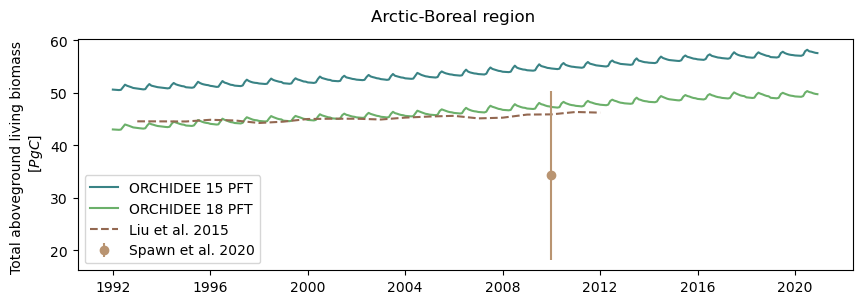

In [22]:
year, month = 2010, 0
timestep = (year-1992) * 12 + month
print(timearr[timestep])

myvar = 'TOTAL_AB_M_c' 
units = getattr(dataset[myvar], 'units')
varname = getattr(dataset[myvar], 'long_name')
print(varname, units)


# -----------------------------------------
# Calculate panarctic C stocks, accounting for grid area:
gridareafile = f'gridarea.50N.2deg_bl.nc'   
griddataset = Dataset(gridareafile)
cellarea = griddataset.variables['cell_area']
bawld_mask_area=np.broadcast_to(bawld_mask, cellarea.shape)             # not neccessary since the data is already masked
cellarea_masked = np.ma.masked_where(bawld_mask_area==0,cellarea)

# check whether this is correct! considering the shapes!
agb_area_ORC18 = total_AB_biomass_clean * cellarea_masked
agb_area_ORC15 = total_AB_biomass_clean_bl * cellarea_masked


#print(f'Total biomass ORC15: {np.nansum(agb_area_ORC15[:],axis=(1,2))}, Total biomass ORC18: {np.nansum(agb_area_ORC18[:],axis=(1,2))}')


agb_area_Liu_lowres = biomass_Liu_gCm2_clean_masked_lowres * cellarea_masked

obspath = 'obs_data/BIOMASS/Liu_2015'
gridfile_Liu = f'{obspath}/gridarea_Liu_highres.nc'
cellarea_Liu_highres = Dataset(gridfile_Liu).variables['cell_area']
agb_area_Liu_highres = biomass_Liu_gCm2_clean_masked_highres * cellarea_Liu_highres

agb_area_Spawn = Spawn_biomass_gCm2_clean_masked * cellarea_masked
unc_area_Spawn = Spawn_biomass_unc_gCm2_clean_masked * cellarea_masked


agb_area_ORC15 = agb_area_ORC15 / 1e+15
agb_area_ORC18 = agb_area_ORC18 / 1e+15

agb_area_Liu_lowres = agb_area_Liu_lowres / 1e+15

agb_area_Spawn = agb_area_Spawn / 1e+15
unc_area_Spawn = unc_area_Spawn / 1e+15

# PLOT ------------------------------

fig, ax = plt.subplots(1,1,figsize=(10,3))
ax.plot(timearr, np.nansum(agb_area_ORC15[:],axis=(1,2)), label = 'ORCHIDEE 15 PFT', color=cm.navia_r(140))
ax.plot(timearr, np.nansum(agb_area_ORC18[:],axis=(1,2)), label = 'ORCHIDEE 18 PFT', color=cm.navia_r(80))
ax.plot(timearr_Liu, np.nansum(agb_area_Liu_lowres[:],axis=(1,2)), label = 'Liu et al. 2015', color=mymap_brown.reversed()(120), linestyle='dashed')                       
ax.errorbar(timearr[timestep], np.nansum(agb_area_Spawn),yerr = np.nansum(unc_area_Spawn),fmt ='o', label='Spawn et al. 2020', color=mymap_brown.reversed()(80))  


ax.set(ylabel=f'{varname} \n [$PgC$]') 
ax.legend(loc='lower left')


print('Total AGB in 2010:')
print(f'Spawn et al. 2020: {np.nansum(agb_area_Spawn):.2f} ± {np.nansum(unc_area_Spawn):.2f} PgC')

ind = indices_for_year(timearr_Liu, 2010)
print(f'Liu et al. 2015: {np.nansum(agb_area_Liu_highres[:],axis=(1,2))[ind][0]:.2f} PgC')
print(f'Liu et al. 2015 (low res): {np.nansum(agb_area_Liu_lowres[:],axis=(1,2))[ind][0]:.2f} PgC')

ind = indices_for_year(timearr, 2010)
inds= ind[0]
ORC15 = np.mean(np.nansum(agb_area_ORC15[:],axis=(1,2))[inds])
print(f'ORCHIDEE 15 PFT: {ORC15:.2f} PgC')

ORC18 = np.nanmean(np.nansum(agb_area_ORC18[:],axis=(1,2))[inds])
print(f'ORCHIDEE 18 PFT: {ORC18:.2f} PgC')

reduction = (ORC15 - ORC18) / ORC15
print(f'ORCHIDEE {reduction*100:.2f}% reduction')

fig.suptitle('Arctic-Boreal region')


#fig.savefig(f'{savepath}fig6_b.pdf', format="pdf", bbox_inches="tight")


a) Maps

['2010-01-01T00:00' '2010-02-01T00:00' '2010-03-01T00:00'
 '2010-04-01T00:00' '2010-05-01T00:00' '2010-06-01T00:00'
 '2010-07-01T00:00' '2010-08-01T00:00' '2010-09-01T00:00'
 '2010-10-01T00:00' '2010-11-01T00:00' '2010-12-01T00:00']
ORC15
Agreement with Liu (35.0%): ------
valid cells:  942
Agreement: 309/942. 32.80%
Agreement weighted by area: 30.24%
Agreement with Spawn: ------
land cells:  1079
valid cells:  989
Agreement: 633/989. 64.00%
Agreement weighted by area: 56.93%
True


/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/570486488.py:49: RuntimeWarning: Mean of empty slice
  agb_model = np.nanmean(modeldata[timestep1:timestep2,:],axis=0) #plotdata[timestep1:timestep2,:]
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/570486488.py:73: RuntimeWarning: Mean of empty slice
  plotdata = np.nanmean(modeldata[timestep1:timestep2,:],axis=0)  # mean over all 12 months of the selected year
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/570486488.py:108: RuntimeWarning: Mean of empty slice
  modeldata_comp = np.nanmean(modeldata[timestep1:timestep2,:],axis=0)
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/570486488.py:111: RuntimeWarning: Mean of empty slice
  agb_model_18 = np.nanmean(modeldata_18[timestep1:timestep2,:],axis=0)
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/570486488.py:111: RuntimeWarning: Mean of empty slice
  agb_model_18 = np.nanmean(modeldata_18[timestep1:timest

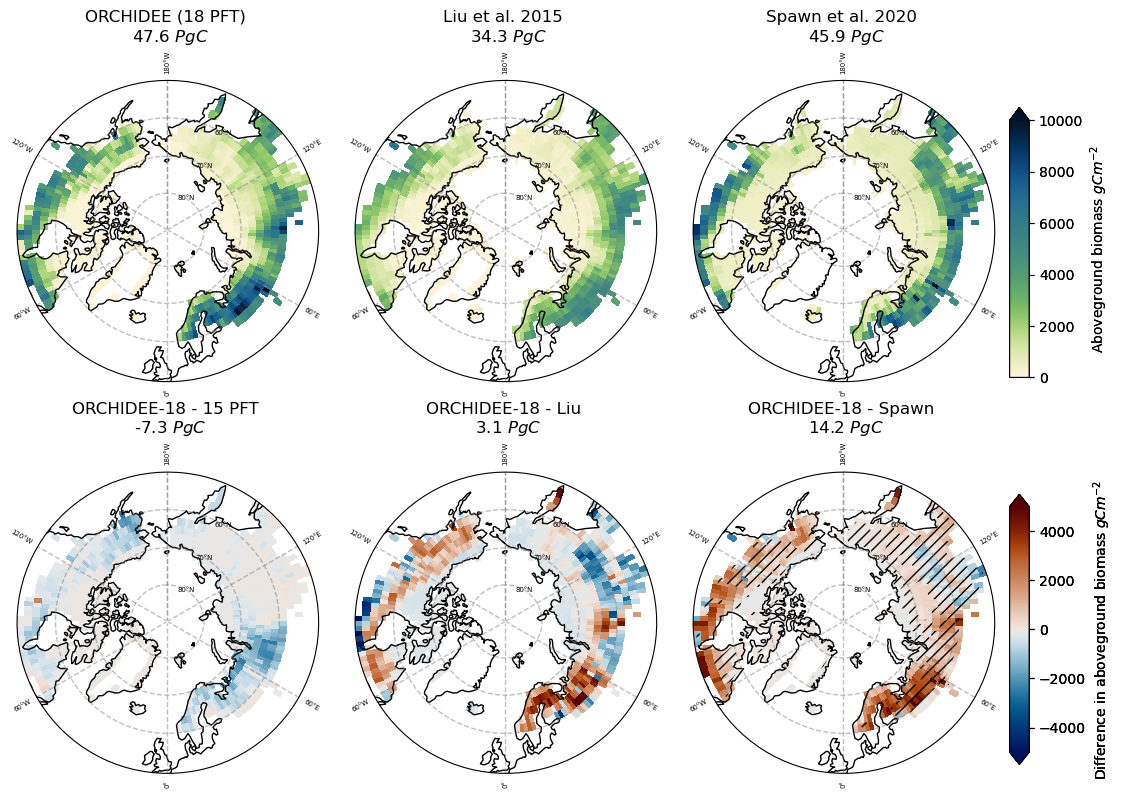

In [24]:

obsdata = Spawn_biomass_gCm2_clean_masked
obsdata2 = biomass_Liu_gCm2_clean_masked_lowres[indices_for_year(timearr_Liu, 2010)][0,:]
obsdata_unc = Spawn_biomass_unc_gCm2_clean_masked 
modeldata_list = [total_AB_biomass_clean, obsdata, obsdata2, total_AB_biomass_clean_bl, obsdata2, obsdata] 

npft_list = [18,15]
obsdata_names = ['15 PFT            ', 'Liu et al. 2015', 'Spawn et al. 2020']   
plot_round = True

year, month1, month2 = 2010, 0, 12

# automatic from here:
#-----------------------------
timestep1 = (year-1992) * 12 + month1
timestep2 = (year-1992) * 12 + month2
print(timearr[timestep1:timestep2])

# define uncertainty bounds
lower = obsdata - 2* obsdata_unc  
upper = obsdata + 2* obsdata_unc  
within_uncertainty_old = 0

# PLOT MAP:
#-----------------------------
# choose map projection:
myprojection = ccrs.NorthPolarStereo() 

#-----------------------------
# Plot:
# create figure object:
rows, cols = 2, 3
fig, axs = plt.subplots(rows,cols, figsize=(13,9),subplot_kw={'projection': myprojection})
plt.subplots_adjust(wspace=0.02, hspace=0.3)   # optional adjustments to the figure
i = 0
for row in range(rows):
    for col in range(cols):
        
        ax = axs[row,col]
        # define map extent (W, E, S, N)
        ax.set_extent([0, 360, 50, 90], ccrs.PlateCarree()) 

        mycmap = cm.navia_r 
        vmin, vmax = 0,10000
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)  

        modeldata = modeldata_list[i]

        if i == 0:
            agb_model = np.nanmean(modeldata[timestep1:timestep2,:],axis=0) #plotdata[timestep1:timestep2,:]
            im = ax.pcolormesh(longitude, latitude, agb_model, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm)
            
            add_hatching = False
            if add_hatching:
                print('land cells: ', agb_model.count())
                # valid data mask
                valid = np.isfinite(obsdata) & np.isfinite(obsdata_unc) & np.isfinite(agb_model)
                print(np.shape(valid))
                print('valid cells: ', valid.count())
                # model-within-uncertainty mask
                within_uncertainty = np.zeros_like(agb_model, dtype=bool)
                print(np.shape(within_uncertainty))
                within_uncertainty = (
                    (agb_model >= lower) &
                    (agb_model <= upper) &
                    valid  # <- ensures NaN cells are excluded
                )
                #print(np.shape(within_uncertainty))
                print(f'Agreement: {np.sum(within_uncertainty)}. {np.sum(within_uncertainty)/valid.count()*100:.2f}%')
                print(f'Agreement weighted by area: {(within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100:.2f}%')
                cs = ax.contourf(longitude, latitude, within_uncertainty, levels=[0.5, 1.5], hatches=['///'], colors='none', transform=ccrs.PlateCarree())
                
            
            plotdata = np.nanmean(modeldata[timestep1:timestep2,:],axis=0)  # mean over all 12 months of the selected year
            #plotdata = np.sum(plotdata,axis=(0,1))                         # sum over the entire area
            mask = np.isfinite(plotdata) & np.isfinite(cellarea_masked)
            x = plotdata[mask]
            w = cellarea_masked[mask]
            sum_w = np.sum(w * x) / 1e+15    # convert to Pg
            mean_w = np.sum(w * x) / np.sum(w)
            var_w  = np.sum(w * (x - mean_w)**2) / np.sum(w)
            std_w  = np.sqrt(var_w)

            npft = npft_list[i]
            plotname = f'ORCHIDEE ({npft} PFT) \n {sum_w:.1f} $Pg C$' 
            ax.set(title = plotname) 

        elif i in [1,2]:
            im = ax.pcolormesh(longitude, latitude, modeldata, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm)

            mask = np.isfinite(modeldata) & np.isfinite(cellarea_masked)
            x = modeldata[mask]
            w = cellarea_masked[mask]
            sum_w = np.sum(w * x) / 1e+15    # convert to Pg
            ax.set(title = f'{obsdata_names[i]} \n {sum_w:.1f} $Pg C$')  

            # colorbar
            cb_ax = fig.add_axes([0.9, 0.55, 0.015, 0.3])      
            cbar = fig.colorbar(im, cax=cb_ax, extend="max") 
            cbar.set_label(f'Aboveground biomass $gC m^{{-2}}$') 



        # -------- ORC 18 - ORC 15 / Spawn / Liu
        else:
            modeldata_comp = modeldata
            if np.shape(modeldata_list[i])[0] > 20:   # for ORCHIDEE data:
                print('ORC15')
                modeldata_comp = np.nanmean(modeldata[timestep1:timestep2,:],axis=0) 

            modeldata_18 = modeldata_list[0]
            agb_model_18 = np.nanmean(modeldata_18[timestep1:timestep2,:],axis=0) 

            difference = agb_model_18 - modeldata_comp
            mask = np.isfinite(difference) & np.isfinite(cellarea_masked)
            x = difference[mask]
            w = cellarea_masked[mask]
            sum_w = np.sum(w * x) / 1e+15    # convert to Pg

            mycmap = cm.vik
            vmin, vmax = -5000,5000
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)  
            
            # plot map
            im = ax.pcolormesh(longitude, latitude, difference, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm)
            plotinfo = f'{sum_w:.1f} $Pg C$'

            if i == 5: # add hatching for agreement with Spawn:
                print('Agreement with Spawn: ------')
                print('land cells: ', agb_model_18.count())
                # valid data mask
                valid = np.isfinite(obsdata) & np.isfinite(obsdata_unc) & np.isfinite(agb_model_18)
                print('valid cells: ', valid.count())

                # model-within-uncertainty mask
                within_uncertainty = np.zeros_like(agb_model_18, dtype=bool)
                within_uncertainty = (
                    (agb_model_18 >= lower) &
                    (agb_model_18 <= upper) &
                    valid  # <- ensures NaN cells are excluded
                )
                print(f'Agreement: {np.sum(within_uncertainty)}/{valid.count()}. {np.sum(within_uncertainty)/valid.count()*100:.2f}%')
                agreement_area = (within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100
                print(f'Agreement weighted by area: {(within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100:.2f}%')
                
                cs = ax.contourf(longitude, latitude, within_uncertainty, levels=[0.5, 1.5], hatches=['///'], colors='none', transform=ccrs.PlateCarree())


            elif i == 4:  # add hatching for Liu:
                agreement_perc = 0.35
                print(f'Agreement with Liu ({agreement_perc*100}%): ------')

                obsdata_liu = modeldata_comp
                
                lower_liu = obsdata_liu - agreement_perc * obsdata_liu
                upper_liu = obsdata_liu + agreement_perc * obsdata_liu

                # valid data mask
                valid = np.isfinite(obsdata_liu) &  np.isfinite(agb_model_18)
                print('valid cells: ', valid.count())

                # model-within-uncertainty mask
                within_uncertainty = np.zeros_like(agb_model_18, dtype=bool)
                within_uncertainty = (
                    (agb_model_18 >= lower_liu) &
                    (agb_model_18 <= upper_liu) &
                    valid  # <- ensures NaN cells are excluded
                )
                print(f'Agreement: {np.sum(within_uncertainty)}/{valid.count()}. {np.sum(within_uncertainty)/valid.count()*100:.2f}%')
                agreement_area = (within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100
                print(f'Agreement weighted by area: {(within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100:.2f}%')

            ax.set(title = f'ORCHIDEE-18 - {obsdata_names[i-3][:-12]} \n {plotinfo}')  

            cb_ax = fig.add_axes([0.9, 0.12, 0.015, 0.3])       
            extendcbar = "both"
            cbar = fig.colorbar(im, cax=cb_ax, extend=extendcbar) 
            cbar.set_label(f'Difference in aboveground biomass $gC m^{{-2}}$') 


        # add lon-lat gridlines:
        specific_latitudes = [50, 60, 70, 80, 90]
        gl = ax.gridlines(crs=ccrs.PlateCarree(), ylocs=specific_latitudes, draw_labels=True, linewidth=1, color='grey', alpha=0.5, linestyle='--')
        gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
        gl.xlabel_style = {'size': 5, 'color': 'black'}
        gl.ylabel_style = {'size': 5, 'color': 'black'}
        # add coastlines
        ax.coastlines()   
        # make plot edges round:
        if plot_round:
            theta = np.linspace(0, 2*np.pi, 100)
            center, radius = [0.5, 0.5], 0.5
            verts = np.vstack([np.sin(theta), np.cos(theta)]).T
            circle = mpath.Path(verts * radius + center)
            ax.set_boundary(circle, transform=ax.transAxes)

        i += 1


#fig.savefig(f'{savepath}fig6_a.pdf', format="pdf", bbox_inches="tight")


Supplementary Figure B4: for ORCHIDEE with 15 PFTs

['2010-01-01T00:00' '2010-02-01T00:00' '2010-03-01T00:00'
 '2010-04-01T00:00' '2010-05-01T00:00' '2010-06-01T00:00'
 '2010-07-01T00:00' '2010-08-01T00:00' '2010-09-01T00:00'
 '2010-10-01T00:00' '2010-11-01T00:00' '2010-12-01T00:00']
ORC15
Agreement with Liu (35.0%): ------
valid cells:  942
Agreement: 325/942. 34.50%
Agreement weighted by area: 30.85%
Agreement with Spawn: ------
land cells:  1079
valid cells:  989
Agreement: 479/989. 48.43%
Agreement weighted by area: 42.91%


/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/25497478.py:50: RuntimeWarning: Mean of empty slice
  agb_model = np.nanmean(modeldata[timestep1:timestep2,:],axis=0)
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/25497478.py:73: RuntimeWarning: Mean of empty slice
  plotdata = np.nanmean(modeldata[timestep1:timestep2,:],axis=0) # mean over all 12 months of the selected year
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/25497478.py:110: RuntimeWarning: Mean of empty slice
  modeldata_comp = np.nanmean(modeldata[timestep1:timestep2,:],axis=0)
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/25497478.py:113: RuntimeWarning: Mean of empty slice
  agb_model_18 = np.nanmean(modeldata_18[timestep1:timestep2,:],axis=0)
/var/folders/78/1vdjyt1s4nv7bmzv_zjyt75s_4nvws/T/ipykernel_2007/25497478.py:113: RuntimeWarning: Mean of empty slice
  agb_model_18 = np.nanmean(modeldata_18[timestep1:timestep2,:],axis=0)
/var/folders/78/1vdjyt1s

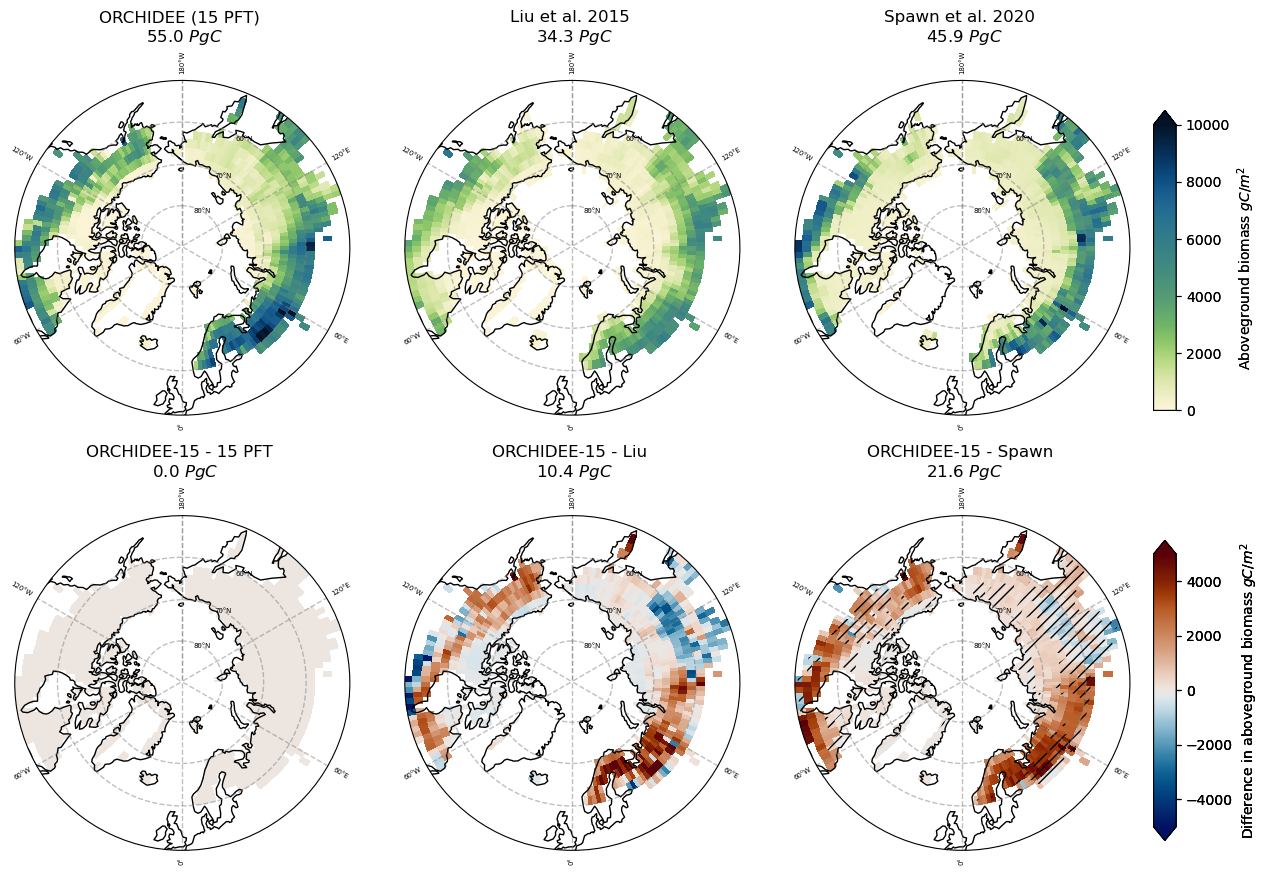

In [25]:

obsdata = Spawn_biomass_gCm2_clean_masked
obsdata2 = biomass_Liu_gCm2_clean_masked_lowres[indices_for_year(timearr_Liu, 2010)][0,:]
obsdata_unc = Spawn_biomass_unc_gCm2_clean_masked 
modeldata_list = [total_AB_biomass_clean_bl, obsdata, obsdata2, total_AB_biomass_clean_bl, obsdata2, obsdata] 

npft_list = [15,15]
obsdata_names = ['15 PFT            ', 'Liu et al. 2015', 'Spawn et al. 2020']
plot_round = True

year, month1, month2 = 2010, 0, 12

# automatic from here:
#-----------------------------
timestep1 = (year-1992) * 12 + month1
timestep2 = (year-1992) * 12 + month2
print(timearr[timestep1:timestep2])

# define uncertainty bounds
lower = obsdata - 2* obsdata_unc  
upper = obsdata + 2* obsdata_unc   
within_uncertainty_old = 0
# PLOT MAP:
#-----------------------------
# Settings:

# choose map projection:
myprojection = ccrs.NorthPolarStereo() 

#-----------------------------
# Plot:
# create figure object:
rows, cols = 2, 3
fig, axs = plt.subplots(rows,cols, figsize=(15,10),subplot_kw={'projection': myprojection})
plt.subplots_adjust(wspace=0.02, hspace=0.3)   # optional adjustments to the figure
i = 0
for row in range(rows):
    for col in range(cols):
        
        ax = axs[row,col]
        # define map extent (W, E, S, N)
        ax.set_extent([0, 360, 50, 90], ccrs.PlateCarree()) 

        mycmap = cm.navia_r 
        vmin, vmax = 0,10000
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)  

        modeldata = modeldata_list[i]

        if i == 0:
            agb_model = np.nanmean(modeldata[timestep1:timestep2,:],axis=0) 
            im = ax.pcolormesh(longitude, latitude, agb_model, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm)
            
            add_hatching = False
            if add_hatching:
                print('land cells: ', agb_model.count())
                # valid data mask
                valid = np.isfinite(obsdata) & np.isfinite(obsdata_unc) & np.isfinite(agb_model)
                print(np.shape(valid))
                print('valid cells: ', valid.count())
                # model-within-uncertainty mask
                within_uncertainty = np.zeros_like(agb_model, dtype=bool)
                print(np.shape(within_uncertainty))
                within_uncertainty = (
                    (agb_model >= lower) &
                    (agb_model <= upper) &
                    valid  # <- ensures NaN cells are excluded
                )
                print(f'Agreement: {np.sum(within_uncertainty)}. {np.sum(within_uncertainty)/valid.count()*100:.2f}%')
                print(f'Agreement weighted by area: {(within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100:.2f}%')
                cs = ax.contourf(longitude, latitude, within_uncertainty, levels=[0.5, 1.5], hatches=['///'], colors='none', transform=ccrs.PlateCarree())
                
            
            plotdata = np.nanmean(modeldata[timestep1:timestep2,:],axis=0) # mean over all 12 months of the selected year
            #plotdata = np.sum(plotdata,axis=(0,1))                         # sum over the entire area
            mask = np.isfinite(plotdata) & np.isfinite(cellarea_masked)
            x = plotdata[mask]
            w = cellarea_masked[mask]
            sum_w = np.sum(w * x) / 1e+15    # convert to Pg
            mean_w = np.sum(w * x) / np.sum(w)
            var_w  = np.sum(w * (x - mean_w)**2) / np.sum(w)
            std_w  = np.sqrt(var_w)

            npft = npft_list[i]
            plotname = f'ORCHIDEE ({npft} PFT) \n {sum_w:.1f} $Pg C$' 
            ax.set(title = plotname) 


        elif i in [1,2]:
            im = ax.pcolormesh(longitude, latitude, modeldata, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm)

            mask = np.isfinite(modeldata) & np.isfinite(cellarea_masked)
            x = modeldata[mask]
            w = cellarea_masked[mask]
            sum_w = np.sum(w * x) / 1e+15    # convert to Pg
            ax.set(title = f'{obsdata_names[i]} \n {sum_w:.1f} $Pg C$') 

            # colorbar
            cb_ax = fig.add_axes([0.9, 0.55, 0.015, 0.3])       
            cbar = fig.colorbar(im, cax=cb_ax, extend="max") 
            cbar.set_label(f'Aboveground biomass $gC/m^{2}$') 



        # -------- ORC 18 - ORC 15 / Spawn / Liu
        else:
            #modeldata_bl = modeldata_list[-1]
            modeldata_comp = modeldata
            if np.shape(modeldata_list[i])[0] > 20:   # for ORCHIDEE data:
                print('ORC15')
                modeldata_comp = np.nanmean(modeldata[timestep1:timestep2,:],axis=0) 

            modeldata_18 = modeldata_list[0]
            agb_model_18 = np.nanmean(modeldata_18[timestep1:timestep2,:],axis=0) 

            difference = agb_model_18 - modeldata_comp
            mask = np.isfinite(difference) & np.isfinite(cellarea_masked)
            x = difference[mask]
            w = cellarea_masked[mask]
            sum_w = np.sum(w * x) / 1e+15    # convert to Pg

            mycmap = cm.vik
            vmin, vmax = -5000,5000
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)  
            
            # plot map
            im = ax.pcolormesh(longitude, latitude, difference, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm)
            plotinfo = f'{sum_w:.1f} $Pg C$'

            if i == 5: # add hatching for agreement with Spawn:
                print('Agreement with Spawn: ------')
                print('land cells: ', agb_model_18.count())
                # valid data mask
                valid = np.isfinite(obsdata) & np.isfinite(obsdata_unc) & np.isfinite(agb_model_18)
                print('valid cells: ', valid.count())

                # model-within-uncertainty mask
                within_uncertainty = np.zeros_like(agb_model_18, dtype=bool)
                within_uncertainty = (
                    (agb_model_18 >= lower) &
                    (agb_model_18 <= upper) &
                    valid  # <- ensures NaN cells are excluded
                )
                print(f'Agreement: {np.sum(within_uncertainty)}/{valid.count()}. {np.sum(within_uncertainty)/valid.count()*100:.2f}%')
                agreement_area = (within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100
                print(f'Agreement weighted by area: {(within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100:.2f}%')
                
                cs = ax.contourf(longitude, latitude, within_uncertainty, levels=[0.5, 1.5], hatches=['///'], colors='none', transform=ccrs.PlateCarree())


            elif i == 4:  # add hatching for Liu:
                agreement_perc = 0.35
                print(f'Agreement with Liu ({agreement_perc*100}%): ------')

                obsdata_liu = modeldata_comp
                
                lower_liu = obsdata_liu - agreement_perc * obsdata_liu
                upper_liu = obsdata_liu + agreement_perc * obsdata_liu

                # valid data mask
                valid = np.isfinite(obsdata_liu) &  np.isfinite(agb_model_18)
                print('valid cells: ', valid.count())

                # model-within-uncertainty mask
                within_uncertainty = np.zeros_like(agb_model_18, dtype=bool)
                within_uncertainty = (
                    (agb_model_18 >= lower_liu) &
                    (agb_model_18 <= upper_liu) &
                    valid  # <- ensures NaN cells are excluded
                )
                print(f'Agreement: {np.sum(within_uncertainty)}/{valid.count()}. {np.sum(within_uncertainty)/valid.count()*100:.2f}%')
                agreement_area = (within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100
                print(f'Agreement weighted by area: {(within_uncertainty * cellarea_masked).sum()/cellarea_masked.sum()*100:.2f}%')
 
            ax.set(title = f'ORCHIDEE-{npft} - {obsdata_names[i-3][:-12]} \n {plotinfo}')

            cb_ax = fig.add_axes([0.9, 0.12, 0.015, 0.3])       
            extendcbar = "both"
            cbar = fig.colorbar(im, cax=cb_ax, extend=extendcbar) 
            cbar.set_label(f'Difference in aboveground biomass $gC/m^{2}$') 

        # add lon-lat gridlines:
        specific_latitudes = [50, 60, 70, 80, 90]
        gl = ax.gridlines(crs=ccrs.PlateCarree(), ylocs=specific_latitudes, draw_labels=True, linewidth=1, color='grey', alpha=0.5, linestyle='--')
        gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
        gl.xlabel_style = {'size': 5, 'color': 'black'}
        gl.ylabel_style = {'size': 5, 'color': 'black'}
        # add coastlines
        ax.coastlines()   
        # make plot edges round:
        if plot_round:
            theta = np.linspace(0, 2*np.pi, 100)
            center, radius = [0.5, 0.5], 0.5
            verts = np.vstack([np.sin(theta), np.cos(theta)]).T
            circle = mpath.Path(verts * radius + center)
            ax.set_boundary(circle, transform=ax.transAxes)

        i += 1

# save figure
#fig.savefig(f'{savepath}figB4.pdf', format="pdf", bbox_inches="tight")
       

# Figure 7: Arctic-Boreal GPP

Observational data obtained from:
* CARDAMOM: Hugelius et al. (2024): Permafrost Region Greenhouse Gas Budgets Suggest a Weak CO2 Sink and CH4 and N2O Sources, But Magnitudes Differ Between Top-Down and Bottom-Up Methods, Global Biogeochem. Cy., 38, e2023GB007969, https://doi.org/10.1029/2023GB007969.
* FLUXCOM: Jung et al. (2019): The FLUXCOM ensemble of global land-atmosphere energy fluxes, Sci. Data, 6, 74, https://doi.org/10.1038/s41597-019-0076-8.
* Virkkala et al. (2021): Statistical upscaling of ecosystem CO2 fluxes across the terrestrial tundra and boreal domain: Regional patterns and uncertainties, Glob. Change Biol., 27, 4040–4059, https://doi.org/10.1111/gcb.15659.



1. Define functions

In [37]:
# -----------------------------------------------------
# CARDAMOM:
# -----------------------------------------------------
def load_cardamom_data():
    obspath = 'obs_data/CFLUXES/CARDAMOM_Hugelius'
    obsfile = f'{obspath}/ann_CFLUX_2001_2019_ORCres.nc'           
    dataset_cm = Dataset(obsfile)

    lat_cm = dataset_cm.variables['lat'][:]
    lon_cm = dataset_cm.variables['lon'][:]

    time = dataset_cm.variables['time'][:]  #Monthly time step given in days since 01/01/2001
    ref_date = pd.Timestamp("2000-12-01")
    timearr_cm = ref_date + pd.to_timedelta(time, unit="D")

    var = dataset_cm.variables['annual_gpp_ensemble']
    gpp_cm = np.ma.masked_equal(var[:], var._FillValue)   # mask out values with FillValue


    # convert from kg.m-2.s-1 to g C / m2 / yr
    def seconds_in_year(year): 
        start = datetime(year, 1, 1) 
        end = datetime(year + 1, 1, 1) 
        return int((end - start).total_seconds()) 
    years = range(2001, 2020) 
    seconds_per_year = np.array([seconds_in_year(year) for year in years])
    seconds_per_year = seconds_per_year[:, np.newaxis, np.newaxis, np.newaxis]

    cardamom_gpp_m2yr = gpp_cm * 1000 * seconds_per_year

    return cardamom_gpp_m2yr



# -----------------------------------------------------
# FLUXCOM
# -----------------------------------------------------
def load_fluxcom_data(mask=1, annsum=True):
    convert = True

    obspath = 'obs_data/CFLUXES/fluxcom'
    obsfile = f'{obspath}/fluxcom_gpp_2001_2015_month_50N.nc'           # monthly means
    dataset_fluxcom = Dataset(obsfile)
    myvar = 'gpp'
    var = dataset_fluxcom.variables[myvar]
    gpp_fluxcom = np.ma.masked_equal(var[:], var._FillValue)   # mask out values with FillValue
    gpp_fluxcom = gpp_fluxcom[:,0,:,:]  # select (the only) height level z

    # convert kg m-2 s-1 to g m-2 d-1
    if convert: 
        gpp_fluxcom_m2day = gpp_fluxcom * 86400 * 1000              # every day has 86400 seconds
        gpp_fluxcom = gpp_fluxcom_m2day

    # apply mask:
    mask_fluxcom=np.broadcast_to(mask, gpp_fluxcom.shape)
    gpp_fluxcom_masked = np.ma.masked_where(mask_fluxcom==0,gpp_fluxcom)     


    # extract uncertainty
    myvar = 'gpp_mad'
    var = dataset_fluxcom.variables[myvar]
    gpp_fluxcom_mad = np.ma.masked_equal(var[:], var._FillValue)              # mask out values with FillValue
    gpp_fluxcom_mad = gpp_fluxcom_mad[:,0,:,:]                                # select height level
    gpp_fluxcom_mad = gpp_fluxcom_mad * 86400 * 1000                          # convert units
    gpp_fluxcom_mad = np.ma.masked_where(mask_fluxcom==0,gpp_fluxcom_mad)     # apply region mask


    # calculate annual sum of GPP (from monthly values)
    if annsum:
        time_var = dataset_fluxcom.variables['time_centered']
        time_cftime = num2date(time_var[:], units=time_var.units, calendar=time_var.calendar)
        days = np.array([d.day for d in time_cftime])     
        days_in_month = days    # array containing number of days in each month
        days_in_month = days_in_month[:, None, None]
        dates_dt = np.array([datetime(d.year, d.month, d.day) for d in time_cftime])
        monthly_total = gpp_fluxcom_masked * days_in_month           # multiply with days per month to get monthly totals
        ntime, nlat, nlon = monthly_total.shape
        data_2d = monthly_total.reshape(ntime, -1)
        df = pd.DataFrame(data_2d, index=dates_dt)
        annual_sum = df.resample("YS").sum()
        years = annual_sum.index.to_numpy()
        gpp_fluxcom_annual_sum = annual_sum.to_numpy().reshape(len(years), nlat, nlon)

        # same for uncertainty
        monthly_total_mad = gpp_fluxcom_mad * days_in_month           # multiply with days per month to get monthly totals
        data_2d = monthly_total_mad.reshape(ntime, -1)
        df = pd.DataFrame(data_2d, index=dates_dt)
        annual_sum = df.resample("YS").sum()
        gpp_fluxcom_mad_annual_sum = annual_sum.to_numpy().reshape(len(years), nlat, nlon)


        return gpp_fluxcom_annual_sum, gpp_fluxcom_mad_annual_sum
    
    else:
        return gpp_fluxcom_masked, gpp_fluxcom_mad



# -----------------------------------------------------
# VIRKKALA et al. 2021
# -----------------------------------------------------
obspath = 'obs_data/CFLUXES/Virkkala_2021/'
obsfile = f'{obspath}/anngpp_all_1992_2015_median_ORCres.nc'      
dataset_cm = Dataset(obsfile)
gpp_virkkala = dataset_cm.variables['Band1'][:]      #  g C m-2 yr-1 (cumulative flux). Need to be multiplied by 0.01.
gpp_virkkala = gpp_virkkala * 0.01


# -----------------------------------------------------
# ORCHIDEE
# -----------------------------------------------------
def load_ORC_GPP(plotdataset, timearr, mask=1, myvar='GPP', annsum = True):
    var = plotdataset.variables[myvar]
    GPP= np.ma.masked_equal(var[:], var._FillValue)   # mask out values with FillValue
    veget_frac = plotdataset.variables['VEGET_MAX'][:]
    mymask = np.broadcast_to(mask, GPP.shape)
    GPP_masked  = np.ma.masked_where(mymask==0,GPP)                  # mask region
    veget_frac_masked  = np.ma.masked_where(mymask==0,veget_frac)    # mask region
    
    GPP_PFT = GPP_masked * veget_frac_masked    # multiply with PFT fraction
    GPP_PFT_all = np.sum(GPP_PFT, axis=1)       # sum over all PFTs
    #total_GPP_clean = np.ma.where(total_AB_biomass==0, np.nan, total_AB_biomass)  # replace 0 with NaN to prevent from showing up in the plot

    if annsum:                                         # calculate annual sum
            data = GPP_PFT_all
            ntime, nlat, nlon = data.shape
            data_2d = data.reshape(ntime, -1)
            df = pd.DataFrame(data_2d, index=timearr)
            annual_sum = df.groupby(df.index.year).sum()
            years = annual_sum.index.to_numpy()
            annual_sum_array = annual_sum.to_numpy().reshape(len(years), nlat, nlon)
            total_GPP_year = annual_sum_array 

            ORC_GPP = total_GPP_year
    else:
        ORC_GPP = GPP_PFT_all


    npft = np.shape(GPP_masked)[1]
    
    if annsum:
        units = 'gC/m^2/yr'
    else:
        units = 'gC/m^2/d'

    return ORC_GPP, npft, units



2. Load data (full timeseries)

In [ ]:

gpp_cardamom = load_cardamom_data()
gpp_fluxcom, gpp_fluxcom_mad = load_fluxcom_data()

gpp_ORCHIDEE15, npft_bl, units = load_ORC_GPP(dataset_d_bl, timearr_daily)    # with daily data
gpp_ORCHIDEE18, npft_18, units = load_ORC_GPP(dataset_daily, timearr_daily)


print(f'Shape CARDAMOM: {np.shape(gpp_cardamom)}')         # = 19 years, 7 quantiles, 20 x 180 grid cells
print(f'Shape FLUXCOM: {np.shape(gpp_fluxcom)}')           # = 15 years, 20 x 180 grid cells
print(f'Shape ORCHIDEE: {np.shape(gpp_ORCHIDEE18)}')       # = 21 years, 20 x 180 grid cells


# CALCULATE GRID CELL AREA:
# ------------------------------------------
step = 2.0
lat = np.arange(90 - step/2., 50, -step)
lon = np.arange(-180 + step/2., 180, step)
cellarea_calc = 2 * 6.371229E6**2 * np.repeat(step, len(longitude))[None,:] * np.pi/180 * np.sin(0.5 * np.repeat(step, len(latitude))[:,None] * np.pi/180) * np.cos(latitude[:,None] * np.pi/180)


3. Calculate weighted mean:

In [39]:
def calc_wmean(data, area, mask = 1, contfrac = 1, dosum = False, add_std=False):
    '''Function from Vlad'''
    if hasattr(area, "mask"): 
        area = np.where(area.mask == False, area, 0)
        #print('unmasked area')
    
    if hasattr(data, "mask"): 
        loc_area = np.where(data.mask == False, area * contfrac * mask, 0)
    else: 
        loc_area = area * contfrac * mask
    if dosum == False: 
        out = (data * loc_area).sum(axis=-1).sum(axis=-1) / loc_area.sum(axis=-1).sum(axis=-1)
    else: 
        out = (data * loc_area).sum(axis=-1).sum(axis=-1)
    if add_std and not dosum:
        mean_w = (data * loc_area).sum(axis=-1).sum(axis=-1) / loc_area.sum(axis=-1).sum(axis=-1)
        mean_w = mean_w[..., None, None]
        var_w  = (loc_area * (data - mean_w)**2).sum(axis=-1).sum(axis=-1) / loc_area.sum(axis=-1).sum(axis=-1)       # doesn't work, incompatible shapes
        std_w  = np.sqrt(var_w)
        return out, std_w

    return out



iregion = 0
masklist = [bawld_mask, tundra_mask, boreal_mask]
regions = ['BAWLD', 'Tundra', 'Boreal']
mymask,myregion = masklist[iregion], regions[iregion]
print(regions[iregion])

gpp_cardamom_wmean, gpp_cardamom_wstd = calc_wmean(gpp_cardamom, area=cellarea_calc, mask=mymask, add_std=True)
#print(np.shape(gpp_cardamom), np.shape(cellarea_calc), np.shape(mymask), np.shape(wmean))

gpp_fluxcom_wmean, gpp_fluxcom_wstd = calc_wmean(gpp_fluxcom, area=cellarea_calc, mask=mymask, add_std=True)
gpp_fluxcom_mad_wmean = calc_wmean(gpp_fluxcom_mad, area=cellarea_calc, mask=mymask)

gpp_virkkala_wmean, gpp_virkkala_wstd = calc_wmean(gpp_virkkala, area=cellarea_calc, mask=mymask, add_std=True)

gpp_ORCHIDEE15_wmean, gpp_ORCHIDEE15_wstd = calc_wmean(gpp_ORCHIDEE15, area=cellarea_calc, mask=mymask, add_std=True)
gpp_ORCHIDEE18_wmean, gpp_ORCHIDEE18_wstd = calc_wmean(gpp_ORCHIDEE18, area=cellarea_calc, mask=mymask, add_std=True)


print(f'Shape CARDAMOM: {np.shape(gpp_cardamom_wmean)}')         # = 19 years, 7 quantiles: 2001 - 2019
print(f'Shape FLUXCOM: {np.shape(gpp_fluxcom_wmean)}')           # = 15 years: 2001-2015
print(f'Shape Virkkala: {np.shape(gpp_virkkala_wmean)}')           # = 16 years: 2000-2015
print(f'Shape ORCHIDEE: {np.shape(gpp_ORCHIDEE18_wmean)}\n')       # = 21 years: 2000-2020

# test for 2010:
testyear = 2010
iyear = 18     # for datasets starting in 1992
print(regions[iregion], testyear)
print(f'CARDAMOM weighted mean 2010: {gpp_cardamom_wmean[9,3]:.1f}')
print(f'FLUXCOM weighted mean 2010: {gpp_fluxcom_wmean[9]:.1f}')
print(f'Virkkala weighted mean 2010: {gpp_virkkala_wmean[iyear]:.1f}')
print(f'ORCHIDEE-15 weighted mean 2010: {gpp_ORCHIDEE15_wmean[iyear]:.1f}')   # 10
print(f'ORCHIDEE-18 weighted mean 2010: {gpp_ORCHIDEE18_wmean[iyear]:.1f}')
percred = (gpp_ORCHIDEE15_wmean[iyear] - gpp_ORCHIDEE18_wmean[iyear]) / gpp_ORCHIDEE15_wmean[iyear]
print(f'ORCHIDEE improvement: {percred*100:.2f}%')



print(f'\n{regions[iregion]} all years')
print(f'ORCHIDEE-15 weighted mean ({len(gpp_ORCHIDEE15_wmean)} years): {np.mean(gpp_ORCHIDEE15_wmean):.1f} ± {np.mean(gpp_ORCHIDEE15_wstd):.1f}')
print(f'ORCHIDEE-18 weighted mean ({len(gpp_ORCHIDEE18_wmean)} years): {np.mean(gpp_ORCHIDEE18_wmean):.1f} ± {np.mean(gpp_ORCHIDEE18_wstd):.1f}')
percred = (gpp_ORCHIDEE15_wmean - gpp_ORCHIDEE18_wmean) / gpp_ORCHIDEE15_wmean
print(f'ORCHIDEE improvement: {np.mean(percred)*100:.2f}%')
percred = (np.mean(gpp_ORCHIDEE15_wmean) - np.mean(gpp_ORCHIDEE18_wmean)) / np.mean(gpp_ORCHIDEE15_wmean)
print(f'ORCHIDEE improvement: {percred*100:.2f}%')
print(f'CARDAMOM weighted mean ({len(gpp_cardamom_wmean[:,3])} years): {np.mean(gpp_cardamom_wmean[:,3]):.1f} ± {np.mean(gpp_cardamom_wstd):.1f}')
print(f'CARDAMOM weighted mean (IQR) ({len(gpp_cardamom_wmean[:,3])} years): {np.mean(gpp_cardamom_wmean[:,3]):.1f} ({np.mean(gpp_cardamom_wmean[:,0]):.1f} - {np.mean(gpp_cardamom_wmean[:,6]):.1f})')
print(f'FLUXCOM weighted mean ({len(gpp_fluxcom_wmean)} years): {np.mean(gpp_fluxcom_wmean):.1f} ± {np.mean(gpp_fluxcom_wstd):.1f}')
print(f'FLUXCOM weighted mean ± MAD ({len(gpp_fluxcom_wmean)} years): {np.mean(gpp_fluxcom_wmean):.1f} ± {np.mean(gpp_fluxcom_mad_wmean):.1f}')
#print(f'Virkkala weighted mean (1 year): {np.mean(gpp_virkkala_wmean):.1f} ± {np.mean(gpp_virkkala_wstd):.1f}')
print(f'Virkkala weighted mean ({len(gpp_virkkala_wmean)} years): {np.mean(gpp_virkkala_wmean):.1f} ± {np.mean(gpp_virkkala_wstd):.1f}')

plottime = np.arange(len(gpp_ORCHIDEE18_wmean)) + 1992
years = [str(num) for num in plottime]
istart, iend = 9, 23
print(f'\nORCHIDEE-18 weighted mean {years[istart]}-{years[iend]} ({len(gpp_ORCHIDEE18_wmean[istart:iend+1])} years): {np.mean(gpp_ORCHIDEE18_wmean[istart:iend+1]):.1f} ± {np.mean(gpp_ORCHIDEE18_wstd[istart:iend+1]):.1f}')

istart, iend = 9, 27
print(f'ORCHIDEE-18 weighted mean {years[istart]}-{years[iend]} ({len(gpp_ORCHIDEE18_wmean[istart:iend+1])} years): {np.mean(gpp_ORCHIDEE18_wmean[istart:iend+1]):.1f} ± {np.mean(gpp_ORCHIDEE18_wstd[istart:iend+1]):.1f}')

istart, iend = 0, 23
print(f'ORCHIDEE-15 weighted mean {years[istart]}-{years[iend]} ({len(gpp_ORCHIDEE15_wmean[istart:iend+1])} years): {np.mean(gpp_ORCHIDEE15_wmean[istart:iend+1]):.1f} ± {np.mean(gpp_ORCHIDEE15_wstd[istart:iend+1]):.1f}')
print(f'ORCHIDEE-18 weighted mean {years[istart]}-{years[iend]} ({len(gpp_ORCHIDEE18_wmean[istart:iend+1])} years): {np.mean(gpp_ORCHIDEE18_wmean[istart:iend+1]):.1f} ± {np.mean(gpp_ORCHIDEE18_wstd[istart:iend+1]):.1f}')



BAWLD
Shape CARDAMOM: (19, 7)
Shape FLUXCOM: (15,)
Shape Virkkala: (24,)
Shape ORCHIDEE: (29,)

BAWLD 2010
CARDAMOM weighted mean 2010: 401.8
FLUXCOM weighted mean 2010: 350.5
Virkkala weighted mean 2010: 514.7
ORCHIDEE-15 weighted mean 2010: 513.7
ORCHIDEE-18 weighted mean 2010: 495.5
ORCHIDEE improvement: 3.55%

BAWLD all years
ORCHIDEE-15 weighted mean (29 years): 498.3 ± 330.9
ORCHIDEE-18 weighted mean (29 years): 481.3 ± 329.4
ORCHIDEE improvement: 3.41%
ORCHIDEE improvement: 3.42%
CARDAMOM weighted mean (19 years): 406.9 ± 223.5
CARDAMOM weighted mean (IQR) (19 years): 406.9 (388.3 - 425.9)
FLUXCOM weighted mean (15 years): 349.6 ± 245.7
FLUXCOM weighted mean ± MAD (15 years): 349.6 ± 50.7
Virkkala weighted mean (24 years): 512.4 ± 200.1

ORCHIDEE-18 weighted mean 2001-2015 (15 years): 489.7 ± 334.7
ORCHIDEE-18 weighted mean 2001-2019 (19 years): 490.8 ± 335.1
ORCHIDEE-15 weighted mean 1992-2015 (24 years): 495.2 ± 329.0
ORCHIDEE-18 weighted mean 1992-2015 (24 years): 478.2 ± 327

4. Plot time series

REGION: BAWLD


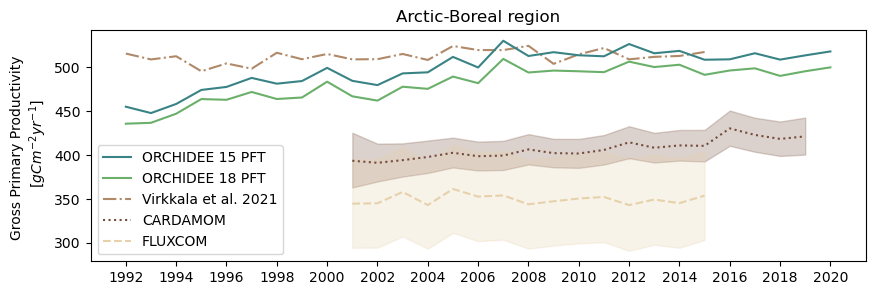

In [40]:
# PLOT TIMESERIES ------------------------------
print(f'REGION: {myregion}')

fig, ax = plt.subplots(1,1,figsize=(10,3)) #(7,3))

plottime = np.arange(len(gpp_ORCHIDEE18_wmean)) + 1992
years = [str(num) for num in plottime]
plottime = years
ax.plot(plottime, gpp_ORCHIDEE15_wmean, label = 'ORCHIDEE 15 PFT', color=cm.navia_r(140), zorder=5)
ax.plot(plottime, gpp_ORCHIDEE18_wmean, label = 'ORCHIDEE 18 PFT', color=cm.navia_r(80), zorder=5)

plottime = np.arange(len(gpp_virkkala_wmean)) + 1992
years = [str(num) for num in plottime]
plottime = years
ax.plot(plottime, gpp_virkkala_wmean , label='Virkkala et al. 2021', color=mymap_brown.reversed()(90), linestyle='dashdot') #(0,(1, 10))) 

plottime = np.arange(len(gpp_cardamom_wmean[:,3])) + 2001
years = [str(num) for num in plottime]
plottime = years
ax.plot(plottime, gpp_cardamom_wmean[:,3], label='CARDAMOM', color=mymap_brown.reversed()(150), linestyle='dotted')  
ax.fill_between(plottime, gpp_cardamom_wmean[:,0], gpp_cardamom_wmean[:,6], alpha=0.25, color=mymap_brown.reversed()(150))


plottime = np.arange(len(gpp_fluxcom_wmean )) + 2001
years = [str(num) for num in plottime]
plottime = years
ax.plot(plottime, gpp_fluxcom_wmean , label='FLUXCOM', color=mymap_brown.reversed()(30), linestyle='dashed') 
ax.fill_between(plottime,
                gpp_fluxcom_wmean  - gpp_fluxcom_mad_wmean,
                gpp_fluxcom_wmean  + gpp_fluxcom_mad_wmean ,
                alpha=0.25, color=mymap_brown.reversed()(30))


ax.legend(loc='lower left') 
if myregion == 'BAWLD':
    ax.set(ylabel=f'Gross Primary Productivity \n [$g C m^{{-2}} yr^{{-1}}$]', title='Arctic-Boreal region')
else:
    ax.set(ylabel=f'Gross Primary Productivity \n [$g C m^{{-2}} yr^{{-1}}$]', title=myregion) 


loc = plticker.MultipleLocator(base=2.0) # this locator puts ticks at regular intervals
ax.xaxis.set_major_locator(loc)

#fig.savefig(f'{savepath}fig7b.pdf', format="pdf", bbox_inches="tight")


5. Select 2010 & mask out region 

In [41]:
# mask out region:

iregion = 0
masklist = [bawld_mask, tundra_mask, boreal_mask]
regions = ['BAWLD', 'Tundra', 'Boreal']
mymask,myregion = masklist[iregion], regions[iregion]

print(np.shape(mymask))

mask_ORC =np.broadcast_to(mymask, gpp_ORCHIDEE15.shape)  
gpp_ORCHIDEE15_masked = np.ma.masked_where(mask_ORC==0, gpp_ORCHIDEE15)
gpp_ORCHIDEE18_masked = np.ma.masked_where(mask_ORC==0, gpp_ORCHIDEE18)

mask_cardamom =np.broadcast_to(mymask, gpp_cardamom.shape)    
gpp_cardamom_masked = np.ma.masked_where(mask_cardamom==0, gpp_cardamom)

mask_fluxcom =np.broadcast_to(mymask, gpp_fluxcom.shape)    
gpp_fluxcom_masked = np.ma.masked_where(mask_fluxcom==0, gpp_fluxcom)
gpp_fluxcom_mad_masked = np.ma.masked_where(mask_fluxcom==0, gpp_fluxcom_mad)

mask_virkkala =np.broadcast_to(mymask, gpp_virkkala.shape)    
gpp_virkkala_masked = np.ma.masked_where(mask_virkkala==0, gpp_virkkala)


mask_cellarea_calc =np.broadcast_to(mymask, cellarea_calc.shape)     
cellarea_calc_masked = np.ma.masked_where(mask_cellarea_calc==0, cellarea_calc)


print(f'Shape CARDAMOM: {np.shape(gpp_cardamom_masked)}')         # = 19 years, 7 quantiles, 20 x 180 grid cells
print(f'Shape FLUXCOM: {np.shape(gpp_fluxcom_masked)}')           # = 15 years, 20 x 180 grid cells
print(f'Shape Virkkala: {np.shape(gpp_virkkala_masked)}')           # = 16 years: 2000-2015
print(f'Shape ORCHIDEE: {np.shape(gpp_ORCHIDEE18_masked)}')       # = 21 years, 20 x 180 grid cells
print(f'Shape cellarea: {np.shape(cellarea_calc_masked)}')


# select data for maps:
gpp_ORCHIDEE15_masked_2010 = gpp_ORCHIDEE15_masked[18,:]
gpp_ORCHIDEE18_masked_2010 = gpp_ORCHIDEE18_masked[18,:]
gpp_cardamom_masked_2010 = gpp_cardamom_masked[9,3,:]      # also select median 
gpp_fluxcom_masked_2010 = gpp_fluxcom_masked[9,:]
gpp_fluxcom_mad_masked_2010 = gpp_fluxcom_mad_masked[9,:]
gpp_virkkala_masked_2010 = gpp_virkkala_masked[18,:]      # for now only 2010 data anyways

(20, 180)
Shape CARDAMOM: (19, 7, 20, 180)
Shape FLUXCOM: (15, 20, 180)
Shape Virkkala: (24, 20, 180)
Shape ORCHIDEE: (29, 20, 180)
Shape cellarea: (20, 180)


6. Plot maps

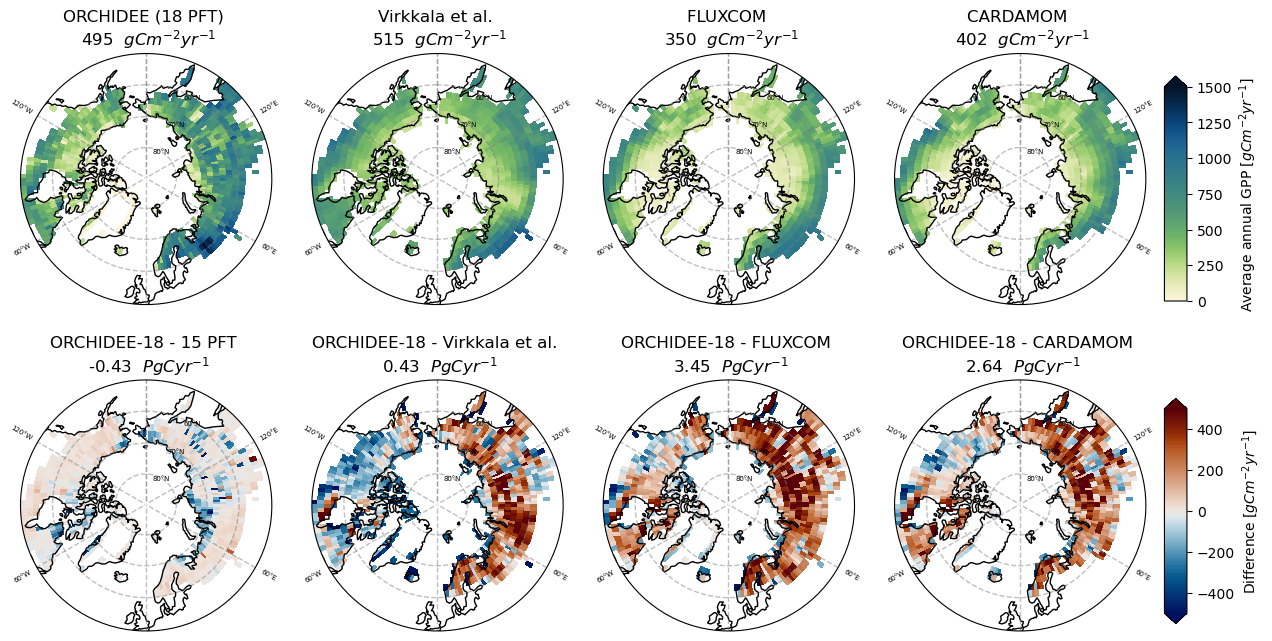

In [42]:
# 4 x 2:
# ------------------------------------------------
# # Select
# ------------------------------------------------
plotdatasets = [gpp_ORCHIDEE18_masked_2010, gpp_virkkala_masked_2010, gpp_fluxcom_masked_2010, gpp_cardamom_masked_2010]
diffplotdatasets = [gpp_ORCHIDEE15_masked_2010, gpp_virkkala_masked_2010, gpp_fluxcom_masked_2010, gpp_cardamom_masked_2010]
plotnames = ['ORCHIDEE (18 PFT)', 'Virkkala et al.', 'FLUXCOM', 'CARDAMOM']
diffbaseline = 'ORCHIDEE-18'
diffplotnames = ['15 PFT', 'Virkkala et al.', 'FLUXCOM', 'CARDAMOM']
plotunits = '$g C m^{{-2}} yr^{{-1}}$'
plotlat, plotlon = latitude, longitude

# ------------------------------------------------
# Plot
# ------------------------------------------------
myprojection = ccrs.NorthPolarStereo()

rows, cols = 2,4
fig, axs = plt.subplots(rows,cols,figsize=(15,7.5),subplot_kw={'projection': myprojection}) 
plt.subplots_adjust(wspace=0.01, hspace=0.3) 

row = 0
i = 0
for col in range(cols):

    ax = axs[row,col]
    ax.set_extent([0, 360, 50, 90], ccrs.PlateCarree()) 
    mycmap = cm.navia_r  
    vmin, vmax = 0,1500
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)                          # continuous colormap

    plotdata = plotdatasets[i]
    plotdata_clean = np.ma.where(plotdata==0, np.nan, plotdata)  # replace 0 with NaN to prevent from showing up in the plot
    im = ax.pcolormesh(plotlon, plotlat, plotdata_clean, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm)

    wmean = calc_wmean(plotdata, area=cellarea_calc, mask=mymask)
    plotname = f'{plotnames[i]} \n {wmean:.0f}  {plotunits}' 
    ax.set(title=plotname)

    specific_latitudes = [50, 60, 70, 80, 90]
    gl = ax.gridlines(crs=ccrs.PlateCarree(), ylocs=specific_latitudes, draw_labels=True, linewidth=1, color='grey', alpha=0.5, linestyle='--')
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 5, 'color': 'black'}
    gl.ylabel_style = {'size': 5, 'color': 'black'}
    gl.top_labels=False
    gl.bottom_labels=False

    ax.coastlines()   

    # make plot edges round:
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    i += 1

cb_ax = fig.add_axes([0.9, 0.55, 0.015, 0.3])      # (left, bottom, width, height)
extendcbar =  "max"
cbar = fig.colorbar(im, cax=cb_ax, extend="max") #, ticks = cbarticks)
cbar.set_label(f'Average annual GPP [{plotunits}]')



# Difference plots
# ------------------------------------------------
row = 1
i = 0
for col in range(cols):

    ax = axs[row,col]
    ax.set_extent([0, 360, 50, 90], ccrs.PlateCarree()) 
    mycmap = cm.vik
    vmin, vmax = -500,500
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)  

    plotdata = plotdatasets[0] - diffplotdatasets[i]
    plotdata_clean = np.ma.where(plotdata==0, np.nan, plotdata)  # replace 0 with NaN to prevent from showing up in the plot
    
    im = ax.pcolormesh(plotlon, plotlat, plotdata_clean, transform=ccrs.PlateCarree(), cmap = mycmap, norm=norm)

    wsum = calc_wmean(plotdata, area=cellarea_calc, mask=mymask, dosum=True) / 1e15
    plotname = f'{diffbaseline} - {diffplotnames[i]} \n {wsum:.2f}  $Pg C yr^{{-1}}$' 
    ax.set(title=plotname)

    specific_latitudes = [50, 60, 70, 80, 90]
    gl = ax.gridlines(crs=ccrs.PlateCarree(), ylocs=specific_latitudes, draw_labels=True, linewidth=1, color='grey', alpha=0.5, linestyle='--')
    gl.xformatter, gl.yformatter = LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 5, 'color': 'black'}
    gl.ylabel_style = {'size': 5, 'color': 'black'}
    gl.top_labels=False
    gl.bottom_labels=False

    ax.coastlines()   

    # make plot edges round:
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    i += 1

cb_ax = fig.add_axes([0.9, 0.12, 0.015, 0.3])       # (left, bottom, width, height)
extendcbar = "both"
cbar = fig.colorbar(im, cax=cb_ax, extend=extendcbar) 
cbar.set_label(f'Difference [{plotunits}]') 


#fig.savefig(f'{savepath}fig7_a.pdf', format="pdf", bbox_inches="tight")


# Figure 8: Tundra region GPP

1. Calculate weighted mean

In [43]:
iregion = 1
masklist = [bawld_mask, tundra_mask, boreal_mask]
regions = ['BAWLD', 'Tundra', 'Boreal']
mymask,myregion = masklist[iregion], regions[iregion]
print(regions[iregion])

gpp_cardamom_wmean_tundra, gpp_cardamom_wstd_tundra = calc_wmean(gpp_cardamom, area=cellarea_calc, mask=mymask, add_std=True)

gpp_fluxcom_wmean_tundra, gpp_fluxcom_wstd_tundra = calc_wmean(gpp_fluxcom, area=cellarea_calc, mask=mymask, add_std=True)
gpp_fluxcom_mad_wmean_tundra = calc_wmean(gpp_fluxcom_mad, area=cellarea_calc, mask=mymask)

gpp_virkkala_wmean_tundra, gpp_virkkala_wstd_tundra = calc_wmean(gpp_virkkala, area=cellarea_calc, mask=mymask, add_std=True)

gpp_ORCHIDEE15_wmean_tundra, gpp_ORCHIDEE15_wstd_tundra = calc_wmean(gpp_ORCHIDEE15, area=cellarea_calc, mask=mymask, add_std=True)
gpp_ORCHIDEE18_wmean_tundra, gpp_ORCHIDEE18_wstd_tundra = calc_wmean(gpp_ORCHIDEE18, area=cellarea_calc, mask=mymask, add_std=True)


print(f'Shape CARDAMOM: {np.shape(gpp_cardamom_wmean_tundra)}')         # = 19 years, 7 quantiles: 2001 - 2019
print(f'Shape FLUXCOM: {np.shape(gpp_fluxcom_wmean_tundra)}')           # = 15 years: 2001-2015
print(f'Shape ORCHIDEE: {np.shape(gpp_ORCHIDEE18_wmean_tundra)}\n')       # = 21 years: 2000-2020

# test for 2010:
testyear = 2010
print(f'CARDAMOM weighted mean 2010: {gpp_cardamom_wmean_tundra[9,3]:.1f}')
print(f'FLUXCOM weighted mean 2010: {gpp_fluxcom_wmean_tundra[9]:.1f}')
print(f'Virkkala weighted mean 2010: {gpp_virkkala_wmean_tundra[18]:.1f}')
print(f'ORCHIDEE-15 weighted mean 2010: {gpp_ORCHIDEE15_wmean_tundra[18]:.1f}')
print(f'ORCHIDEE-18 weighted mean 2010: {gpp_ORCHIDEE18_wmean_tundra[18]:.1f}')
percred = (gpp_ORCHIDEE15_wmean_tundra[18] - gpp_ORCHIDEE18_wmean_tundra[18]) / gpp_ORCHIDEE15_wmean_tundra[18]
print(f'ORCHIDEE improvement: {percred*100:.2f}%')


print(f'\n{regions[iregion]} all years')
print(f'ORCHIDEE-15 weighted mean ({len(gpp_ORCHIDEE15_wmean_tundra)} years): {np.mean(gpp_ORCHIDEE15_wmean_tundra):.1f} ± {np.mean(gpp_ORCHIDEE15_wstd_tundra):.1f}')
print(f'ORCHIDEE-18 weighted mean ({len(gpp_ORCHIDEE18_wmean_tundra)} years): {np.mean(gpp_ORCHIDEE18_wmean_tundra):.1f} ± {np.mean(gpp_ORCHIDEE18_wstd_tundra):.1f}')
percred = (np.mean(gpp_ORCHIDEE15_wmean_tundra) - np.mean(gpp_ORCHIDEE18_wmean_tundra)) / np.mean(gpp_ORCHIDEE15_wmean_tundra)
print(f'ORCHIDEE improvement: {percred*100:.2f}%')

print(f'CARDAMOM weighted mean ({len(gpp_cardamom_wmean_tundra[:,3])} years): {np.mean(gpp_cardamom_wmean_tundra[:,3]):.1f} ± {np.mean(gpp_cardamom_wstd_tundra):.1f}')
print(f'CARDAMOM weighted mean (IQR) ({len(gpp_cardamom_wmean_tundra[:,3])} years): {np.mean(gpp_cardamom_wmean_tundra[:,3]):.1f} ({np.mean(gpp_cardamom_wmean_tundra[:,0]):.1f} - {np.mean(gpp_cardamom_wmean_tundra[:,6]):.1f})')

print(f'FLUXCOM weighted mean ({len(gpp_fluxcom_wmean_tundra)} years): {np.mean(gpp_fluxcom_wmean_tundra):.1f} ± {np.mean(gpp_fluxcom_wstd_tundra):.1f}')
print(f'FLUXCOM weighted mean ± MAD ({len(gpp_fluxcom_wmean_tundra)} years): {np.mean(gpp_fluxcom_wmean_tundra):.1f} ± {np.mean(gpp_fluxcom_mad_wmean_tundra):.1f}')

#print(f'Virkkala weighted mean (1 year): {np.mean(gpp_virkkala_wmean):.1f} ± {np.mean(gpp_virkkala_wstd):.1f}')
print(f'Virkkala weighted mean ({len(gpp_virkkala_wmean_tundra)} years): {np.mean(gpp_virkkala_wmean_tundra):.1f} ± {np.mean(gpp_virkkala_wstd_tundra):.1f}')



plottime = np.arange(len(gpp_ORCHIDEE18_wmean_tundra)) + 1992
years = [str(num) for num in plottime]
istart, iend = 9, 23
print(f'\nORCHIDEE-18 weighted mean {years[istart]}-{years[iend]} ({len(gpp_ORCHIDEE18_wmean_tundra[istart:iend+1])} years): {np.mean(gpp_ORCHIDEE18_wmean_tundra[istart:iend+1]):.1f} ± {np.mean(gpp_ORCHIDEE18_wstd_tundra[istart:iend+1]):.1f}')
istart, iend = 9, 27
print(f'ORCHIDEE-18 weighted mean {years[istart]}-{years[iend]} ({len(gpp_ORCHIDEE18_wmean_tundra[istart:iend+1])} years): {np.mean(gpp_ORCHIDEE18_wmean_tundra[istart:iend+1]):.1f} ± {np.mean(gpp_ORCHIDEE18_wstd_tundra[istart:iend+1]):.1f}')
istart, iend = 0, 23
print(f'ORCHIDEE-15 weighted mean {years[istart]}-{years[iend]} ({len(gpp_ORCHIDEE15_wmean_tundra[istart:iend+1])} years): {np.mean(gpp_ORCHIDEE15_wmean_tundra[istart:iend+1]):.1f} ± {np.mean(gpp_ORCHIDEE15_wstd_tundra[istart:iend+1]):.1f}')
print(f'ORCHIDEE-18 weighted mean {years[istart]}-{years[iend]} ({len(gpp_ORCHIDEE18_wmean_tundra[istart:iend+1])} years): {np.mean(gpp_ORCHIDEE18_wmean_tundra[istart:iend+1]):.1f} ± {np.mean(gpp_ORCHIDEE18_wstd_tundra[istart:iend+1]):.1f}')




Tundra
Shape CARDAMOM: (19, 7)
Shape FLUXCOM: (15,)
Shape ORCHIDEE: (29,)

CARDAMOM weighted mean 2010: 211.2
FLUXCOM weighted mean 2010: 172.8
Virkkala weighted mean 2010: 360.0
ORCHIDEE-15 weighted mean 2010: 335.5
ORCHIDEE-18 weighted mean 2010: 291.3
ORCHIDEE improvement: 13.20%

Tundra all years
ORCHIDEE-15 weighted mean (29 years): 333.8 ± 296.6
ORCHIDEE-18 weighted mean (29 years): 289.3 ± 268.4
ORCHIDEE improvement: 13.34%
CARDAMOM weighted mean (19 years): 215.3 ± 140.5
CARDAMOM weighted mean (IQR) (19 years): 215.3 (200.8 - 230.7)
FLUXCOM weighted mean (15 years): 170.9 ± 119.3
FLUXCOM weighted mean ± MAD (15 years): 170.9 ± 45.0
Virkkala weighted mean (24 years): 364.3 ± 103.5

ORCHIDEE-18 weighted mean 2001-2015 (15 years): 292.7 ± 271.0
ORCHIDEE-18 weighted mean 2001-2019 (19 years): 293.5 ± 272.4
ORCHIDEE-15 weighted mean 1992-2015 (24 years): 332.1 ± 295.0
ORCHIDEE-18 weighted mean 1992-2015 (24 years): 287.6 ± 266.1


2. Plot time series

REGION: Tundra


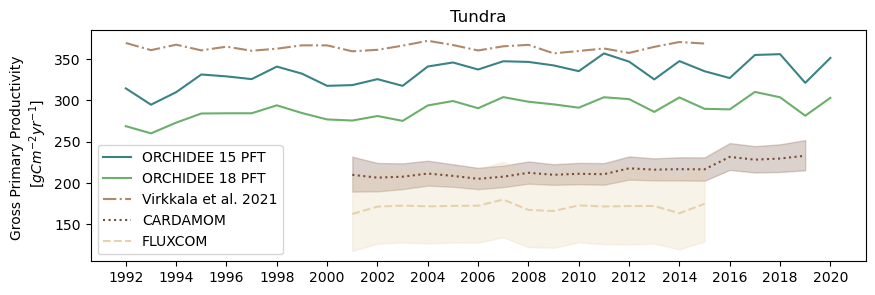

In [44]:
# PLOT TIMESERIES ------------------------------
print(f'REGION: {myregion}')

fig, ax = plt.subplots(1,1,figsize=(10,3)) #(7,3))

plottime = np.arange(len(gpp_ORCHIDEE18_wmean_tundra)) + 1992
years = [str(num) for num in plottime]
plottime = years
ax.plot(plottime, gpp_ORCHIDEE15_wmean_tundra, label = 'ORCHIDEE 15 PFT', color=cm.navia_r(140), zorder=5)
ax.plot(plottime, gpp_ORCHIDEE18_wmean_tundra, label = 'ORCHIDEE 18 PFT', color=cm.navia_r(80), zorder=5)

plottime = np.arange(len(gpp_virkkala_wmean_tundra)) + 1992
years = [str(num) for num in plottime]
plottime = years
ax.plot(plottime, gpp_virkkala_wmean_tundra , label='Virkkala et al. 2021', color=mymap_brown.reversed()(90), linestyle='dashdot') 

plottime = np.arange(len(gpp_cardamom_wmean_tundra[:,3])) + 2001
years = [str(num) for num in plottime]
plottime = years
ax.plot(plottime, gpp_cardamom_wmean_tundra[:,3], label='CARDAMOM', color=mymap_brown.reversed()(150), linestyle='dotted')  
ax.fill_between(plottime, gpp_cardamom_wmean_tundra[:,0], gpp_cardamom_wmean_tundra[:,6], alpha=0.25, color=mymap_brown.reversed()(150))


plottime = np.arange(len(gpp_fluxcom_wmean_tundra )) + 2001
years = [str(num) for num in plottime]
plottime = years
ax.plot(plottime, gpp_fluxcom_wmean_tundra , label='FLUXCOM', color=mymap_brown.reversed()(30), linestyle='dashed') 
ax.fill_between(plottime,
                gpp_fluxcom_wmean_tundra  - gpp_fluxcom_mad_wmean_tundra ,
                gpp_fluxcom_wmean_tundra  + gpp_fluxcom_mad_wmean_tundra ,
                alpha=0.25, color=mymap_brown.reversed()(30))



ax.legend(loc='lower left') #,fontsize=7)
ax.set(ylabel=f'Gross Primary Productivity \n [$g C m^{{-2}} yr^{{-1}}$]', title=myregion)


loc = plticker.MultipleLocator(base=2.0) # this locator puts ticks at regular intervals
ax.xaxis.set_major_locator(loc)

#fig.savefig(f'{savepath}fig8.pdf', format="pdf", bbox_inches="tight")


# Table 7: GPP

For Arctic-Boreal and Tundra region statistics see above (Fig. 7 & 8)

Boreal region

In [45]:

iregion = 2
masklist = [bawld_mask, tundra_mask, boreal_mask]
regions = ['BAWLD', 'Tundra', 'Boreal']
mymask,myregion = masklist[iregion], regions[iregion]
print(regions[iregion])

gpp_cardamom_wmean_boreal, gpp_cardamom_wstd_boreal = calc_wmean(gpp_cardamom, area=cellarea_calc, mask=mymask, add_std=True)

gpp_fluxcom_wmean_boreal, gpp_fluxcom_wstd_boreal = calc_wmean(gpp_fluxcom, area=cellarea_calc, mask=mymask, add_std=True)
gpp_fluxcom_mad_wmean_boreal = calc_wmean(gpp_fluxcom_mad, area=cellarea_calc, mask=mymask)

gpp_virkkala_wmean_boreal, gpp_virkkala_wstd_boreal = calc_wmean(gpp_virkkala, area=cellarea_calc, mask=mymask, add_std=True)

gpp_ORCHIDEE15_wmean_boreal, gpp_ORCHIDEE15_wstd_boreal = calc_wmean(gpp_ORCHIDEE15, area=cellarea_calc, mask=mymask, add_std=True)
gpp_ORCHIDEE18_wmean_boreal, gpp_ORCHIDEE18_wstd_boreal = calc_wmean(gpp_ORCHIDEE18, area=cellarea_calc, mask=mymask, add_std=True)


print(f'Shape CARDAMOM: {np.shape(gpp_cardamom_wmean_boreal)}')         # = 19 years, 7 quantiles: 2001 - 2019
print(f'Shape FLUXCOM: {np.shape(gpp_fluxcom_wmean_boreal)}')           # = 15 years: 2001-2015
print(f'Shape ORCHIDEE: {np.shape(gpp_ORCHIDEE18_wmean_boreal)}\n')       # = 21 years: 2000-2020

# test for 2010:
testyear = 2010
print(f'CARDAMOM weighted mean 2010: {gpp_cardamom_wmean_boreal[9,3]:.1f}')
print(f'FLUXCOM weighted mean 2010: {gpp_fluxcom_wmean_boreal[9]:.1f}')
print(f'Virkkala weighted mean 2010: {gpp_virkkala_wmean_boreal[18]:.1f}')
print(f'ORCHIDEE-15 weighted mean 2010: {gpp_ORCHIDEE15_wmean_boreal[18]:.1f}')
print(f'ORCHIDEE-18 weighted mean 2010: {gpp_ORCHIDEE18_wmean_boreal[18]:.1f}')
percred = (gpp_ORCHIDEE15_wmean_boreal[18] - gpp_ORCHIDEE18_wmean_boreal[18]) / gpp_ORCHIDEE15_wmean_boreal[18]
print(f'ORCHIDEE improvement: {percred*100:.2f}%')


print(f'\n{regions[iregion]} all years')
print(f'ORCHIDEE-15 weighted mean ({len(gpp_ORCHIDEE15_wmean_boreal)} years): {np.mean(gpp_ORCHIDEE15_wmean_boreal):.1f} ± {np.mean(gpp_ORCHIDEE15_wstd_boreal):.1f}')
print(f'ORCHIDEE-18 weighted mean ({len(gpp_ORCHIDEE18_wmean_boreal)} years): {np.mean(gpp_ORCHIDEE18_wmean_boreal):.1f} ± {np.mean(gpp_ORCHIDEE18_wstd_boreal):.1f}')
print(f'CARDAMOM weighted mean ({len(gpp_cardamom_wmean_boreal[:,3])} years): {np.mean(gpp_cardamom_wmean_boreal[:,3]):.1f} ± {np.mean(gpp_cardamom_wstd_boreal):.1f}')
print(f'FLUXCOM weighted mean ({len(gpp_fluxcom_wmean_boreal)} years): {np.mean(gpp_fluxcom_wmean_boreal):.1f} ± {np.mean(gpp_fluxcom_wstd_boreal):.1f}')
#print(f'Virkkala weighted mean (1 year): {np.mean(gpp_virkkala_wmean):.1f} ± {np.mean(gpp_virkkala_wstd):.1f}')
print(f'Virkkala weighted mean ({len(gpp_virkkala_wmean_boreal)} years): {np.mean(gpp_virkkala_wmean_boreal):.1f} ± {np.mean(gpp_virkkala_wstd_boreal):.1f}')
percred = (np.mean(gpp_ORCHIDEE15_wmean_boreal) - np.mean(gpp_ORCHIDEE18_wmean_boreal)) / np.mean(gpp_ORCHIDEE15_wmean_boreal)
print(f'ORCHIDEE improvement: {percred*100:.2f}%')


Boreal
Shape CARDAMOM: (19, 7)
Shape FLUXCOM: (15,)
Shape ORCHIDEE: (29,)

CARDAMOM weighted mean 2010: 500.3
FLUXCOM weighted mean 2010: 481.3
Virkkala weighted mean 2010: 596.8
ORCHIDEE-15 weighted mean 2010: 658.7
ORCHIDEE-18 weighted mean 2010: 653.4
ORCHIDEE improvement: 0.80%

Boreal all years
ORCHIDEE-15 weighted mean (29 years): 635.0 ± 269.4
ORCHIDEE-18 weighted mean (29 years): 631.6 ± 269.0
CARDAMOM weighted mean (19 years): 505.7 ± 194.8
FLUXCOM weighted mean (15 years): 481.0 ± 213.9
Virkkala weighted mean (24 years): 591.4 ± 198.4
ORCHIDEE improvement: 0.52%


Seasonal GPP


In [47]:
def extract_seasons(plotdata, plottimearr, mask=1):
    # input: daily data

    # Step 1: convert datetime64 array to pandas DatetimeIndex for convenience
    time_index = pd.DatetimeIndex(plottimearr)

    # Step 2: define season for each day
    def get_season(month):
        if month in [12, 1, 2]:
            return 0  # DJF
        elif month in [3, 4, 5]:
            return 1  # MAM
        elif month in [6, 7, 8]:
            return 2  # JJA
        else:
            return 3  # SON

    seasons = np.array([get_season(m) for m in time_index.month])

    # Step 3: get days in month for each day
    days_in_month = time_index.days_in_month.values  # array of length 7665

    # Step 4: scale daily GPP to gC/m2/month
    # broadcasting: (7665, 1, 1) * (7665, 20, 180) -> (7665, 20, 180)
    plotdata_monthly = plotdata * days_in_month[:, None, None]

    # Step 5: compute seasonal mean across all years
    seasonal_means = np.zeros((4, plotdata.shape[1], plotdata.shape[2]))  # 4 seasons

    for season_idx in range(4):
        season_mask = seasons == season_idx
        seasonal_means[season_idx] = plotdata_monthly[season_mask].mean(axis=0)

    # Step 6: optional, name the seasons
    season_names = ['DJF', 'MAM', 'JJA', 'SON']

    # calculate area-weighted mean for each season
    for i in [1,2,3,0]:  # loop over seasons
        wmean, wstd = calc_wmean2(seasonal_means[i], area=cellarea_calc, mask=mask, add_std=True)
        print(f'{season_names[i]}: {wmean:.2f} ({wstd:.2f}) gC/m2/month')           # ± {std_w:.2f}

    return seasonal_means


    
def calc_wmean2(data, area, mask = 1, contfrac = 1, dosum = False, add_std=False):
    '''Function from Vlad'''
    if hasattr(area, "mask"): 
        area = np.where(area.mask == False, area, 0)
    
    if hasattr(data, "mask"): 
        loc_area = np.where(data.mask == False, area * contfrac * mask, 0)
    else: 
        #print(np.shape(area), np.shape(contfrac), np.shape(mask))
        loc_area = area * contfrac * mask
    if dosum == False: 
        out = (data * loc_area).sum(axis=-1).sum(axis=-1) / loc_area.sum(axis=-1).sum(axis=-1)
    else: 
        out = (data * loc_area).sum(axis=-1).sum(axis=-1)
    if add_std and not dosum:
        mean_w = (data * loc_area).sum(axis=-1).sum(axis=-1) / loc_area.sum(axis=-1).sum(axis=-1)
        mean_w = mean_w[..., None, None]
        var_w  = (loc_area * (data - mean_w)**2).sum(axis=-1).sum(axis=-1) / loc_area.sum(axis=-1).sum(axis=-1)       # doesn't work, incompatible shapes
        std_w  = np.sqrt(var_w)
        return out, std_w

    return out


In [ ]:
masklist = [bawld_mask, tundra_mask, boreal_mask]
regions = ['BAWLD', 'Tundra', 'Boreal']

gpp_ORCHIDEE15_daily, npft_bl, units = load_ORC_GPP(dataset_d_bl, timearr_daily, annsum=False) 
gpp_ORCHIDEE18_daily, npft_bl, units = load_ORC_GPP(dataset_daily, timearr_daily, annsum=False) 
gpp_fluxcom_monthly, gpp_fluxcom_mad_daily = load_fluxcom_data(annsum=False)
timearr_fluxcom = timearr[indices_for_years(timearr, 2001, 2015)]

In [49]:
#iregion = 0
for iregion in [0,1,2]:
    mymask,myregion = masklist[iregion], regions[iregion]
    print('')
    print(regions[iregion])
    print('ORCHIDEE-15')
    seasonal_means_ORC15 = extract_seasons(gpp_ORCHIDEE15_daily, timearr_daily, mask=mymask)
    print('ORCHIDEE-18')
    seasonal_means_ORC18 = extract_seasons(gpp_ORCHIDEE18_daily, timearr_daily, mask=mymask)
    print('FLUXCOM')
    seasonal_means_fluxcom = extract_seasons(gpp_fluxcom_monthly, timearr_fluxcom , mask=mymask)


BAWLD
ORCHIDEE-15
MAM: 25.80 (31.60) gC/m2/month
JJA: 130.26 (83.57) gC/m2/month
SON: 9.37 (11.70) gC/m2/month
DJF: 0.21 (0.80) gC/m2/month
ORCHIDEE-18
MAM: 24.83 (30.68) gC/m2/month
JJA: 124.21 (81.46) gC/m2/month
SON: 10.67 (11.64) gC/m2/month
DJF: 0.28 (0.74) gC/m2/month
FLUXCOM
MAM: 13.58 (14.10) gC/m2/month
JJA: 91.34 (60.39) gC/m2/month
SON: 10.72 (10.04) gC/m2/month
DJF: 0.90 (0.85) gC/m2/month

Tundra
ORCHIDEE-15
MAM: 5.80 (16.67) gC/m2/month
JJA: 99.90 (85.34) gC/m2/month
SON: 5.44 (8.98) gC/m2/month
DJF: 0.07 (0.24) gC/m2/month
ORCHIDEE-18
MAM: 5.16 (14.36) gC/m2/month
JJA: 84.81 (76.75) gC/m2/month
SON: 6.28 (8.10) gC/m2/month
DJF: 0.10 (0.27) gC/m2/month
FLUXCOM
MAM: 4.71 (5.42) gC/m2/month
JJA: 46.40 (31.26) gC/m2/month
SON: 4.49 (4.11) gC/m2/month
DJF: 1.36 (0.77) gC/m2/month

Boreal
ORCHIDEE-15
MAM: 39.02 (31.89) gC/m2/month
JJA: 159.20 (66.40) gC/m2/month
SON: 12.42 (12.17) gC/m2/month
DJF: 0.29 (0.99) gC/m2/month
ORCHIDEE-18
MAM: 37.77 (31.34) gC/m2/month
JJA: 157.56 

# Table 8: NEE

In [57]:
def load_ORC_NEE(plotdataset, timearr, mask=1, myvar='ESTIMATED_NEE' , annsum = True):
    var = plotdataset.variables[myvar]
    NEE = np.ma.masked_equal(var[:], var._FillValue)   # mask out values with FillValue
    mymask = np.broadcast_to(mask, NEE.shape)
    NEE_masked  = np.ma.masked_where(mymask==0, NEE)                  # mask region
    NEE_PFT_all = NEE_masked

    if annsum:                                         # calculate annual sum
            data = NEE_PFT_all
            ntime, nlat, nlon = data.shape
            data_2d = data.reshape(ntime, -1)
            df = pd.DataFrame(data_2d, index=timearr)
            annual_sum = df.groupby(df.index.year).sum()
            years = annual_sum.index.to_numpy()
            annual_sum_array = annual_sum.to_numpy().reshape(len(years), nlat, nlon)
            total_NEE_year = annual_sum_array 

            ORC_NEE = total_NEE_year
    else:
        ORC_NEE = NEE_PFT_all

    npft = np.shape(NEE_masked)[1]
    
    if annsum:
        units = 'gC/m^2/yr'
    else:
        units = 'gC/m^2/d'

    return ORC_NEE, npft, units


def calc_wmean(data, area, mask = 1, contfrac = 1, dosum = False, add_std=False):
    '''Function from Vlad'''
    if hasattr(area, "mask"): 
        area = np.where(area.mask == False, area, 0)
        #print('unmasked area')
    
    if hasattr(data, "mask"): 
        loc_area = np.where(data.mask == False, area * contfrac * mask, 0)
    else: 
        loc_area = area * contfrac * mask
    if dosum == False: 
        out = (data * loc_area).sum(axis=-1).sum(axis=-1) / loc_area.sum(axis=-1).sum(axis=-1)
    else: 
        out = (data * loc_area).sum(axis=-1).sum(axis=-1)
    if add_std and not dosum:
        mean_w = (data * loc_area).sum(axis=-1).sum(axis=-1) / loc_area.sum(axis=-1).sum(axis=-1)
        mean_w = mean_w[..., None, None]
        var_w  = (loc_area * (data - mean_w)**2).sum(axis=-1).sum(axis=-1) / loc_area.sum(axis=-1).sum(axis=-1)       # doesn't work, incompatible shapes
        std_w  = np.sqrt(var_w)
        return out, std_w

    return out

In [58]:
nee_ORCHIDEE15, npft_bl, units = load_ORC_NEE(dataset_d_bl, timearr_daily, mask=1)    # with daily data
nee_ORCHIDEE18, npft_18, units = load_ORC_NEE(dataset_daily, timearr_daily, mask=1)

In [62]:

iregion = 0
masklist = [bawld_mask, tundra_mask, boreal_mask]
regions = ['BAWLD', 'Tundra', 'Boreal']

for iregion in range(3):
    mymask,myregion = masklist[iregion], regions[iregion]
    nee_ORCHIDEE15_wmean, nee_ORCHIDEE15_wstd = calc_wmean(nee_ORCHIDEE15, area=cellarea_calc, mask=mymask, add_std=True)
    nee_ORCHIDEE18_wmean, nee_ORCHIDEE18_wstd = calc_wmean(nee_ORCHIDEE18, area=cellarea_calc, mask=mymask, add_std=True)
    #print(f'Shape ORCHIDEE: {np.shape(nee_ORCHIDEE18_wmean)}\n')       # = 21 years: 2000-2020

    print(f'\n{regions[iregion]} all years')
    print(f'ORCHIDEE-15 weighted mean ({len(nee_ORCHIDEE15_wmean)} years): {np.mean(nee_ORCHIDEE15_wmean):.1f} ± {np.mean(nee_ORCHIDEE15_wstd):.1f}')
    print(f'ORCHIDEE-18 weighted mean ({len(nee_ORCHIDEE18_wmean)} years): {np.mean(nee_ORCHIDEE18_wmean):.1f} ± {np.mean(nee_ORCHIDEE18_wstd):.1f}')
    percred = (nee_ORCHIDEE15_wmean - nee_ORCHIDEE18_wmean) / nee_ORCHIDEE15_wmean
    print(f'ORCHIDEE improvement: {np.mean(percred)*100:.2f}%')
    percred = (np.mean(nee_ORCHIDEE15_wmean) - np.mean(nee_ORCHIDEE18_wmean)) / np.mean(nee_ORCHIDEE15_wmean)
    print(f'ORCHIDEE improvement: {percred*100:.2f}%')


# Calculate sum:
nee_ORCHIDEE15_wmean  = calc_wmean(nee_ORCHIDEE15, area=cellarea_calc, mask=mymask, add_std=False, dosum=True) / 1e12
nee_ORCHIDEE18_wmean = calc_wmean(nee_ORCHIDEE18, area=cellarea_calc, mask=mymask, add_std=False, dosum=True) / 1e12

print(f'\nTotal {regions[0]} all years')
print(f'ORCHIDEE-15 weighted mean ({len(nee_ORCHIDEE15_wmean)} years): {np.mean(nee_ORCHIDEE15_wmean):.1f} ({np.std(nee_ORCHIDEE15_wmean):.1f}) ')
print(f'ORCHIDEE-18 weighted mean ({len(nee_ORCHIDEE18_wmean)} years): {np.mean(nee_ORCHIDEE18_wmean):.1f} ({np.std(nee_ORCHIDEE18_wmean):.1f}) ')
percred = (nee_ORCHIDEE15_wmean - nee_ORCHIDEE18_wmean) / nee_ORCHIDEE15_wmean
print(f'ORCHIDEE improvement: {np.mean(percred)*100:.2f}%')
percred = (np.mean(nee_ORCHIDEE15_wmean) - np.mean(nee_ORCHIDEE18_wmean)) / np.mean(nee_ORCHIDEE15_wmean)
print(f'ORCHIDEE improvement: {percred*100:.2f}%')



BAWLD all years
ORCHIDEE-15 weighted mean (29 years): -38.6 ± 95.9
ORCHIDEE-18 weighted mean (29 years): -34.6 ± 88.7
ORCHIDEE improvement: 10.01%
ORCHIDEE improvement: 10.31%

Tundra all years
ORCHIDEE-15 weighted mean (29 years): -18.9 ± 76.6
ORCHIDEE-18 weighted mean (29 years): -12.3 ± 60.4
ORCHIDEE improvement: 39.69%
ORCHIDEE improvement: 34.88%

Boreal all years
ORCHIDEE-15 weighted mean (29 years): -52.4 ± 105.1
ORCHIDEE-18 weighted mean (29 years): -49.4 ± 100.3
ORCHIDEE improvement: 5.55%
ORCHIDEE improvement: 5.81%

Total BAWLD all years
ORCHIDEE-15 weighted mean (29 years): -775.0 (144.9) 
ORCHIDEE-18 weighted mean (29 years): -729.9 (140.9) 
ORCHIDEE improvement: 5.55%
ORCHIDEE improvement: 5.81%
